# Combined FERM: GDP + Social Connectedness

This notebook tests the **combined model** described in the FERM model note.

The main specification is:

\[
\Sigma_{ii} = \mu_i, \qquad \Sigma_{ij} = \mu_j + \delta_{ij}, \quad i \neq j.
\]

The notebook also tests a signed Euclidean combination:

\[
\Sigma_{ij} = \operatorname{sign}(\mu_j + \delta_{ij})\sqrt{\mu_j^2 + \delta_{ij}^2}, \quad i \neq j.
\]

where:

- \(\mu_j\) is destination-level attractiveness from GDP per capita,
- \(\delta_{ij}\) is corridor-level attractiveness from social connectedness,
- distance is **not** a feature; it remains part of the radiation scanning mechanism.

The goal is to see whether combining destination attractiveness and relational corridor attractiveness improves over GDP-only and SCI-only FERM, and whether the combination works better as a direct additive score or as a Euclidean magnitude with preserved sign.



## 0. Run Controls

Start in `FAST_MODE=True` to check logic. For final results, set `FAST_MODE=False`.



In [175]:
from pathlib import Path
import os

os.environ.setdefault("MPLCONFIGDIR", str(Path(".matplotlib-cache").resolve()))

FAST_MODE = True
SAVE_FIGURES = True
FIG_DIR = Path("outputs/combined_gdp_sci_figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

TARGET_CONTINENT = "Asia"
CALIBRATION_LABEL = "validation_2019_h1"
TEST_LABEL = "test_2019_h2"
RELATIONAL_FEATURE_YEAR = 2019
DISTANCE_COL = "dist"
SCI_COL = "scaled_sci_2021"
GDP_COL = "gdp_per_capita_2018"
GDP_TRANSFORM = "log_zscore"  # choices: "log_zscore", "log_minmax"

NUM_PARTICLES_FAST = 50_000
NUM_PARTICLES_FULL = 5_000_000
NUM_PARTICLES = NUM_PARTICLES_FAST if FAST_MODE else NUM_PARTICLES_FULL

SIGMA_GRID_FAST = [0.5, 1.0, 2.0, 5.0, 8.0]
SIGMA_GRID_FULL = [0.25, 0.5, 1.0, 2.0, 5.0, 8.0, 12.0]
SIGMA_GRID = SIGMA_GRID_FAST if FAST_MODE else SIGMA_GRID_FULL

print(f"FAST_MODE={FAST_MODE}")
print(f"NUM_PARTICLES={NUM_PARTICLES}")
print(f"SIGMA_GRID={SIGMA_GRID}")


FAST_MODE=True
NUM_PARTICLES=50000
SIGMA_GRID=[0.5, 1.0, 2.0, 5.0, 8.0]


## 1. Imports and Metrics



In [176]:
import importlib
from functools import reduce

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import src.ferm.model as ferm_model
importlib.reload(ferm_model)
from src.ferm.model import FERM, RM
from src.ferm.config import Config
from src.ferm.preprocessing import filter_flows_by_continent, split_flows_by_period
from src.ferm.utils import (
    build_master_country_table,
    load_country_geometries_global,
    load_migration_data,
    load_niche_data,
    load_population_data,
    prepare_nodes,
)

plt.rcParams.update({
    "figure.figsize": (9, 5),
    "axes.grid": True,
    "font.size": 11,
})

EPS = 1.0


def savefig(name: str):
    if SAVE_FIGURES:
        path = FIG_DIR / f"{name}.png"
        plt.savefig(path, dpi=220, bbox_inches="tight")
        print(f"saved: {path}")


def log10p(x):
    return np.log10(np.asarray(x, dtype=float) + 1.0)




def predictive_r2_from_logs(obs_log, pred_log):
    obs_log = np.asarray(obs_log, dtype=float)
    pred_log = np.asarray(pred_log, dtype=float)
    mask = np.isfinite(obs_log) & np.isfinite(pred_log)
    obs_log = obs_log[mask]
    pred_log = pred_log[mask]
    if len(obs_log) == 0:
        return np.nan
    ss_res = np.sum((obs_log - pred_log) ** 2)
    ss_tot = np.sum((obs_log - obs_log.mean()) ** 2)
    return 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan


def route_r2_log_gain_vs_rm(route_df: pd.DataFrame, model_name: str) -> tuple[float, float, float]:
    obs_log = log10p(route_df["num_migrants"])
    rm_log = log10p(route_df["pred_rm"])
    model_log = log10p(route_df[f"pred_{model_name}"])
    r2_rm = predictive_r2_from_logs(obs_log, rm_log)
    r2_model = predictive_r2_from_logs(obs_log, model_log)
    return r2_model - r2_rm, r2_model, r2_rm


def prepare_comp(comp: pd.DataFrame) -> pd.DataFrame:
    out = comp.copy()
    if "total_migrants" in out.columns and "num_migrants" not in out.columns:
        out = out.rename(columns={"total_migrants": "num_migrants"})
    if "residual" not in out.columns:
        out["residual"] = out["predicted_migrants"] - out["num_migrants"]
    if "abs_error" not in out.columns:
        out["abs_error"] = out["residual"].abs()
    if "log_ratio" not in out.columns:
        out["log_ratio"] = np.log10((out["predicted_migrants"] + EPS) / (out["num_migrants"] + EPS))
    if "abs_log_ratio" not in out.columns:
        out["abs_log_ratio"] = out["log_ratio"].abs()
    return out


def compare_to_rm(comp_rm: pd.DataFrame, comp_model: pd.DataFrame, model_name: str) -> pd.DataFrame:
    rm = prepare_comp(comp_rm)
    model = prepare_comp(comp_model)
    keep_rm = ["country_from", "country_to", "country_from_name", "country_to_name", "num_migrants", "predicted_migrants", "abs_log_ratio", "abs_error"]
    keep_model = ["country_from", "country_to", "predicted_migrants", "abs_log_ratio", "abs_error", "log_ratio"]
    rm = rm[keep_rm].rename(columns={
        "predicted_migrants": "pred_rm",
        "abs_log_ratio": "abs_log_rm",
        "abs_error": "abs_error_rm",
    })
    model = model[keep_model].rename(columns={
        "predicted_migrants": f"pred_{model_name}",
        "abs_log_ratio": f"abs_log_{model_name}",
        "abs_error": f"abs_error_{model_name}",
        "log_ratio": f"log_ratio_{model_name}",
    })
    out = rm.merge(model, on=["country_from", "country_to"], how="inner")
    out["model"] = model_name
    out["improvement_abs_log"] = out["abs_log_rm"] - out[f"abs_log_{model_name}"]
    out["improvement_abs_error"] = out["abs_error_rm"] - out[f"abs_error_{model_name}"]
    out["log_shift_vs_rm"] = log10p(out[f"pred_{model_name}"]) - log10p(out["pred_rm"])
    return out


def summarize_against_observed(comp: pd.DataFrame, label: str, family: str, sigma=None) -> dict:
    c = prepare_comp(comp)
    obs_log = log10p(c["num_migrants"])
    pred_log = log10p(c["predicted_migrants"])
    return {
        "model": label,
        "family": family,
        "sigma": sigma,
        "pairs": len(c),
        "observed_total": c["num_migrants"].sum(),
        "predicted_total": c["predicted_migrants"].sum(),
        "MAE": c["abs_error"].mean(),
        "RMSE": np.sqrt(np.mean((c["predicted_migrants"] - c["num_migrants"]) ** 2)),
        "Pearson_log": pd.Series(obs_log).corr(pd.Series(pred_log), method="pearson"),
        "Spearman_log": pd.Series(obs_log).corr(pd.Series(pred_log), method="spearman"),
        "R2_log": predictive_r2_from_logs(obs_log, pred_log),
        "Median_abs_log_ratio": c["abs_log_ratio"].median(),
        "Mean_abs_log_ratio": c["abs_log_ratio"].mean(),
        "zero_pred_share": (c["predicted_migrants"] <= 0).mean(),
        "zero_pred_observed_total": c.loc[c["predicted_migrants"] <= 0, "num_migrants"].sum(),
    }


def summarize_vs_rm(route_df: pd.DataFrame, model_name: str) -> dict:
    r2_gain, r2_model, r2_rm = route_r2_log_gain_vs_rm(route_df, model_name)
    return {
        "model": model_name,
        "median_improvement_abs_log": route_df["improvement_abs_log"].median(),
        "mean_improvement_abs_log": route_df["improvement_abs_log"].mean(),
        "share_better_abs_log": (route_df["improvement_abs_log"] > 0).mean(),
        "R2_log_gain_vs_RM": r2_gain,
        "R2_log_model": r2_model,
        "R2_log_RM": r2_rm,
        "p10_improvement_abs_log": route_df["improvement_abs_log"].quantile(0.10),
        "p90_improvement_abs_log": route_df["improvement_abs_log"].quantile(0.90),
    }


## 2. Build Sigma Matrices

The combined specification follows the model note:

\[
\Sigma_{ii} = \mu_i, \qquad \Sigma_{ij} = \mu_j + \delta_{ij}, \quad i 
eq j.
\]

We use:

- \(\mu_j\): GDP per capita transformed by `GDP_TRANSFORM` (declared in the setup cell; default `log_zscore`).
- \(\delta_{ij}\): social connectedness, min-max scaled to `[-1, 1]`.

Three combined variants are included:

1. `combined_additive`: direct \(\mu_j + \delta_{ij}\).
2. `combined_euclidean`: signed Euclidean combination, \(\operatorname{sign}(\mu_j + \delta_{ij})\sqrt{\mu_j^2 + \delta_{ij}^2}\).
3. `combined_additive_rescaled`: off-diagonal combined scores are re-centered/re-scaled after addition, while the diagonal remains \(\mu_i\).

The Euclidean variant checks whether GDP and SCI should behave as two dimensions of attractiveness rather than being linearly exchangeable. The rescaled additive variant is a robustness check for the normalization issue mentioned in the model note.



In [177]:
MODEL_SPECS = {
    "gdp_only": {
        "family": "traditional",
        "label": "Traditional FERM: GDP only",
        "kind": "gdp",
    },
    "sci_only": {
        "family": "relational",
        "label": "Relational FERM: SCI only",
        "kind": "sci",
    },
    "combined_additive": {
        "family": "combined",
        "label": "Combined FERM: GDP + SCI additive",
        "kind": "combined",
        "mode": "additive",
    },
    "combined_euclidean": {
        "family": "combined",
        "label": "Combined FERM: GDP + SCI signed Euclidean",
        "kind": "combined",
        "mode": "euclidean",
    },
    "combined_additive_rescaled": {
        "family": "combined",
        "label": "Combined FERM: GDP + SCI additive, offdiag rescaled",
        "kind": "combined",
        "mode": "additive_rescaled",
    },
}


def minmax_signed(values: pd.Series) -> pd.Series:
    x = pd.to_numeric(values, errors="coerce")
    valid = x.notna()
    out = pd.Series(np.nan, index=x.index, dtype=float)
    if valid.sum() == 0:
        return out
    xmin = x.loc[valid].min()
    xmax = x.loc[valid].max()
    if pd.isna(xmin) or pd.isna(xmax) or xmax == xmin:
        out.loc[valid] = 0.0
    else:
        out.loc[valid] = 2.0 * (x.loc[valid] - xmin) / (xmax - xmin) - 1.0
    return out


def zscore_log(values: pd.Series) -> pd.Series:
    x = np.log1p(pd.to_numeric(values, errors="coerce"))
    center = x.mean(skipna=True)
    scale = x.std(skipna=True, ddof=0)
    out = pd.Series(np.nan, index=x.index, dtype=float)
    valid = x.notna()
    out.loc[valid] = (x.loc[valid] - center) / scale if pd.notna(scale) and scale > 0 else 0.0
    return out


def log_minmax_signed(values: pd.Series) -> pd.Series:
    x = np.log1p(pd.to_numeric(values, errors="coerce"))
    return minmax_signed(x)


def transform_gdp_values(values: pd.Series, transform: str = GDP_TRANSFORM) -> pd.Series:
    if transform == "log_zscore":
        return zscore_log(values)
    if transform == "log_minmax":
        return log_minmax_signed(values)
    raise ValueError(f"Unknown GDP_TRANSFORM={transform!r}. Use 'log_zscore' or 'log_minmax'.")


def zscore_offdiag(Sigma: pd.DataFrame, diagonal_values: pd.Series) -> pd.DataFrame:
    out = Sigma.copy().astype(float)
    mask = ~np.eye(out.shape[0], dtype=bool)
    vals = pd.Series(out.to_numpy()[mask])
    center = vals.mean(skipna=True)
    scale = vals.std(skipna=True, ddof=0)
    arr = out.to_numpy(dtype=float, copy=True)
    arr[mask] = (arr[mask] - center) / scale if pd.notna(scale) and scale > 0 else arr[mask] - center
    out = pd.DataFrame(arr, index=out.index, columns=out.columns)
    for code, value in diagonal_values.items():
        out.loc[code, code] = value
    return out


def build_gdp_mu(nodes: pd.DataFrame, transform: str = GDP_TRANSFORM) -> pd.Series:
    mu = transform_gdp_values(nodes.set_index("iso3")[GDP_COL], transform=transform).fillna(0.0)
    mu.index = mu.index.astype(str).str.strip().str.upper()
    return mu


def build_gdp_sigma(nodes: pd.DataFrame) -> pd.DataFrame:
    mu = build_gdp_mu(nodes)
    codes = mu.index.tolist()
    values = np.tile(mu.to_numpy(dtype=float), (len(mu), 1))
    return pd.DataFrame(values, index=codes, columns=codes)


def build_sci_table(nodes: pd.DataFrame, gravity_pairs: pd.DataFrame) -> pd.DataFrame:
    code_lookup = nodes[["code", "iso3"]].dropna().drop_duplicates().copy()
    code_lookup["iso3"] = code_lookup["iso3"].astype(str).str.strip().str.upper()

    tmp = gravity_pairs[["iso3_o", "iso3_d", SCI_COL]].copy()
    tmp["iso3_o"] = tmp["iso3_o"].astype(str).str.strip().str.upper()
    tmp["iso3_d"] = tmp["iso3_d"].astype(str).str.strip().str.upper()

    mapped = tmp.merge(
        code_lookup.rename(columns={"code": "country_from", "iso3": "origin_iso3"}),
        left_on="iso3_o", right_on="origin_iso3", how="inner",
    )
    mapped = mapped.merge(
        code_lookup.rename(columns={"code": "country_to", "iso3": "destination_iso3"}),
        left_on="iso3_d", right_on="destination_iso3", how="inner",
    )
    mapped = mapped[mapped["origin_iso3"] != mapped["destination_iso3"]].copy()
    mapped["delta_ij"] = minmax_signed(mapped[SCI_COL])
    mapped = mapped.dropna(subset=["delta_ij"]).copy()
    return mapped[["country_from", "country_to", "origin_iso3", "destination_iso3", SCI_COL, "delta_ij"]].drop_duplicates(["origin_iso3", "destination_iso3"])


def build_sci_delta(nodes: pd.DataFrame, gravity_pairs: pd.DataFrame) -> pd.DataFrame:
    codes = nodes["iso3"].astype(str).str.strip().str.upper().tolist()
    delta = pd.DataFrame(0.0, index=codes, columns=codes)
    table = build_sci_table(nodes, gravity_pairs)
    for row in table.itertuples(index=False):
        if row.origin_iso3 in delta.index and row.destination_iso3 in delta.columns:
            delta.loc[row.origin_iso3, row.destination_iso3] = float(row.delta_ij)
    delta_values = delta.to_numpy(dtype=float, copy=True)
    np.fill_diagonal(delta_values, 0.0)
    return pd.DataFrame(delta_values, index=codes, columns=codes)


def signed_euclidean_sum(a: pd.DataFrame, b: pd.DataFrame) -> pd.DataFrame:
    a_arr = a.to_numpy(dtype=float, copy=True)
    b_arr = b.to_numpy(dtype=float, copy=True)
    direction = np.sign(a_arr + b_arr)
    magnitude = np.sqrt(a_arr ** 2 + b_arr ** 2)
    return pd.DataFrame(direction * magnitude, index=a.index, columns=a.columns)


def build_combined_sigma(nodes: pd.DataFrame, gravity_pairs: pd.DataFrame, mode="additive") -> pd.DataFrame:
    mu = build_gdp_mu(nodes)
    gdp_sigma = build_gdp_sigma(nodes)
    sci_delta = build_sci_delta(nodes, gravity_pairs)

    if mode in {"additive", "additive_rescaled"}:
        combined = gdp_sigma + sci_delta
    elif mode == "euclidean":
        combined = signed_euclidean_sum(gdp_sigma, sci_delta)
    else:
        raise ValueError(f"Unknown combined mode: {mode}")

    for code, value in mu.items():
        combined.loc[code, code] = value
    if mode == "additive_rescaled":
        return zscore_offdiag(combined, diagonal_values=mu)
    return combined


def build_sigma_for_model(model_key: str, nodes: pd.DataFrame, gravity_pairs: pd.DataFrame) -> pd.DataFrame:
    spec = MODEL_SPECS[model_key]
    if spec["kind"] == "gdp":
        return build_gdp_sigma(nodes)
    if spec["kind"] == "sci":
        return build_sci_delta(nodes, gravity_pairs)
    if spec["kind"] == "combined":
        return build_combined_sigma(nodes, gravity_pairs, mode=spec["mode"])
    raise ValueError(model_key)


def build_gravity_distance_matrix(nodes, gravity_pairs, distance_col="dist"):
    codes = nodes["iso3"].astype(str).str.strip().str.upper().tolist()
    distance_values = np.full((len(codes), len(codes)), np.inf, dtype=float)
    np.fill_diagonal(distance_values, 0.0)
    D = pd.DataFrame(distance_values, index=codes, columns=codes)
    tmp = gravity_pairs[["iso3_o", "iso3_d", distance_col]].copy()
    tmp["iso3_o"] = tmp["iso3_o"].astype(str).str.strip().str.upper()
    tmp["iso3_d"] = tmp["iso3_d"].astype(str).str.strip().str.upper()
    tmp = tmp.dropna(subset=[distance_col])
    for row in tmp.itertuples(index=False):
        o = getattr(row, "iso3_o")
        d = getattr(row, "iso3_d")
        if o in D.index and d in D.columns:
            D.loc[o, d] = float(getattr(row, distance_col))
    if np.isinf(D.to_numpy()).any():
        missing = int(np.isinf(D.to_numpy()).sum())
        raise ValueError(f"Distance matrix contains {missing} missing/infinite entries.")
    return D



## 3. Load Data

This uses the same calibration/test split as the presentation notebook.



In [178]:
config = Config(
    target_continent=TARGET_CONTINENT,
    niche_type=GDP_COL,
    niche_method=GDP_TRANSFORM,
    num_particles=NUM_PARTICLES,
    sigma=1.0,
    verbose=True,
)

gravity_path = Path("Gravity_csv_V202211/Gravity_V202211_bilateral_nonbinary.csv")
gravity_pairs = pd.read_csv(
    gravity_path,
    usecols=["year", "iso3_o", "iso3_d", DISTANCE_COL, SCI_COL],
)
gravity_pairs = gravity_pairs[gravity_pairs["year"] == RELATIONAL_FEATURE_YEAR].copy()

migrations = load_migration_data(config.flow_path)
populations = load_population_data(config.pop_path)
world_gdf, country_geo = load_country_geometries_global()
niche_df = load_niche_data(config.gdp_path, niche_type=config.niche_type)

master_country = build_master_country_table(
    country_geo,
    populations,
    niche_df=niche_df,
    niche_col=config.niche_type,
)
flows, country = filter_flows_by_continent(
    master_country,
    migrations,
    niche_type=config.niche_type,
    continent=config.target_continent,
)
pair_lookup = split_flows_by_period(flows, master_country)

flows_val = pair_lookup[CALIBRATION_LABEL].rename({"total_migrants": "num_migrants"}, axis=1).copy()
flows_test = pair_lookup[TEST_LABEL].rename({"total_migrants": "num_migrants"}, axis=1).copy()

nodes_val = prepare_nodes(country, flows_val)
nodes_test = prepare_nodes(country, flows_test)
D_val = build_gravity_distance_matrix(nodes_val, gravity_pairs, distance_col=DISTANCE_COL)
D_test = build_gravity_distance_matrix(nodes_test, gravity_pairs, distance_col=DISTANCE_COL)

print("Calibration flows:", len(flows_val), "pairs | nodes:", len(nodes_val))
print("Test flows:", len(flows_test), "pairs | nodes:", len(nodes_test))
print("Models:")
for key, spec in MODEL_SPECS.items():
    print(f"- {key}: {spec['label']}")


Calibration flows: 2064 pairs | nodes: 46
Test flows: 2064 pairs | nodes: 46
Models:
- gdp_only: Traditional FERM: GDP only
- sci_only: Relational FERM: SCI only
- combined_additive: Combined FERM: GDP + SCI additive
- combined_euclidean: Combined FERM: GDP + SCI signed Euclidean
- combined_additive_rescaled: Combined FERM: GDP + SCI additive, offdiag rescaled


## 4. Inspect Sigma Distributions

Before simulation, check the off-diagonal ranges. Combined Sigma can become wider than either GDP-only or SCI-only, so this diagnostic matters.



### SCI Raw vs Min-Max Normalized Distribution

This checks the distribution of the Social Connectedness Index before and after the exact min-max normalization used for the SCI corridor feature.


,variable,min,p01,median,mean,p99,max,std,n
0,raw SCI,60.00000,125.900000,1982.000000,19892.380769,307462.330000,442967.000000,53072.935131,1560
1,log10(raw SCI + 1),1.78533,2.103132,3.297323,3.463142,5.487751,5.646372,0.834596,1560
2,min-max normalized SCI,-1.00000,-0.999702,-0.991321,-0.910444,0.388112,1.000000,0.239657,1560


saved: outputs/combined_gdp_sci_figures/01a_sci_raw_vs_minmax_distribution.png


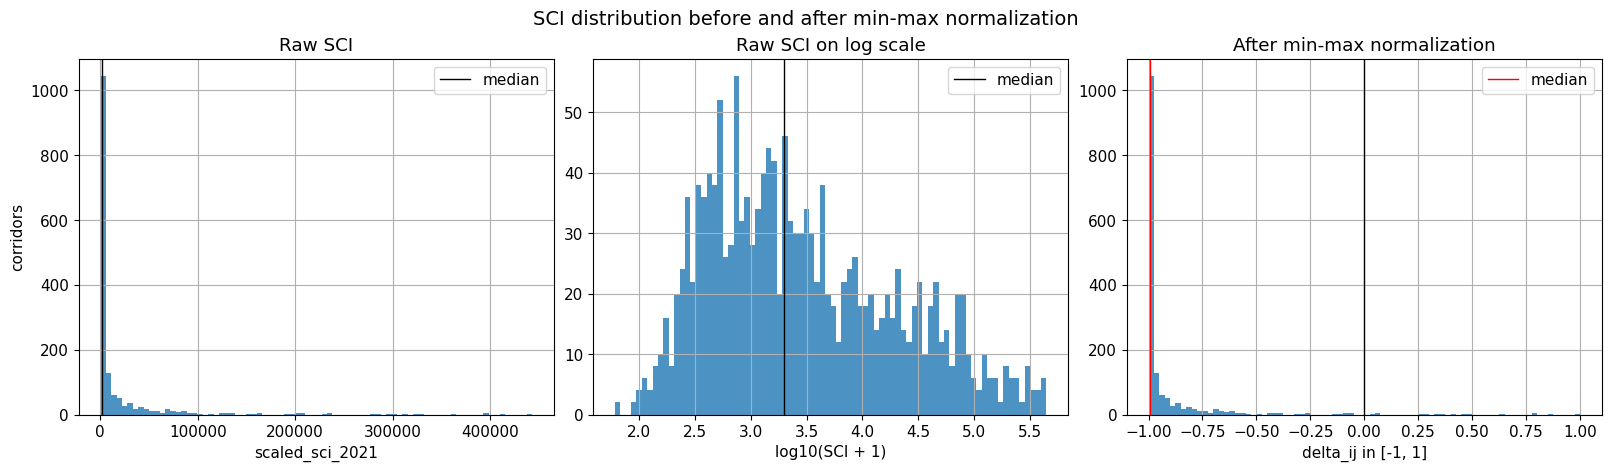

In [191]:
def plot_sci_raw_vs_minmax_distribution(nodes: pd.DataFrame, gravity_pairs: pd.DataFrame):
    sci_table = build_sci_table(nodes, gravity_pairs)
    raw = pd.to_numeric(sci_table[SCI_COL], errors="coerce").dropna()
    normalized = pd.to_numeric(sci_table["delta_ij"], errors="coerce").dropna()
    raw_log = np.log10(raw.clip(lower=0) + 1.0)

    summary = pd.DataFrame({
        "variable": ["raw SCI", "log10(raw SCI + 1)", "min-max normalized SCI"],
        "min": [raw.min(), raw_log.min(), normalized.min()],
        "p01": [raw.quantile(0.01), raw_log.quantile(0.01), normalized.quantile(0.01)],
        "median": [raw.median(), raw_log.median(), normalized.median()],
        "mean": [raw.mean(), raw_log.mean(), normalized.mean()],
        "p99": [raw.quantile(0.99), raw_log.quantile(0.99), normalized.quantile(0.99)],
        "max": [raw.max(), raw_log.max(), normalized.max()],
        "std": [raw.std(ddof=0), raw_log.std(ddof=0), normalized.std(ddof=0)],
        "n": [len(raw), len(raw_log), len(normalized)],
    })
    display(summary)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.6), constrained_layout=True)
    axes[0].hist(raw, bins=80, alpha=0.8)
    axes[0].axvline(raw.median(), color="black", linewidth=1, label="median")
    axes[0].set_title("Raw SCI")
    axes[0].set_xlabel(SCI_COL)
    axes[0].set_ylabel("corridors")
    axes[0].legend()

    axes[1].hist(raw_log, bins=80, alpha=0.8)
    axes[1].axvline(raw_log.median(), color="black", linewidth=1, label="median")
    axes[1].set_title("Raw SCI on log scale")
    axes[1].set_xlabel("log10(SCI + 1)")
    axes[1].legend()

    axes[2].hist(normalized, bins=80, alpha=0.8)
    axes[2].axvline(0, color="black", linewidth=1)
    axes[2].axvline(normalized.median(), color="red", linewidth=1, label="median")
    axes[2].set_title("After min-max normalization")
    axes[2].set_xlabel("delta_ij in [-1, 1]")
    axes[2].legend()

    fig.suptitle("SCI distribution before and after min-max normalization", fontsize=14)
    savefig("01a_sci_raw_vs_minmax_distribution")
    plt.show()
    return sci_table, summary

sci_distribution_table, sci_distribution_summary = plot_sci_raw_vs_minmax_distribution(nodes_val, gravity_pairs)


,model,label,family,diag_median,off_min,off_p01,off_median,off_p99,off_max,share_negative,share_positive,share_zero
0,gdp_only,Traditional FERM: GDP only,traditional,-0.208033,-1.809949,-1.809949,-0.208033,1.810983,1.810983,0.565217,0.413043,0.021739
1,sci_only,Relational FERM: SCI only,relational,0.000000,-1.000000,-0.999639,-0.976686,0.289661,1.000000,0.739130,0.014493,0.246377
2,combined_additive,Combined FERM: GDP + SCI additive,combined,-0.208033,-2.436414,-2.431611,-0.920305,1.696274,2.810983,0.693237,0.303865,0.002899
3,combined_euclidean,Combined FERM: GDP + SCI signed Euclidean,combined,-0.208033,-1.809949,-1.809949,-1.015904,2.050502,2.068734,0.693237,0.303865,0.002899
4,combined_additive_rescaled,"Combined FERM: GDP + SCI additive, offdiag res...",combined,-0.208033,-1.657776,-1.653227,-0.221796,2.256491,3.312286,0.565700,0.434300,0.000000


saved: outputs/combined_gdp_sci_figures/01_sigma_ranges_combined.png


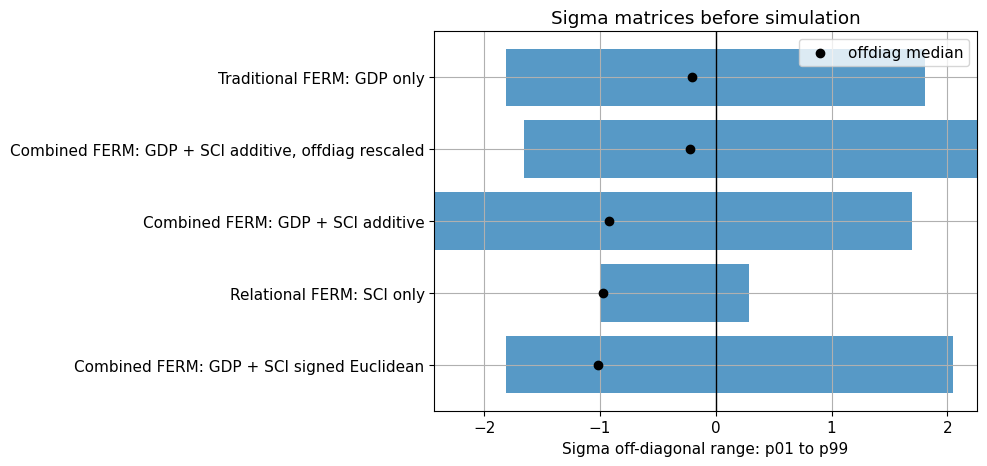

In [179]:
sigma_objects_val = {}
sigma_objects_test = {}
sigma_diag_rows = []

for model_key, spec in MODEL_SPECS.items():
    Sigma_val = build_sigma_for_model(model_key, nodes_val, gravity_pairs)
    Sigma_test = build_sigma_for_model(model_key, nodes_test, gravity_pairs)
    sigma_objects_val[model_key] = Sigma_val
    sigma_objects_test[model_key] = Sigma_test

    off = ~np.eye(Sigma_val.shape[0], dtype=bool)
    vals = Sigma_val.to_numpy()[off]
    diag = np.diag(Sigma_val.to_numpy())
    sigma_diag_rows.append({
        "model": model_key,
        "label": spec["label"],
        "family": spec["family"],
        "diag_median": np.nanmedian(diag),
        "off_min": np.nanmin(vals),
        "off_p01": np.nanquantile(vals, 0.01),
        "off_median": np.nanmedian(vals),
        "off_p99": np.nanquantile(vals, 0.99),
        "off_max": np.nanmax(vals),
        "share_negative": np.mean(vals < 0),
        "share_positive": np.mean(vals > 0),
        "share_zero": np.mean(np.isclose(vals, 0.0)),
    })

sigma_diag = pd.DataFrame(sigma_diag_rows)
display(sigma_diag)

fig, ax = plt.subplots(figsize=(10, 4.8))
plot_df = sigma_diag.sort_values("off_median")
ax.barh(plot_df["label"], plot_df["off_p99"] - plot_df["off_p01"], left=plot_df["off_p01"], alpha=0.75)
ax.scatter(plot_df["off_median"], plot_df["label"], color="black", zorder=3, label="offdiag median")
ax.axvline(0, color="black", linewidth=1)
ax.set_xlim(
    min(sigma_diag["off_p01"].min(), -0.5),
    max(sigma_diag["off_p99"].max(), 0.5),
)
ax.set_xlabel("Sigma off-diagonal range: p01 to p99")
ax.set_title("Sigma matrices before simulation")
ax.legend()
plt.tight_layout()
savefig("01_sigma_ranges_combined")
plt.show()


## 5. Calibration: Tune Sigma

Tune only the model `sigma` on the calibration split (`validation_2019_h1` in the dataset labels).



In [180]:
def run_rm(nodes, flows, D):
    return RM(nodes=nodes, flows=flows, distance_matrix=D).run()


def run_ferm(nodes, flows, D, Sigma, sigma, num_particles=NUM_PARTICLES):
    return FERM(nodes=nodes, flows=flows, features=Sigma, distance_matrix=D).run(
        num_particles=num_particles,
        sigma=float(sigma),
        verbose=False,
    )

rm_val = run_rm(nodes_val, flows_val, D_val)
rm_test = run_rm(nodes_test, flows_test, D_test)

calibration_rows = []
calibration_results = {}

for model_key, spec in MODEL_SPECS.items():
    Sigma_val = sigma_objects_val[model_key]
    for sigma in SIGMA_GRID:
        print(f"calibration | {model_key} | sigma={sigma}")
        result = run_ferm(nodes_val, flows_val, D_val, Sigma_val, sigma=sigma, num_particles=NUM_PARTICLES)
        route_df = compare_to_rm(rm_val.comparison, result.comparison, model_key)
        row = summarize_against_observed(result.comparison, label=model_key, family=spec["family"], sigma=sigma)
        row.update(summarize_vs_rm(route_df, model_key))
        row["label"] = spec["label"]
        calibration_rows.append(row)
        calibration_results[(model_key, sigma)] = {"result": result, "routes": route_df}

calibration_df = pd.DataFrame(calibration_rows)
calibration_df = calibration_df.sort_values(
    ["median_improvement_abs_log", "share_better_abs_log", "R2_log_gain_vs_RM", "Pearson_log"],
    ascending=[False, False, False, False],
).reset_index(drop=True)

display(calibration_df)

best_by_model = (
    calibration_df.sort_values(
        ["model", "median_improvement_abs_log", "share_better_abs_log", "R2_log_gain_vs_RM", "Pearson_log"],
        ascending=[True, False, False, False, False],
    )
    .groupby("model", as_index=False)
    .head(1)
    .reset_index(drop=True)
)

display(best_by_model[["model", "label", "family", "sigma", "median_improvement_abs_log", "share_better_abs_log", "Pearson_log", "R2_log", "R2_log_gain_vs_RM", "zero_pred_share"]])


calibration | gdp_only | sigma=0.5
calibration | gdp_only | sigma=1.0
calibration | gdp_only | sigma=2.0
calibration | gdp_only | sigma=5.0
calibration | gdp_only | sigma=8.0
calibration | sci_only | sigma=0.5
calibration | sci_only | sigma=1.0
calibration | sci_only | sigma=2.0
calibration | sci_only | sigma=5.0
calibration | sci_only | sigma=8.0
calibration | combined_additive | sigma=0.5
calibration | combined_additive | sigma=1.0
calibration | combined_additive | sigma=2.0
calibration | combined_additive | sigma=5.0
calibration | combined_additive | sigma=8.0
calibration | combined_euclidean | sigma=0.5
calibration | combined_euclidean | sigma=1.0
calibration | combined_euclidean | sigma=2.0
calibration | combined_euclidean | sigma=5.0
calibration | combined_euclidean | sigma=8.0
calibration | combined_additive_rescaled | sigma=0.5
calibration | combined_additive_rescaled | sigma=1.0
calibration | combined_additive_rescaled | sigma=2.0
calibration | combined_additive_rescaled | sig

,model,family,sigma,pairs,observed_total,predicted_total,MAE,RMSE,Pearson_log,Spearman_log,...,zero_pred_observed_total,median_improvement_abs_log,mean_improvement_abs_log,share_better_abs_log,R2_log_gain_vs_RM,R2_log_model,R2_log_RM,p10_improvement_abs_log,p90_improvement_abs_log,label
0,combined_additive,combined,5.0,2070,5751056.0,5751056.0,3749.837521,15059.730364,0.723327,0.722544,...,6375.0,0.105829,0.197519,0.613527,0.503405,-0.032760,-0.536165,-0.453819,0.980932,Combined FERM: GDP + SCI additive
1,combined_additive,combined,8.0,2070,5751056.0,5751056.0,3732.509457,15051.749604,0.719373,0.716726,...,6316.0,0.093622,0.171957,0.625604,0.441306,-0.094860,-0.536165,-0.270524,0.741576,Combined FERM: GDP + SCI additive
2,combined_euclidean,combined,8.0,2070,5751056.0,5751056.0,3755.049936,15155.533159,0.710977,0.709476,...,13922.0,0.053122,0.124740,0.581159,0.326057,-0.210109,-0.536165,-0.308158,0.684611,Combined FERM: GDP + SCI signed Euclidean
3,combined_additive_rescaled,combined,8.0,2070,5751056.0,5751056.0,3882.489911,15931.972028,0.711423,0.709588,...,11295.0,0.045470,0.101092,0.570048,0.277135,-0.259030,-0.536165,-0.305263,0.567430,"Combined FERM: GDP + SCI additive, offdiag res..."
4,gdp_only,traditional,8.0,2070,5751056.0,5751056.0,3840.798562,15609.267457,0.706473,0.705425,...,10844.0,0.040270,0.106428,0.569082,0.277522,-0.258644,-0.536165,-0.259796,0.559616,Traditional FERM: GDP only
5,gdp_only,traditional,5.0,2070,5751056.0,5751056.0,3862.507400,15580.445530,0.714154,0.715162,...,10509.0,0.038522,0.113904,0.552174,0.311017,-0.225148,-0.536165,-0.460291,0.761307,Traditional FERM: GDP only
6,combined_additive_rescaled,combined,5.0,2070,5751056.0,5751056.0,3931.852287,16496.030842,0.718940,0.718858,...,10857.0,0.033474,0.104116,0.543478,0.296085,-0.240080,-0.536165,-0.486843,0.745869,"Combined FERM: GDP + SCI additive, offdiag res..."
7,sci_only,relational,5.0,2070,5751056.0,5751056.0,3850.208106,16189.575939,0.674011,0.662478,...,23783.0,0.029867,0.067136,0.571981,0.193515,-0.342650,-0.536165,-0.273333,0.425558,Relational FERM: SCI only
8,combined_euclidean,combined,5.0,2070,5751056.0,5751056.0,3777.104113,15230.736255,0.705909,0.698063,...,20341.0,0.026706,0.108013,0.532367,0.284573,-0.251593,-0.536165,-0.563214,0.858227,Combined FERM: GDP + SCI signed Euclidean
9,sci_only,relational,8.0,2070,5751056.0,5751056.0,3881.024957,16369.943797,0.669010,0.655575,...,26404.0,0.018727,0.041884,0.554106,0.115713,-0.420453,-0.536165,-0.205640,0.299030,Relational FERM: SCI only


,model,label,family,sigma,median_improvement_abs_log,share_better_abs_log,Pearson_log,R2_log,R2_log_gain_vs_RM,zero_pred_share
0,combined_additive,Combined FERM: GDP + SCI additive,combined,5.0,0.105829,0.613527,0.723327,-0.032760,0.503405,0.102899
1,combined_additive_rescaled,"Combined FERM: GDP + SCI additive, offdiag res...",combined,8.0,0.045470,0.570048,0.711423,-0.259030,0.277135,0.148792
2,combined_euclidean,Combined FERM: GDP + SCI signed Euclidean,combined,8.0,0.053122,0.581159,0.710977,-0.210109,0.326057,0.141063
3,gdp_only,Traditional FERM: GDP only,traditional,8.0,0.040270,0.569082,0.706473,-0.258644,0.277522,0.144444
4,sci_only,Relational FERM: SCI only,relational,5.0,0.029867,0.571981,0.674011,-0.342650,0.193515,0.155556


saved: outputs/combined_gdp_sci_figures/02_calibration_sigma_tuning_combined.png


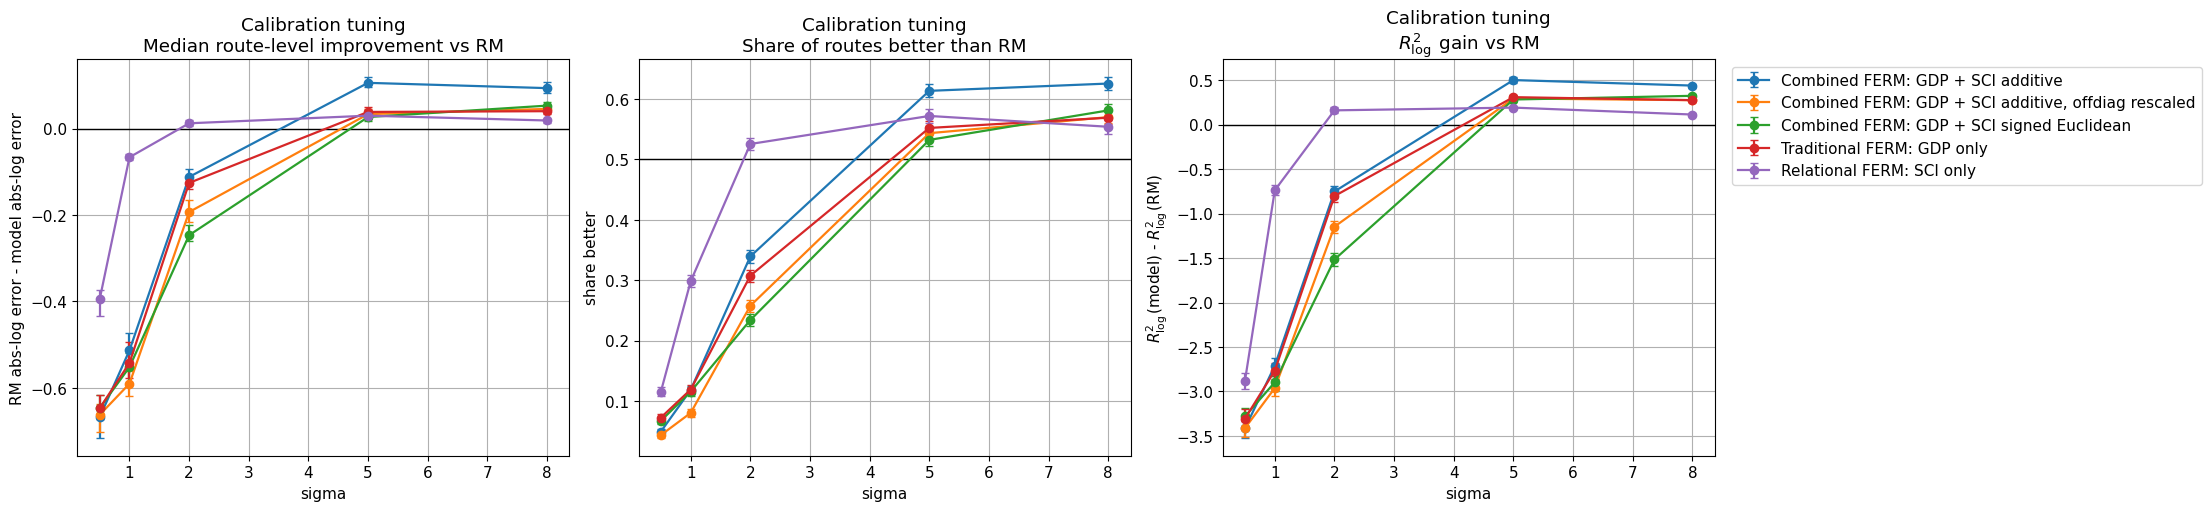

In [181]:
BOOTSTRAP_N = 500
BOOTSTRAP_SEED = 20240609
BOOTSTRAP_INTERVAL = "68% bootstrap interval"


def bootstrap_calibration_intervals(calibration_results, n_boot=BOOTSTRAP_N, seed=BOOTSTRAP_SEED):
    rng = np.random.default_rng(seed)
    rows = []
    for (model_key, sigma), payload in calibration_results.items():
        route_df = payload["routes"].dropna(subset=["improvement_abs_log", "num_migrants", "pred_rm", f"pred_{model_key}"]).copy()
        x = route_df["improvement_abs_log"].to_numpy(dtype=float)
        n = len(route_df)
        if n == 0:
            rows.append({
                "model": model_key,
                "sigma": sigma,
                "median_improvement_ci_low": np.nan,
                "median_improvement_ci_high": np.nan,
                "share_better_ci_low": np.nan,
                "share_better_ci_high": np.nan,
                "R2_log_gain_ci_low": np.nan,
                "R2_log_gain_ci_high": np.nan,
            })
            continue

        med_samples = np.empty(n_boot, dtype=float)
        share_samples = np.empty(n_boot, dtype=float)
        r2_gain_samples = np.empty(n_boot, dtype=float)
        for b in range(n_boot):
            sample = route_df.iloc[rng.integers(0, n, size=n)]
            sample_x = sample["improvement_abs_log"].to_numpy(dtype=float)
            med_samples[b] = np.median(sample_x)
            share_samples[b] = np.mean(sample_x > 0)
            r2_gain_samples[b] = route_r2_log_gain_vs_rm(sample, model_key)[0]

        rows.append({
            "model": model_key,
            "sigma": sigma,
            "median_improvement_ci_low": np.quantile(med_samples, 0.16),
            "median_improvement_ci_high": np.quantile(med_samples, 0.84),
            "share_better_ci_low": np.quantile(share_samples, 0.16),
            "share_better_ci_high": np.quantile(share_samples, 0.84),
            "R2_log_gain_ci_low": np.quantile(r2_gain_samples, 0.16),
            "R2_log_gain_ci_high": np.quantile(r2_gain_samples, 0.84),
        })
    return pd.DataFrame(rows)


calibration_ci_df = bootstrap_calibration_intervals(calibration_results)
ci_cols = [
    "median_improvement_ci_low", "median_improvement_ci_high",
    "share_better_ci_low", "share_better_ci_high",
    "R2_log_gain_ci_low", "R2_log_gain_ci_high",
]
calibration_df = (
    calibration_df.drop(columns=ci_cols, errors="ignore")
    .merge(calibration_ci_df, on=["model", "sigma"], how="left")
)


def plot_calibration_curve(ax, g, y_col, low_col, high_col, label):
    g = g.sort_values("sigma")
    x = g["sigma"].to_numpy(dtype=float)
    y = g[y_col].to_numpy(dtype=float)

    if low_col in g.columns and high_col in g.columns and g[[low_col, high_col]].notna().all().all():
        low = g[low_col].to_numpy(dtype=float)
        high = g[high_col].to_numpy(dtype=float)
        yerr = np.vstack([
            np.maximum(y - low, 0),
            np.maximum(high - y, 0),
        ])
        ax.errorbar(x, y, yerr=yerr, marker="o", capsize=3, linewidth=1.6, label=label)
    else:
        ax.plot(x, y, marker="o", label=label)


fig, axes = plt.subplots(1, 3, figsize=(22, 5), constrained_layout=True)

for model_key, g in calibration_df.groupby("model"):
    label = MODEL_SPECS[model_key]["label"]
    plot_calibration_curve(
        axes[0], g,
        "median_improvement_abs_log", "median_improvement_ci_low", "median_improvement_ci_high",
        label,
    )
    plot_calibration_curve(
        axes[1], g,
        "share_better_abs_log", "share_better_ci_low", "share_better_ci_high",
        label,
    )
    plot_calibration_curve(
        axes[2], g,
        "R2_log_gain_vs_RM", "R2_log_gain_ci_low", "R2_log_gain_ci_high",
        label,
    )

axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Calibration tuning\nMedian route-level improvement vs RM")
axes[0].set_xlabel("sigma")
axes[0].set_ylabel("RM abs-log error - model abs-log error")

axes[1].axhline(0.5, color="black", linewidth=1)
axes[1].set_title("Calibration tuning\nShare of routes better than RM")
axes[1].set_xlabel("sigma")
axes[1].set_ylabel("share better")

axes[2].axhline(0, color="black", linewidth=1)
axes[2].set_title("Calibration tuning\n$R^2_{\log}$ gain vs RM")
axes[2].set_xlabel("sigma")
axes[2].set_ylabel("$R^2_{\log}$(model) - $R^2_{\log}$(RM)")
axes[2].legend(bbox_to_anchor=(1.02, 1), loc="upper left")

savefig("02_calibration_sigma_tuning_combined")
plt.show()


## 6. Test Evaluation

Freeze each model at its calibration-selected `sigma`, then evaluate on `test_2019_h2`.



In [182]:
test_results = {"rm": {"result": rm_test, "label": "RM", "family": "baseline", "sigma": np.nan}}
test_rows = [summarize_against_observed(rm_test.comparison, label="rm", family="baseline", sigma=np.nan)]
route_results = {}

for _, best in best_by_model.iterrows():
    model_key = best["model"]
    sigma = float(best["sigma"])
    spec = MODEL_SPECS[model_key]
    print(f"test | {model_key} | sigma={sigma}")
    result = run_ferm(nodes_test, flows_test, D_test, sigma_objects_test[model_key], sigma=sigma, num_particles=NUM_PARTICLES)
    test_results[model_key] = {"result": result, "label": spec["label"], "family": spec["family"], "sigma": sigma}
    row = summarize_against_observed(result.comparison, label=model_key, family=spec["family"], sigma=sigma)
    route_df = compare_to_rm(rm_test.comparison, result.comparison, model_key)
    row.update(summarize_vs_rm(route_df, model_key))
    row["label"] = spec["label"]
    test_rows.append(row)
    route_results[model_key] = route_df

test_summary = pd.DataFrame(test_rows)
test_summary = test_summary.sort_values(["median_improvement_abs_log", "Pearson_log"], ascending=[False, False])
display(test_summary)


test | combined_additive | sigma=5.0
test | combined_additive_rescaled | sigma=8.0
test | combined_euclidean | sigma=8.0
test | gdp_only | sigma=8.0
test | sci_only | sigma=5.0


,model,family,sigma,pairs,observed_total,predicted_total,MAE,RMSE,Pearson_log,Spearman_log,...,zero_pred_observed_total,median_improvement_abs_log,mean_improvement_abs_log,share_better_abs_log,R2_log_gain_vs_RM,R2_log_model,R2_log_RM,p10_improvement_abs_log,p90_improvement_abs_log,label
1,combined_additive,combined,5.0,2070,6186048.0,6186048.0,4166.681269,17155.755482,0.705374,0.708847,...,8663.0,0.094743,0.194259,0.608213,0.490070,-0.066662,-0.556732,-0.452789,0.943490,Combined FERM: GDP + SCI additive
3,combined_euclidean,combined,8.0,2070,6186048.0,6186048.0,4181.408789,17210.160731,0.694754,0.695428,...,16462.0,0.047873,0.125198,0.575845,0.318316,-0.238416,-0.556732,-0.299103,0.687641,Combined FERM: GDP + SCI signed Euclidean
4,gdp_only,traditional,8.0,2070,6186048.0,6186048.0,4269.061199,17712.094987,0.688347,0.692580,...,12693.0,0.037579,0.102898,0.566184,0.259694,-0.297038,-0.556732,-0.277008,0.557129,Traditional FERM: GDP only
2,combined_additive_rescaled,combined,8.0,2070,6186048.0,6186048.0,4313.960255,17981.045725,0.695098,0.698714,...,10638.0,0.037178,0.100667,0.562802,0.274933,-0.281799,-0.556732,-0.293986,0.579957,"Combined FERM: GDP + SCI additive, offdiag res..."
5,sci_only,relational,5.0,2070,6186048.0,6186048.0,4291.404333,18174.497785,0.655997,0.651568,...,14337.0,0.022338,0.058231,0.555072,0.178530,-0.378202,-0.556732,-0.304671,0.423595,Relational FERM: SCI only
0,rm,baseline,NaN,2070,6186048.0,6186048.0,4384.796104,18917.088907,0.645768,0.655662,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 6a. Add Weighted Linear GDP + SCI Model

This section adds one extra model **without rerunning the existing models**.

For off-diagonal corridors, the combined feature is

\[
\Sigma_{ij}(\alpha)=\alpha\,\mu_j^{GDP} + (1-\alpha)\,\delta_{ij}^{SCI}, \quad i\neq j.
\]

The diagonal remains the GDP node threshold:

\[
\Sigma_{ii}=\mu_i^{GDP}.
\]

The cell below calibrates both `alpha_gdp` and `sigma` on the calibration split, then evaluates the selected pair on the test split.



In [189]:
LINEAR_MODEL_KEY = "combined_linear_weighted"
LINEAR_MODEL_LABEL = "Combined FERM: GDP + SCI weighted linear"

# alpha_gdp = 1 means off-diagonal offers are GDP-only.
# alpha_gdp = 0 means off-diagonal offers are SCI-only, while the diagonal threshold remains GDP.
LINEAR_ALPHA_GRID = [0.0, 0.25, 0.5, 0.75, 1.0]
LINEAR_SIGMA_GRID = SIGMA_GRID
LINEAR_NUM_PARTICLES = NUM_PARTICLES

MODEL_SPECS[LINEAR_MODEL_KEY] = {
    "family": "combined",
    "label": LINEAR_MODEL_LABEL,
    "kind": "combined_linear_weighted",
    "mode": "weighted_linear",
}


def build_weighted_linear_gdp_sci_sigma(nodes: pd.DataFrame, gravity_pairs: pd.DataFrame, alpha_gdp: float) -> pd.DataFrame:
    """Build Sigma with GDP thresholds and weighted GDP/SCI off-diagonal offers."""
    alpha_gdp = float(alpha_gdp)
    if not 0.0 <= alpha_gdp <= 2.0:
        raise ValueError("alpha_gdp must be between 0 and 2.")

    mu = build_gdp_mu(nodes)
    gdp_sigma = build_gdp_sigma(nodes)
    sci_delta = build_sci_delta(nodes, gravity_pairs)
    combined = alpha_gdp * gdp_sigma + (1.0 - alpha_gdp) * sci_delta

    for code, value in mu.items():
        combined.loc[code, code] = value
    return combined


def describe_sigma_matrix(Sigma: pd.DataFrame, model_key: str, label: str, family: str, alpha_gdp=np.nan) -> dict:
    off = ~np.eye(Sigma.shape[0], dtype=bool)
    vals = Sigma.to_numpy(dtype=float)[off]
    diag = np.diag(Sigma.to_numpy(dtype=float))
    return {
        "model": model_key,
        "label": label,
        "family": family,
        "alpha_gdp": alpha_gdp,
        "diag_median": np.nanmedian(diag),
        "off_min": np.nanmin(vals),
        "off_p01": np.nanquantile(vals, 0.01),
        "off_median": np.nanmedian(vals),
        "off_p99": np.nanquantile(vals, 0.99),
        "off_max": np.nanmax(vals),
        "share_negative": np.mean(vals < 0),
        "share_positive": np.mean(vals > 0),
        "share_zero": np.mean(np.isclose(vals, 0.0)),
    }

# Keep reruns idempotent: remove old rows for this model before appending new ones.
if "calibration_df" in globals():
    calibration_df = calibration_df[calibration_df["model"] != LINEAR_MODEL_KEY].copy()
if "best_by_model" in globals():
    best_by_model = best_by_model[best_by_model["model"] != LINEAR_MODEL_KEY].copy()
if "test_summary" in globals():
    test_summary = test_summary[test_summary["model"] != LINEAR_MODEL_KEY].copy()
if "sigma_diag" in globals():
    sigma_diag = sigma_diag[sigma_diag["model"] != LINEAR_MODEL_KEY].copy()
if "route_results" in globals():
    route_results.pop(LINEAR_MODEL_KEY, None)
if "test_results" in globals():
    test_results.pop(LINEAR_MODEL_KEY, None)
if "calibration_results" in globals():
    for key in list(calibration_results.keys()):
        if isinstance(key, tuple) and key[0] == LINEAR_MODEL_KEY:
            calibration_results.pop(key, None)

linear_sigma_objects_val = {}
linear_sigma_objects_test = {}
linear_sigma_diag_rows = []

for alpha_gdp in LINEAR_ALPHA_GRID:
    Sigma_val = build_weighted_linear_gdp_sci_sigma(nodes_val, gravity_pairs, alpha_gdp=alpha_gdp)
    Sigma_test = build_weighted_linear_gdp_sci_sigma(nodes_test, gravity_pairs, alpha_gdp=alpha_gdp)
    linear_sigma_objects_val[alpha_gdp] = Sigma_val
    linear_sigma_objects_test[alpha_gdp] = Sigma_test
    linear_sigma_diag_rows.append(
        describe_sigma_matrix(
            Sigma_val,
            model_key=LINEAR_MODEL_KEY,
            label=f"{LINEAR_MODEL_LABEL} (alpha_gdp={alpha_gdp:g})",
            family="combined",
            alpha_gdp=alpha_gdp,
        )
    )

linear_sigma_diag = pd.DataFrame(linear_sigma_diag_rows)
sigma_diag = pd.concat([sigma_diag, linear_sigma_diag], ignore_index=True)
display(linear_sigma_diag)

linear_calibration_rows = []

for alpha_gdp, Sigma_val in linear_sigma_objects_val.items():
    for sigma in LINEAR_SIGMA_GRID:
        print(f"calibration | {LINEAR_MODEL_KEY} | alpha_gdp={alpha_gdp:g} | sigma={sigma}")
        result = run_ferm(nodes_val, flows_val, D_val, Sigma_val, sigma=sigma, num_particles=LINEAR_NUM_PARTICLES)
        route_df = compare_to_rm(rm_val.comparison, result.comparison, LINEAR_MODEL_KEY)
        row = summarize_against_observed(result.comparison, label=LINEAR_MODEL_KEY, family="combined", sigma=sigma)
        row.update(summarize_vs_rm(route_df, LINEAR_MODEL_KEY))
        row["label"] = LINEAR_MODEL_LABEL
        row["alpha_gdp"] = alpha_gdp
        linear_calibration_rows.append(row)
        calibration_results[(LINEAR_MODEL_KEY, float(alpha_gdp), float(sigma))] = {"result": result, "routes": route_df}

linear_calibration_df = pd.DataFrame(linear_calibration_rows)
linear_calibration_df = linear_calibration_df.sort_values(
    ["median_improvement_abs_log", "share_better_abs_log", "R2_log_gain_vs_RM", "Pearson_log"],
    ascending=[False, False, False, False],
).reset_index(drop=True)

display(linear_calibration_df)

linear_best = linear_calibration_df.iloc[0].copy()
linear_best_df = pd.DataFrame([linear_best])

calibration_df = pd.concat([calibration_df, linear_calibration_df], ignore_index=True).sort_values(
    ["median_improvement_abs_log", "share_better_abs_log", "R2_log_gain_vs_RM", "Pearson_log"],
    ascending=[False, False, False, False],
).reset_index(drop=True)

best_by_model = pd.concat([best_by_model, linear_best_df], ignore_index=True).sort_values(
    ["median_improvement_abs_log", "share_better_abs_log", "R2_log_gain_vs_RM", "Pearson_log"],
    ascending=[False, False, False, False],
).reset_index(drop=True)

best_alpha_gdp = float(linear_best["alpha_gdp"])
best_sigma = float(linear_best["sigma"])
print(f"Best weighted-linear calibration: alpha_gdp={best_alpha_gdp:g}, sigma={best_sigma:g}")

# Test evaluation for the selected alpha and sigma.
linear_test_result = run_ferm(
    nodes_test,
    flows_test,
    D_test,
    linear_sigma_objects_test[best_alpha_gdp],
    sigma=best_sigma,
    num_particles=LINEAR_NUM_PARTICLES,
)

test_results[LINEAR_MODEL_KEY] = {
    "result": linear_test_result,
    "label": LINEAR_MODEL_LABEL,
    "family": "combined",
    "sigma": best_sigma,
    "alpha_gdp": best_alpha_gdp,
}

linear_route_df = compare_to_rm(rm_test.comparison, linear_test_result.comparison, LINEAR_MODEL_KEY)
linear_test_row = summarize_against_observed(linear_test_result.comparison, label=LINEAR_MODEL_KEY, family="combined", sigma=best_sigma)
linear_test_row.update(summarize_vs_rm(linear_route_df, LINEAR_MODEL_KEY))
linear_test_row["label"] = LINEAR_MODEL_LABEL
linear_test_row["alpha_gdp"] = best_alpha_gdp

route_results[LINEAR_MODEL_KEY] = linear_route_df
test_summary = pd.concat([test_summary, pd.DataFrame([linear_test_row])], ignore_index=True).sort_values(
    ["median_improvement_abs_log", "Pearson_log"],
    ascending=[False, False],
).reset_index(drop=True)

display(best_by_model[["model", "label", "family", "sigma", "alpha_gdp", "median_improvement_abs_log", "share_better_abs_log", "Pearson_log", "R2_log", "R2_log_gain_vs_RM", "zero_pred_share"]])
display(test_summary[["model", "label", "family", "sigma", "alpha_gdp", "median_improvement_abs_log", "share_better_abs_log", "Pearson_log", "R2_log", "R2_log_gain_vs_RM", "zero_pred_share"]])


,model,label,family,alpha_gdp,diag_median,off_min,off_p01,off_median,off_p99,off_max,share_negative,share_positive,share_zero
0,combined_linear_weighted,Combined FERM: GDP + SCI weighted linear (alph...,combined,0.00,-0.208033,-1.000000,-0.999639,-0.976686,0.289661,1.000000,0.739130,0.014493,0.246377
1,combined_linear_weighted,Combined FERM: GDP + SCI weighted linear (alph...,combined,0.25,-0.208033,-1.108729,-1.105127,-0.540241,0.452746,1.202746,0.899517,0.097585,0.002899
2,combined_linear_weighted,Combined FERM: GDP + SCI weighted linear (alph...,combined,0.50,-0.208033,-1.218207,-1.215806,-0.460153,0.848137,1.405492,0.693237,0.303865,0.002899
3,combined_linear_weighted,Combined FERM: GDP + SCI weighted linear (alph...,combined,0.75,-0.208033,-1.357462,-1.357462,-0.288197,1.257163,1.608238,0.655072,0.342029,0.002899
4,combined_linear_weighted,Combined FERM: GDP + SCI weighted linear (alph...,combined,1.00,-0.208033,-1.809949,-1.809949,-0.208033,1.810983,1.810983,0.565217,0.413043,0.021739


calibration | combined_linear_weighted | alpha_gdp=0 | sigma=0.5
calibration | combined_linear_weighted | alpha_gdp=0 | sigma=1.0
calibration | combined_linear_weighted | alpha_gdp=0 | sigma=2.0
calibration | combined_linear_weighted | alpha_gdp=0 | sigma=5.0
calibration | combined_linear_weighted | alpha_gdp=0 | sigma=8.0
calibration | combined_linear_weighted | alpha_gdp=0.25 | sigma=0.5
calibration | combined_linear_weighted | alpha_gdp=0.25 | sigma=1.0
calibration | combined_linear_weighted | alpha_gdp=0.25 | sigma=2.0
calibration | combined_linear_weighted | alpha_gdp=0.25 | sigma=5.0
calibration | combined_linear_weighted | alpha_gdp=0.25 | sigma=8.0
calibration | combined_linear_weighted | alpha_gdp=0.5 | sigma=0.5
calibration | combined_linear_weighted | alpha_gdp=0.5 | sigma=1.0
calibration | combined_linear_weighted | alpha_gdp=0.5 | sigma=2.0
calibration | combined_linear_weighted | alpha_gdp=0.5 | sigma=5.0
calibration | combined_linear_weighted | alpha_gdp=0.5 | sigma=8.0


,model,family,sigma,pairs,observed_total,predicted_total,MAE,RMSE,Pearson_log,Spearman_log,...,median_improvement_abs_log,mean_improvement_abs_log,share_better_abs_log,R2_log_gain_vs_RM,R2_log_model,R2_log_RM,p10_improvement_abs_log,p90_improvement_abs_log,label,alpha_gdp
0,combined_linear_weighted,combined,5.0,2070,5751056.0,5751056.0,3745.615008,14875.129069,0.713613,0.711751,...,0.067855,0.143050,0.585024,0.364628,-0.171537,-0.536165,-0.352358,0.765635,Combined FERM: GDP + SCI weighted linear,0.75
1,combined_linear_weighted,combined,5.0,2070,5751056.0,5751056.0,3647.748346,14524.765965,0.709384,0.706341,...,0.059494,0.141969,0.585024,0.361282,-0.174883,-0.536165,-0.314461,0.726872,Combined FERM: GDP + SCI weighted linear,0.50
2,combined_linear_weighted,combined,2.0,2070,5751056.0,5751056.0,3544.964987,13422.708961,0.674465,0.662657,...,0.056311,0.143222,0.555072,0.357476,-0.178689,-0.536165,-0.671916,1.060854,Combined FERM: GDP + SCI weighted linear,0.25
3,combined_linear_weighted,combined,5.0,2070,5751056.0,5751056.0,3626.002506,14485.498270,0.696813,0.688835,...,0.049888,0.120722,0.582126,0.306910,-0.229256,-0.536165,-0.321163,0.679238,Combined FERM: GDP + SCI weighted linear,0.25
4,combined_linear_weighted,combined,8.0,2070,5751056.0,5751056.0,3837.161574,15583.783024,0.708553,0.708484,...,0.047461,0.109388,0.580676,0.289255,-0.246910,-0.536165,-0.265944,0.563722,Combined FERM: GDP + SCI weighted linear,1.00
5,combined_linear_weighted,combined,5.0,2070,5751056.0,5751056.0,3860.507966,15584.528640,0.711313,0.711153,...,0.042833,0.119748,0.553140,0.312166,-0.223999,-0.536165,-0.449586,0.769800,Combined FERM: GDP + SCI weighted linear,1.00
6,combined_linear_weighted,combined,2.0,2070,5751056.0,5751056.0,3783.138766,14623.927038,0.678126,0.668759,...,0.040400,0.110078,0.537198,0.304070,-0.232096,-0.536165,-0.737300,1.030437,Combined FERM: GDP + SCI weighted linear,0.50
7,combined_linear_weighted,combined,8.0,2070,5751056.0,5751056.0,3734.392838,15287.081439,0.693964,0.688301,...,0.040203,0.097079,0.582126,0.241506,-0.294659,-0.536165,-0.216448,0.512704,Combined FERM: GDP + SCI weighted linear,0.50
8,combined_linear_weighted,combined,8.0,2070,5751056.0,5751056.0,3782.933731,15394.948058,0.706262,0.704934,...,0.037689,0.103317,0.573430,0.273938,-0.262227,-0.536165,-0.235507,0.523402,Combined FERM: GDP + SCI weighted linear,0.75
9,combined_linear_weighted,combined,8.0,2070,5751056.0,5751056.0,3726.724740,15339.647075,0.688816,0.680102,...,0.031081,0.084774,0.572464,0.214496,-0.321670,-0.536165,-0.224187,0.481959,Combined FERM: GDP + SCI weighted linear,0.25


Best weighted-linear calibration: alpha_gdp=0.75, sigma=5


,model,label,family,sigma,alpha_gdp,median_improvement_abs_log,share_better_abs_log,Pearson_log,R2_log,R2_log_gain_vs_RM,zero_pred_share
0,combined_additive,Combined FERM: GDP + SCI additive,combined,5.0,NaN,0.105829,0.613527,0.723327,-0.032760,0.503405,0.102899
1,combined_linear_weighted,Combined FERM: GDP + SCI weighted linear,combined,5.0,0.75,0.067855,0.585024,0.713613,-0.171537,0.364628,0.130435
2,combined_euclidean,Combined FERM: GDP + SCI signed Euclidean,combined,8.0,NaN,0.053122,0.581159,0.710977,-0.210109,0.326057,0.141063
3,combined_additive_rescaled,"Combined FERM: GDP + SCI additive, offdiag res...",combined,8.0,NaN,0.045470,0.570048,0.711423,-0.259030,0.277135,0.148792
4,gdp_only,Traditional FERM: GDP only,traditional,8.0,NaN,0.040270,0.569082,0.706473,-0.258644,0.277522,0.144444
5,sci_only,Relational FERM: SCI only,relational,5.0,NaN,0.029867,0.571981,0.674011,-0.342650,0.193515,0.155556


,model,label,family,sigma,alpha_gdp,median_improvement_abs_log,share_better_abs_log,Pearson_log,R2_log,R2_log_gain_vs_RM,zero_pred_share
0,combined_additive,Combined FERM: GDP + SCI additive,combined,5.0,NaN,0.094743,0.608213,0.705374,-0.066662,0.490070,0.103382
1,combined_linear_weighted,Combined FERM: GDP + SCI weighted linear,combined,5.0,0.75,0.062347,0.578744,0.699212,-0.184165,0.372567,0.131884
2,combined_euclidean,Combined FERM: GDP + SCI signed Euclidean,combined,8.0,NaN,0.047873,0.575845,0.694754,-0.238416,0.318316,0.139130
3,gdp_only,Traditional FERM: GDP only,traditional,8.0,NaN,0.037579,0.566184,0.688347,-0.297038,0.259694,0.154589
4,combined_additive_rescaled,"Combined FERM: GDP + SCI additive, offdiag res...",combined,8.0,NaN,0.037178,0.562802,0.695098,-0.281799,0.274933,0.144444
5,sci_only,Relational FERM: SCI only,relational,5.0,NaN,0.022338,0.555072,0.655997,-0.378202,0.178530,0.157971
6,rm,NaN,baseline,NaN,NaN,NaN,NaN,0.645768,-0.556732,NaN,0.000000


### Weighted Linear Calibration Plot

This is a compact view of the new two-parameter calibration surface.



saved: outputs/combined_gdp_sci_figures/06a_weighted_linear_calibration_median_improvement_abs_log.png


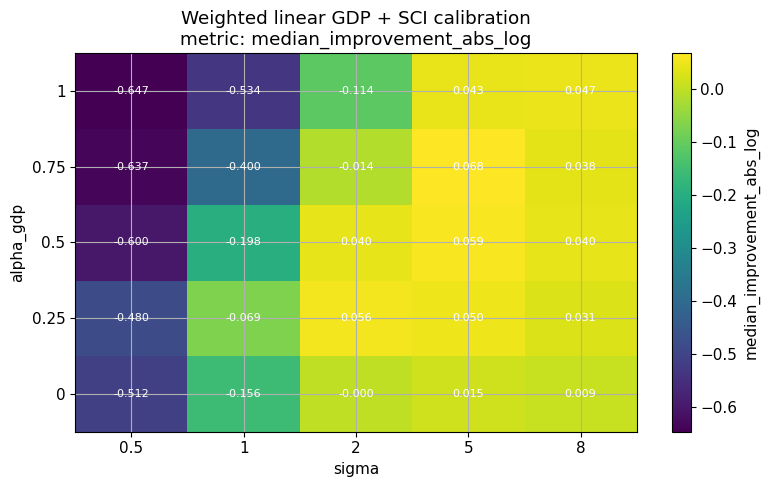

saved: outputs/combined_gdp_sci_figures/06a_weighted_linear_calibration_share_better_abs_log.png


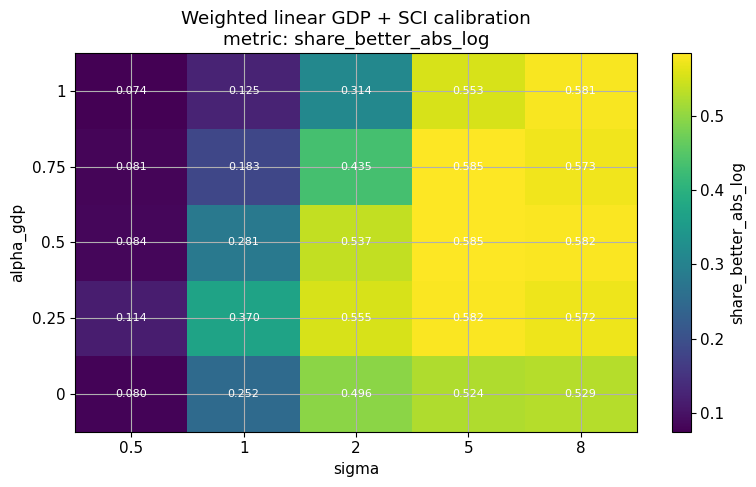

saved: outputs/combined_gdp_sci_figures/06a_weighted_linear_calibration_R2_log_gain_vs_RM.png


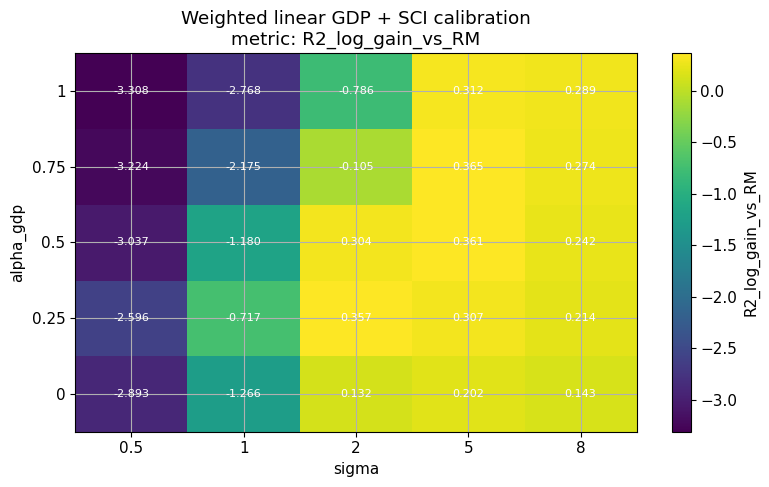

In [190]:
def plot_weighted_linear_calibration(metric="median_improvement_abs_log"):
    if "linear_calibration_df" not in globals() or linear_calibration_df.empty:
        raise ValueError("Run the weighted-linear calibration cell first.")
    pivot = linear_calibration_df.pivot_table(index="alpha_gdp", columns="sigma", values=metric, aggfunc="mean")
    fig, ax = plt.subplots(figsize=(8, 5))
    vals = pivot.to_numpy(dtype=float)
    im = ax.imshow(vals, aspect="auto", origin="lower", cmap="viridis")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([f"{x:g}" for x in pivot.columns])
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([f"{x:g}" for x in pivot.index])
    ax.set_xlabel("sigma")
    ax.set_ylabel("alpha_gdp")
    ax.set_title(f"Weighted linear GDP + SCI calibration\nmetric: {metric}")
    for i in range(vals.shape[0]):
        for j in range(vals.shape[1]):
            if np.isfinite(vals[i, j]):
                ax.text(j, i, f"{vals[i, j]:.3f}", ha="center", va="center", color="white", fontsize=8)
    fig.colorbar(im, ax=ax, label=metric)
    plt.tight_layout()
    savefig(f"06a_weighted_linear_calibration_{metric}")
    plt.show()

plot_weighted_linear_calibration("median_improvement_abs_log")
plot_weighted_linear_calibration("share_better_abs_log")
plot_weighted_linear_calibration("R2_log_gain_vs_RM")


## 6b. Save Simulation Artifacts

This cell freezes the simulation outputs into tidy files. The graph-only notebook should read these files instead of rerunning the models.



In [186]:
# Save simulation artifacts for graph-only notebooks.
# Run this cell after calibration and test evaluation have completed.
import json
from datetime import datetime

ARTIFACT_DIR = Path("outputs/simulation_artifacts/combined_gdp_sci")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)


def _json_safe(value):
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        return float(value)
    if isinstance(value, (np.ndarray,)):
        return value.tolist()
    if isinstance(value, (Path,)):
        return str(value)
    return value


def _attach_distance_columns(df: pd.DataFrame, D: pd.DataFrame | None) -> pd.DataFrame:
    out = df.copy()
    if D is None or "distance_km" in out.columns:
        return out
    def _distance(row):
        try:
            return float(D.loc[row["country_from"], row["country_to"]])
        except Exception:
            return np.nan
    out["distance_km"] = out.apply(_distance, axis=1)
    out["log10_distance"] = np.log10(out["distance_km"].where(out["distance_km"] > 0))
    return out


def _route_exports_from_results(results_dict: dict, split_name: str, D: pd.DataFrame | None) -> pd.DataFrame:
    frames = []
    for key, payload in results_dict.items():
        alpha_gdp = np.nan
        if isinstance(key, tuple):
            if len(key) == 2:
                model_key, sigma = key
            elif len(key) == 3:
                model_key, alpha_gdp, sigma = key
            else:
                raise ValueError(f"Unexpected calibration result key: {key!r}")
            route_df = payload.get("routes")
            spec = MODEL_SPECS.get(model_key, {})
        else:
            model_key = key
            if model_key == "rm":
                continue
            sigma = payload.get("sigma", np.nan) if isinstance(payload, dict) else np.nan
            alpha_gdp = payload.get("alpha_gdp", np.nan) if isinstance(payload, dict) else np.nan
            route_df = route_results.get(model_key) if "route_results" in globals() else None
            spec = MODEL_SPECS.get(model_key, {})
        if route_df is None:
            continue
        out = _attach_distance_columns(route_df, D)
        out.insert(0, "split", split_name)
        out.insert(1, "model_key", model_key)
        out.insert(2, "model_label", spec.get("label", model_key))
        out.insert(3, "family", spec.get("family", "unknown"))
        out.insert(4, "feature_group", spec.get("feature_group", spec.get("kind", "unknown")))
        out.insert(5, "transform", spec.get("transform", spec.get("mode", "")))
        out.insert(6, "sigma", sigma)
        out.insert(7, "alpha_gdp", alpha_gdp)
        frames.append(out)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


calibration_df.to_csv(ARTIFACT_DIR / "calibration_summary.csv", index=False)
best_by_model.to_csv(ARTIFACT_DIR / "best_by_model.csv", index=False)
test_summary.to_csv(ARTIFACT_DIR / "test_summary.csv", index=False)

calibration_routes_export = _route_exports_from_results(calibration_results, "calibration", D_val)
test_routes_export = _route_exports_from_results(test_results, "test", D_test)
calibration_routes_export.to_csv(ARTIFACT_DIR / "calibration_routes.csv.gz", index=False, compression="gzip")
test_routes_export.to_csv(ARTIFACT_DIR / "test_routes.csv.gz", index=False, compression="gzip")

prepare_comp(rm_val.comparison).to_csv(ARTIFACT_DIR / "rm_calibration_comparison.csv", index=False)
prepare_comp(rm_test.comparison).to_csv(ARTIFACT_DIR / "rm_test_comparison.csv", index=False)

if "sigma_diagnostics" in globals():
    sigma_diagnostics_export = sigma_diagnostics.copy()
elif "sigma_diag" in globals():
    sigma_diagnostics_export = sigma_diag.copy()
else:
    sigma_diagnostics_export = pd.DataFrame()
if len(sigma_diagnostics_export):
    sigma_diagnostics_export.to_csv(ARTIFACT_DIR / "sigma_diagnostics.csv", index=False)

metadata = {
    "artifact_name": "combined_gdp_sci",
    "created_at": datetime.now().isoformat(timespec="seconds"),
    "target_continent": TARGET_CONTINENT,
    "calibration_label": CALIBRATION_LABEL,
    "test_label": TEST_LABEL,
    "relational_feature_year": RELATIONAL_FEATURE_YEAR,
    "distance_col": DISTANCE_COL,
    "num_particles": int(NUM_PARTICLES),
    "sigma_grid": [float(x) for x in SIGMA_GRID],
    "model_specs": MODEL_SPECS,
}
for optional_name in ["GDP_TRANSFORM", "SCI_COL", "GDP_COL"]:
    if optional_name in globals():
        metadata[optional_name.lower()] = globals()[optional_name]

with open(ARTIFACT_DIR / "metadata.json", "w") as f:
    json.dump(metadata, f, indent=2, default=_json_safe)

print(f"Saved simulation artifacts to {ARTIFACT_DIR.resolve()}")
print(f"- calibration_summary.csv: {len(calibration_df)} rows")
print(f"- calibration_routes.csv.gz: {len(calibration_routes_export)} rows")
print(f"- test_summary.csv: {len(test_summary)} rows")
print(f"- test_routes.csv.gz: {len(test_routes_export)} rows")



Saved simulation artifacts to /Users/vittoriabettio/Desktop/PhD/Research/FERM/Github/FERM_python/outputs/simulation_artifacts/combined_gdp_sci
- calibration_summary.csv: 50 rows
- calibration_routes.csv.gz: 103500 rows
- test_summary.csv: 7 rows
- test_routes.csv.gz: 12420 rows


saved: outputs/combined_gdp_sci_figures/03_test_summary_combined.png


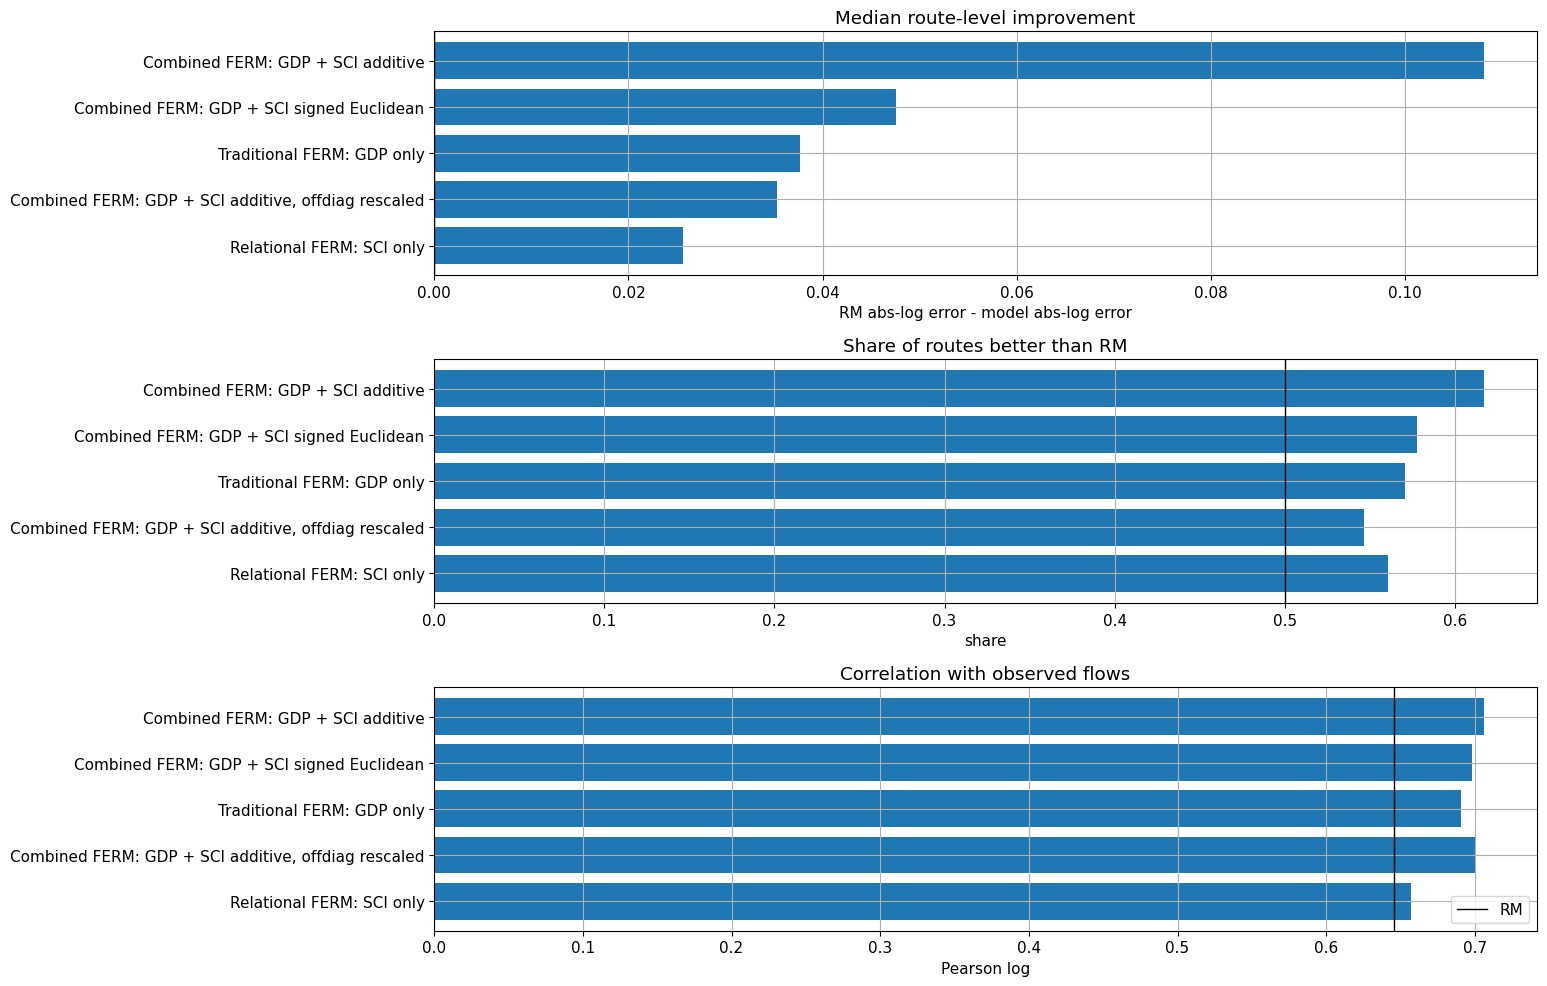

In [146]:
plot_df = test_summary[test_summary["model"] != "rm"].copy()
plot_df = plot_df.sort_values("median_improvement_abs_log")

fig, axes = plt.subplots(3, 1, figsize=(5.2*3, 10))

axes[0].barh(plot_df["label"], plot_df["median_improvement_abs_log"])
axes[0].axvline(0, color="black", linewidth=1)
axes[0].set_title("Median route-level improvement")
axes[0].set_xlabel("RM abs-log error - model abs-log error")

axes[1].barh(plot_df["label"], plot_df["share_better_abs_log"])
axes[1].axvline(0.5, color="black", linewidth=1)
axes[1].set_title("Share of routes better than RM")
axes[1].set_xlabel("share")

axes[2].barh(plot_df["label"], plot_df["Pearson_log"])
axes[2].axvline(test_summary.loc[test_summary["model"] == "rm", "Pearson_log"].iloc[0], color="black", linewidth=1, label="RM")
axes[2].set_title("Correlation with observed flows")
axes[2].set_xlabel("Pearson log")
axes[2].legend()

plt.tight_layout()
savefig("03_test_summary_combined")
plt.show()


## 6c. External Benchmark: Gaskin-Abel 2026

Gaskin & Abel (2026) provide annual model-based bilateral migration estimates. Here they are used as an **external reference model**, not as observed ground truth.

Because this notebook evaluates `test_2019_h2` while Gaskin-Abel is annual, the benchmark flows are globally rescaled to the same total as the matched test routes before count-level comparisons. The diagnostic asks whether each FERM variant moves closer than RM to the external benchmark on the same OD corridors.



In [173]:
GASKIN_ABEL_PATH = Path("data/gaskin_abel_2026/mig_bilateral.csv")
GASKIN_ABEL_YEAR = RELATIONAL_FEATURE_YEAR
GASKIN_ABEL_FLOW_COL = "mig_prev"  # previous-country OD flow; use "mig_brth" for birth-destination sensitivity


def load_gaskin_abel_bilateral(path=GASKIN_ABEL_PATH, year=GASKIN_ABEL_YEAR, flow_col=GASKIN_ABEL_FLOW_COL):
    if not Path(path).exists():
        raise FileNotFoundError(
            f"Missing {path}. Download from "
            "https://huggingface.co/datasets/ThGaskin/Migration_flows/resolve/main/Estimates/mig_bilateral.csv"
        )
    usecols = ["Origin ISO", "Destination ISO", "Year", flow_col]
    std_col = f"{flow_col}_std"
    preview_cols = pd.read_csv(path, nrows=0).columns
    if std_col in preview_cols:
        usecols.append(std_col)
    ga = pd.read_csv(path, usecols=usecols)
    ga = ga[ga["Year"] == int(year)].copy()
    ga = ga.rename(columns={
        "Origin ISO": "country_from",
        "Destination ISO": "country_to",
        flow_col: "ga_flow",
        std_col: "ga_flow_std",
    })
    ga["country_from"] = ga["country_from"].astype(str).str.strip().str.upper()
    ga["country_to"] = ga["country_to"].astype(str).str.strip().str.upper()
    ga["ga_flow"] = pd.to_numeric(ga["ga_flow"], errors="coerce").fillna(0.0).clip(lower=0.0)
    if "ga_flow_std" in ga.columns:
        ga["ga_flow_std"] = pd.to_numeric(ga["ga_flow_std"], errors="coerce").fillna(0.0).clip(lower=0.0)
    return ga


def comp_for_external_benchmark(comp: pd.DataFrame, pred_col_name: str) -> pd.DataFrame:
    c = prepare_comp(comp)
    return c[["country_from", "country_to", "country_from_name", "country_to_name", "num_migrants", "predicted_migrants"]].rename(
        columns={"predicted_migrants": pred_col_name}
    )


def build_gaskin_abel_panel(ga_df: pd.DataFrame, test_results: dict, scale_to_observed_total=True):
    rm = comp_for_external_benchmark(test_results["rm"]["result"].comparison, "pred_rm")
    panel = rm.merge(ga_df[["country_from", "country_to", "ga_flow"]], on=["country_from", "country_to"], how="inner")
    panel = panel[panel["country_from"] != panel["country_to"]].copy()

    if scale_to_observed_total:
        observed_total = panel["num_migrants"].sum()
        ga_total = panel["ga_flow"].sum()
        panel["ga_flow_scaled"] = panel["ga_flow"] * observed_total / ga_total if ga_total > 0 else panel["ga_flow"]
    else:
        panel["ga_flow_scaled"] = panel["ga_flow"]

    for model_key, payload in test_results.items():
        if model_key == "rm":
            continue
        pred = comp_for_external_benchmark(payload["result"].comparison, f"pred_{model_key}")[["country_from", "country_to", f"pred_{model_key}"]]
        panel = panel.merge(pred, on=["country_from", "country_to"], how="inner")

    return panel


def benchmark_metrics_against_ga(panel: pd.DataFrame, model_key: str) -> dict:
    ga_log = log10p(panel["ga_flow_scaled"])
    rm_log = log10p(panel["pred_rm"])
    model_log = log10p(panel[f"pred_{model_key}"])

    rm_abs = np.abs(rm_log - ga_log)
    model_abs = np.abs(model_log - ga_log)
    improvement = rm_abs - model_abs

    # Allocation comparison: normalize benchmark and predictions within each origin over the matched destinations.
    share_df = panel[["country_from", "ga_flow_scaled", "pred_rm", f"pred_{model_key}"]].copy()
    eps_share = 1e-12
    for col in ["ga_flow_scaled", "pred_rm", f"pred_{model_key}"]:
        denom = share_df.groupby("country_from")[col].transform("sum")
        share_df[f"p_{col}"] = np.where(denom > 0, share_df[col] / denom, np.nan)
    rm_share_abs = np.abs(np.log10((share_df["p_pred_rm"] + eps_share) / (share_df["p_ga_flow_scaled"] + eps_share)))
    model_share_abs = np.abs(np.log10((share_df[f"p_pred_{model_key}"] + eps_share) / (share_df["p_ga_flow_scaled"] + eps_share)))

    return {
        "model": model_key,
        "label": test_results[model_key]["label"],
        "sigma": test_results[model_key].get("sigma", np.nan),
        "matched_routes": len(panel),
        "median_gain_vs_RM_to_GA": np.nanmedian(improvement),
        "mean_gain_vs_RM_to_GA": np.nanmean(improvement),
        "share_closer_to_GA_than_RM": np.nanmean(improvement > 0),
        "R2_log_to_GA": predictive_r2_from_logs(ga_log, model_log),
        "R2_log_RM_to_GA": predictive_r2_from_logs(ga_log, rm_log),
        "Pearson_log_to_GA": pd.Series(ga_log).corr(pd.Series(model_log), method="pearson"),
        "median_share_gain_vs_RM_to_GA": np.nanmedian(rm_share_abs - model_share_abs),
        "share_closer_to_GA_origin_shares": np.nanmean((rm_share_abs - model_share_abs) > 0),
    }


ga_bilateral = load_gaskin_abel_bilateral()
ga_panel = build_gaskin_abel_panel(ga_bilateral, test_results, scale_to_observed_total=True)

ga_rows = []
for model_key in test_results:
    if model_key == "rm":
        continue
    ga_rows.append(benchmark_metrics_against_ga(ga_panel, model_key))

ga_benchmark_summary = pd.DataFrame(ga_rows).sort_values(
    ["median_gain_vs_RM_to_GA", "share_closer_to_GA_than_RM"],
    ascending=[False, False],
).reset_index(drop=True)

display(ga_benchmark_summary)
ga_benchmark_summary.to_csv(FIG_DIR / "06a_gaskin_abel_benchmark_summary.csv", index=False)
print(f"Matched routes with Gaskin-Abel {GASKIN_ABEL_YEAR} ({GASKIN_ABEL_FLOW_COL}): {len(ga_panel)}")
print("Positive gain means the model is closer than RM to the Gaskin-Abel external benchmark.")


,model,label,sigma,matched_routes,median_gain_vs_RM_to_GA,mean_gain_vs_RM_to_GA,share_closer_to_GA_than_RM,R2_log_to_GA,R2_log_RM_to_GA,Pearson_log_to_GA,median_share_gain_vs_RM_to_GA,share_closer_to_GA_origin_shares
0,combined_additive,Combined FERM: GDP + SCI additive,5.0,2070,0.132084,0.219694,0.631884,-0.177635,-0.861624,0.776864,0.255324,0.633333
1,combined_euclidean,Combined FERM: GDP + SCI signed Euclidean,8.0,2070,0.055065,0.139918,0.580676,-0.414088,-0.861624,0.764282,0.100671,0.583092
2,gdp_only,Traditional FERM: GDP only,8.0,2070,0.048720,0.112594,0.582609,-0.497353,-0.861624,0.760147,0.096378,0.588889
3,combined_additive_rescaled,"Combined FERM: GDP + SCI additive, offdiag res...",5.0,2070,0.034209,0.103424,0.541546,-0.487459,-0.861624,0.766914,0.076865,0.545894
4,sci_only,Relational FERM: SCI only,5.0,2070,0.031905,0.067126,0.571014,-0.621303,-0.861624,0.713560,0.058222,0.572947


Matched routes with Gaskin-Abel 2019 (mig_prev): 2070
Positive gain means the model is closer than RM to the Gaskin-Abel external benchmark.


saved: outputs/combined_gdp_sci_figures/06a_gaskin_abel_external_benchmark_summary.png


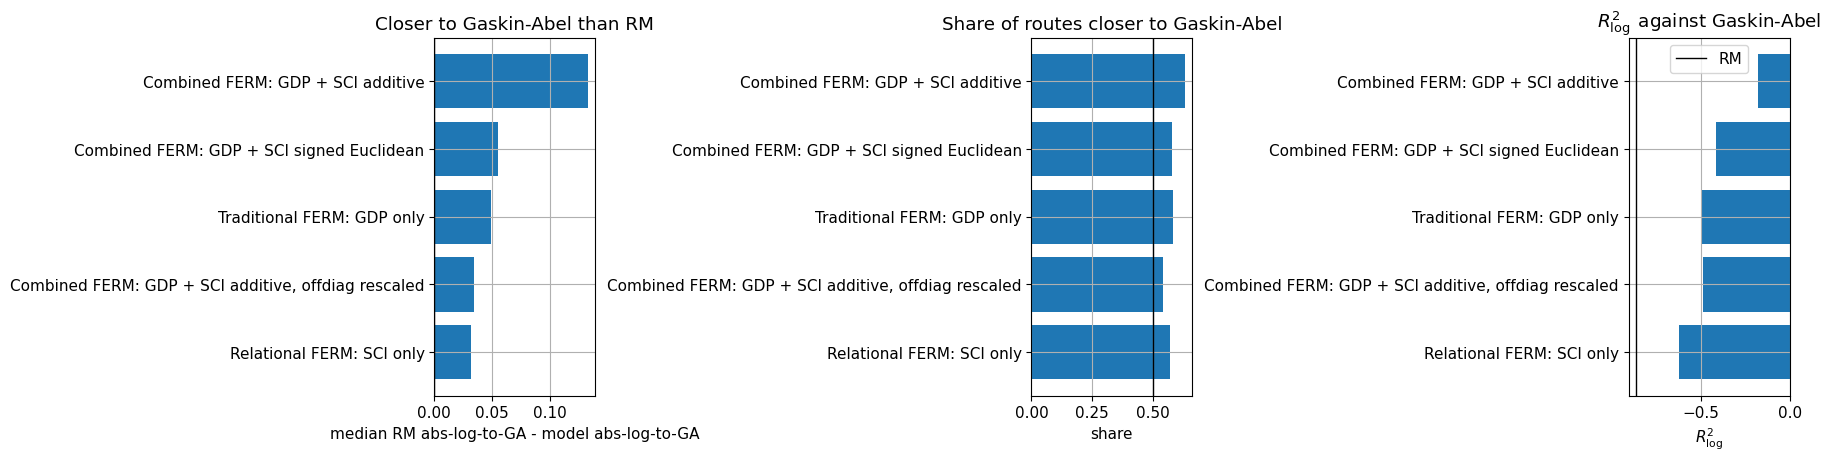

saved: outputs/combined_gdp_sci_figures/06b_gaskin_abel_best_route_error_scatter.png


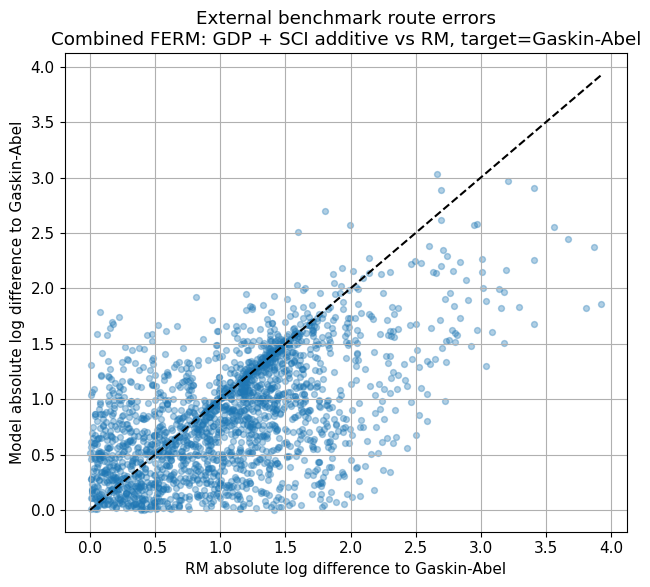

saved: outputs/combined_gdp_sci_figures/06c_gaskin_abel_shift_alignment.png


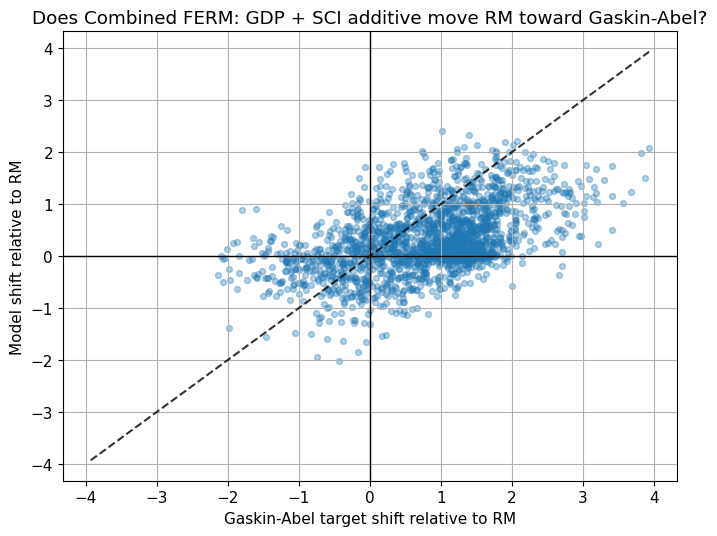

In [174]:
plot_df = ga_benchmark_summary.sort_values("median_gain_vs_RM_to_GA")

fig, axes = plt.subplots(1, 3, figsize=(18, max(4.5, 0.55 * len(plot_df))), constrained_layout=True)

axes[0].barh(plot_df["label"], plot_df["median_gain_vs_RM_to_GA"])
axes[0].axvline(0, color="black", linewidth=1)
axes[0].set_title("Closer to Gaskin-Abel than RM")
axes[0].set_xlabel("median RM abs-log-to-GA - model abs-log-to-GA")

axes[1].barh(plot_df["label"], plot_df["share_closer_to_GA_than_RM"])
axes[1].axvline(0.5, color="black", linewidth=1)
axes[1].set_title("Share of routes closer to Gaskin-Abel")
axes[1].set_xlabel("share")

axes[2].barh(plot_df["label"], plot_df["R2_log_to_GA"])
axes[2].axvline(plot_df["R2_log_RM_to_GA"].iloc[0], color="black", linewidth=1, label="RM")
axes[2].set_title("$R^2_{\\log}$ against Gaskin-Abel")
axes[2].set_xlabel("$R^2_{\\log}$")
axes[2].legend()

savefig("06a_gaskin_abel_external_benchmark_summary")
plt.show()

# Route-level scatter for the best model by median benchmark gain.
best_ga_key = ga_benchmark_summary.iloc[0]["model"]
best_ga_label = ga_benchmark_summary.iloc[0]["label"]
ga_log = log10p(ga_panel["ga_flow_scaled"])
rm_abs = np.abs(log10p(ga_panel["pred_rm"]) - ga_log)
model_abs = np.abs(log10p(ga_panel[f"pred_{best_ga_key}"]) - ga_log)

fig, ax = plt.subplots(figsize=(6.5, 6))
ax.scatter(rm_abs, model_abs, alpha=0.35, s=18)
lim = max(np.nanmax(rm_abs), np.nanmax(model_abs))
ax.plot([0, lim], [0, lim], linestyle="--", color="black")
ax.set_title(f"External benchmark route errors\n{best_ga_label} vs RM, target=Gaskin-Abel")
ax.set_xlabel("RM absolute log difference to Gaskin-Abel")
ax.set_ylabel("Model absolute log difference to Gaskin-Abel")
plt.tight_layout()
savefig("06b_gaskin_abel_best_route_error_scatter")
plt.show()

# Does the model move RM predictions in the direction suggested by Gaskin-Abel?
needed_shift = log10p(ga_panel["ga_flow_scaled"]) - log10p(ga_panel["pred_rm"])
model_shift = log10p(ga_panel[f"pred_{best_ga_key}"]) - log10p(ga_panel["pred_rm"])

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.scatter(needed_shift, model_shift, alpha=0.35, s=18)
ax.axhline(0, color="black", linewidth=1)
ax.axvline(0, color="black", linewidth=1)
lim = max(np.nanmax(np.abs(needed_shift)), np.nanmax(np.abs(model_shift)))
ax.plot([-lim, lim], [-lim, lim], linestyle="--", color="black", alpha=0.8)
ax.set_title(f"Does {best_ga_label} move RM toward Gaskin-Abel?")
ax.set_xlabel("Gaskin-Abel target shift relative to RM")
ax.set_ylabel("Model shift relative to RM")
plt.tight_layout()
savefig("06c_gaskin_abel_shift_alignment")
plt.show()


## 7. Route-Level Diagnostics



saved: outputs/combined_gdp_sci_figures/04_route_error_scatter_combined.png


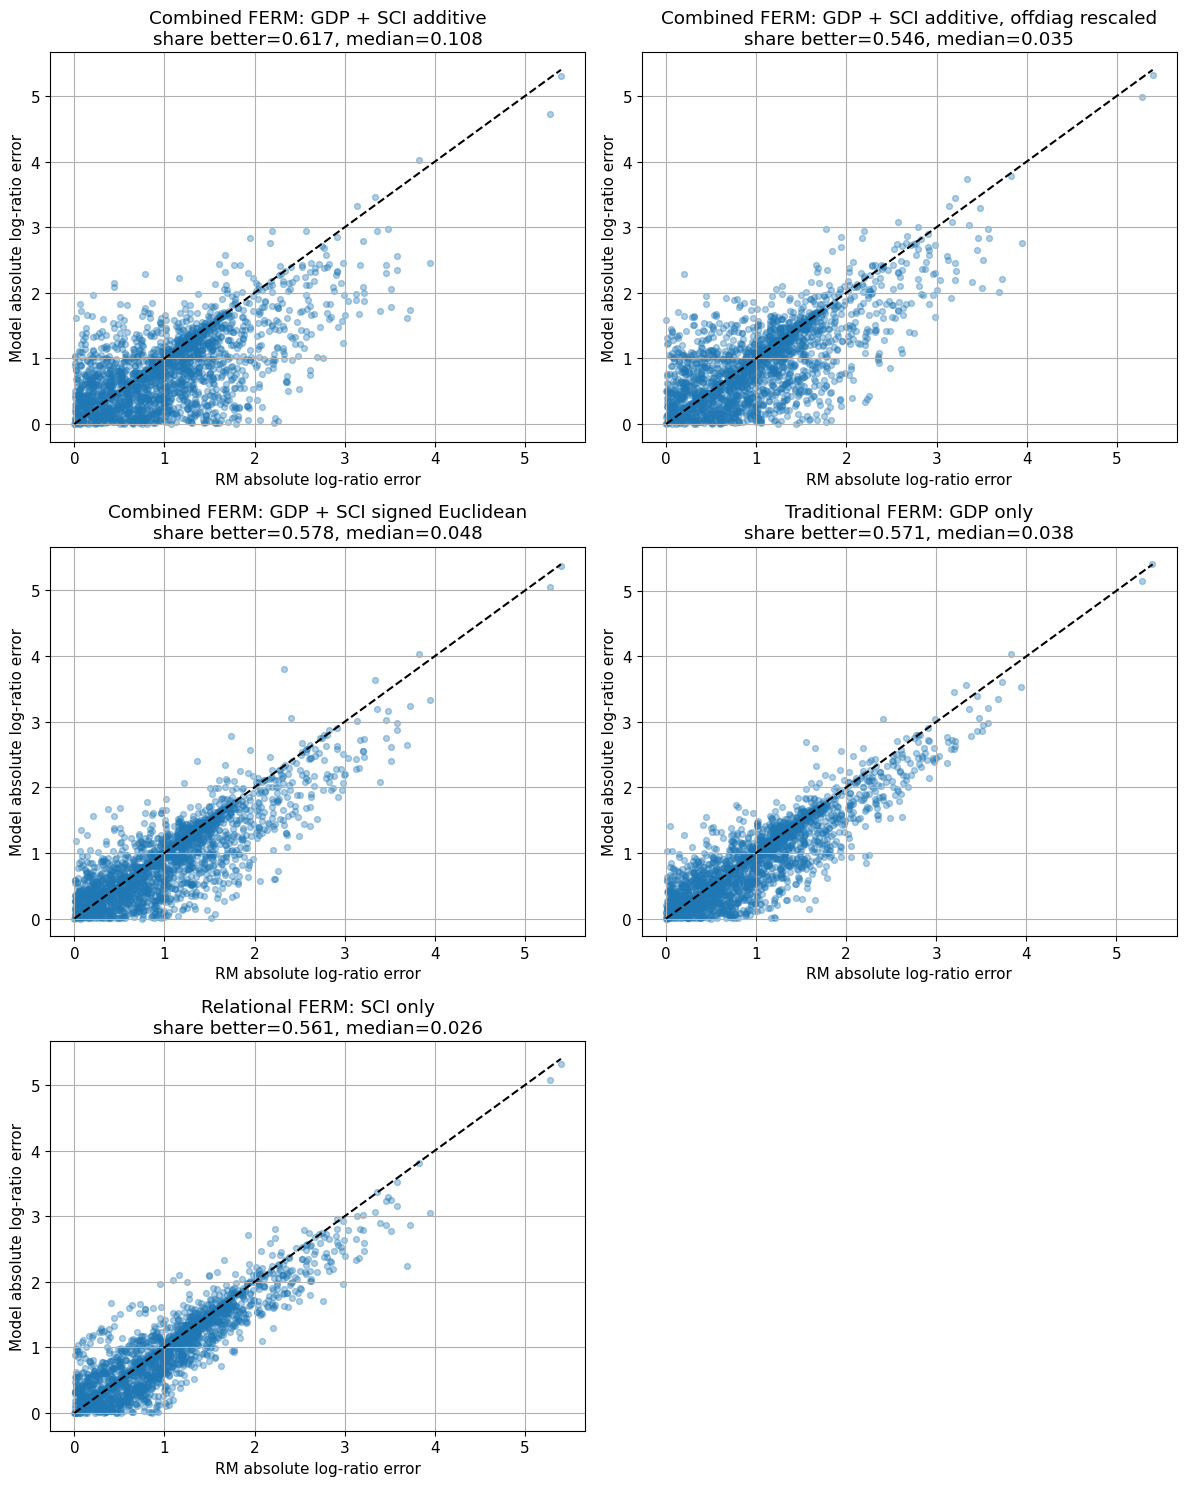

In [147]:
def route_error_panel(model_keys=None):
    if model_keys is None:
        model_keys = list(route_results.keys())
    n = len(model_keys)
    ncols = 2
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows), squeeze=False)
    for ax, model_key in zip(axes.flat, model_keys):
        r = route_results[model_key]
        ycol = f"abs_log_{model_key}"
        ax.scatter(r["abs_log_rm"], r[ycol], alpha=0.35, s=18)
        lim = max(r["abs_log_rm"].max(), r[ycol].max())
        ax.plot([0, lim], [0, lim], linestyle="--", color="black")
        ax.set_title(
            f"{MODEL_SPECS[model_key]['label']}\n"
            f"share better={(r['improvement_abs_log'] > 0).mean():.3f}, "
            f"median={r['improvement_abs_log'].median():.3f}"
        )
        ax.set_xlabel("RM absolute log-ratio error")
        ax.set_ylabel("Model absolute log-ratio error")
    for ax in axes.flat[n:]:
        ax.axis("off")
    plt.tight_layout()
    savefig("04_route_error_scatter_combined")
    plt.show()

route_error_panel()


,best_label,routes,observed_total,median_observed,route_share
0,Combined FERM: GDP + SCI additive,737,2670395.0,95.0,0.356039
1,Relational FERM: SCI only,398,1116396.0,47.0,0.192271
2,RM,296,607464.0,37.0,0.142995
3,"Combined FERM: GDP + SCI additive, offdiag res...",240,692061.0,68.5,0.115942
4,Combined FERM: GDP + SCI signed Euclidean,212,768096.0,45.5,0.102415
5,Traditional FERM: GDP only,187,331636.0,55.0,0.090338


saved: outputs/combined_gdp_sci_figures/05_route_winners_combined.png


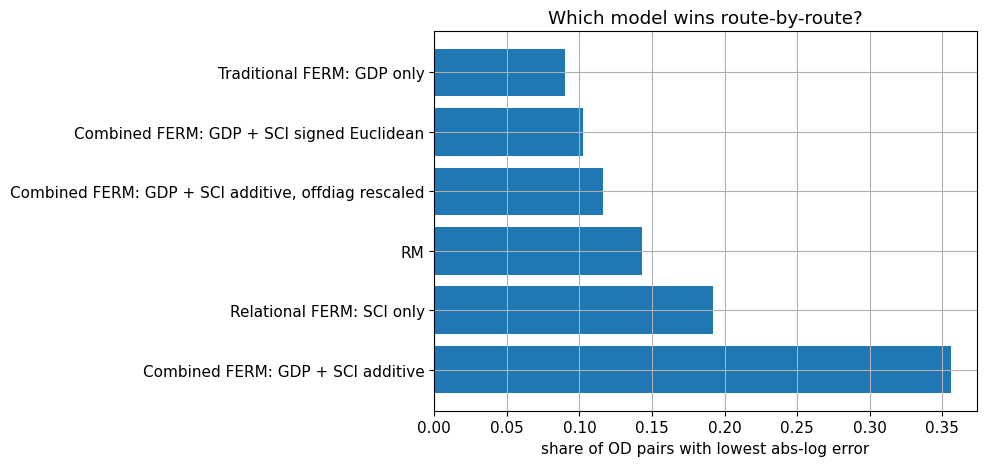

In [148]:
# Winner analysis: for each route, which model has the lowest abs-log error?
base = prepare_comp(rm_test.comparison)[["country_from", "country_to", "country_from_name", "country_to_name", "num_migrants", "abs_log_ratio"]].rename(columns={"abs_log_ratio": "rm"})
error_frames = [base]
for model_key, info in test_results.items():
    if model_key == "rm":
        continue
    comp = prepare_comp(info["result"].comparison)[["country_from", "country_to", "abs_log_ratio"]].rename(columns={"abs_log_ratio": model_key})
    error_frames.append(comp)

error_panel = reduce(lambda left, right: left.merge(right, on=["country_from", "country_to"], how="inner"), error_frames)
error_cols = ["rm"] + [k for k in test_results if k != "rm"]
error_panel["best_model"] = error_panel[error_cols].idxmin(axis=1)
error_panel["best_label"] = error_panel["best_model"].map(lambda k: "RM" if k == "rm" else MODEL_SPECS[k]["label"])

winner_summary = (
    error_panel.groupby("best_label")
    .agg(routes=("best_label", "size"), observed_total=("num_migrants", "sum"), median_observed=("num_migrants", "median"))
    .sort_values("routes", ascending=False)
    .reset_index()
)
winner_summary["route_share"] = winner_summary["routes"] / len(error_panel)
display(winner_summary)

fig, ax = plt.subplots(figsize=(10, 4.8))
ax.barh(winner_summary["best_label"], winner_summary["route_share"])
ax.set_title("Which model wins route-by-route?")
ax.set_xlabel("share of OD pairs with lowest abs-log error")
plt.tight_layout()
savefig("05_route_winners_combined")
plt.show()


## 8. Spatial Route Diagnostics

These maps use the existing route-change plotting utilities in `src.ferm.plotting`. Green/blue routes are routes where the model improves relative to the benchmark; orange/red routes are routes where it worsens. Line width scales with the size of the improvement or deterioration.



saved: outputs/combined_gdp_sci_figures/06_route_change_vs_rm_combined_additive.png


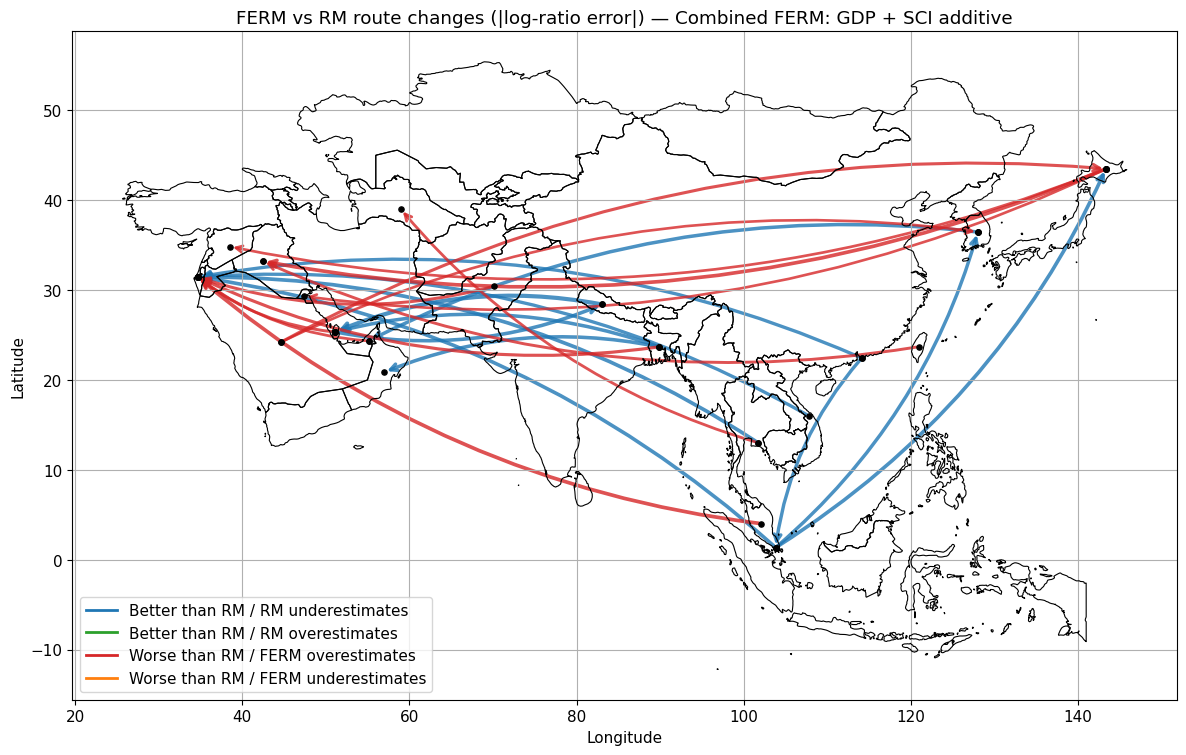

saved: outputs/combined_gdp_sci_figures/06_route_change_vs_rm_combined_additive_rescaled.png


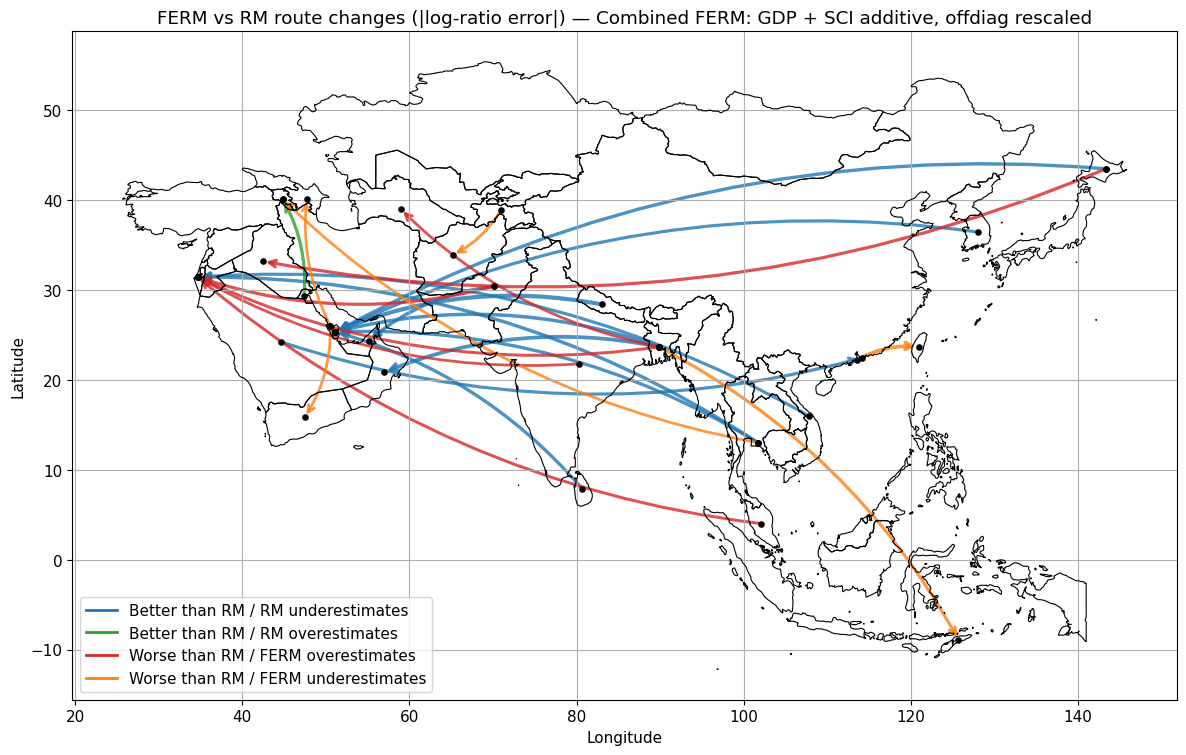

saved: outputs/combined_gdp_sci_figures/06_route_change_vs_rm_combined_euclidean.png


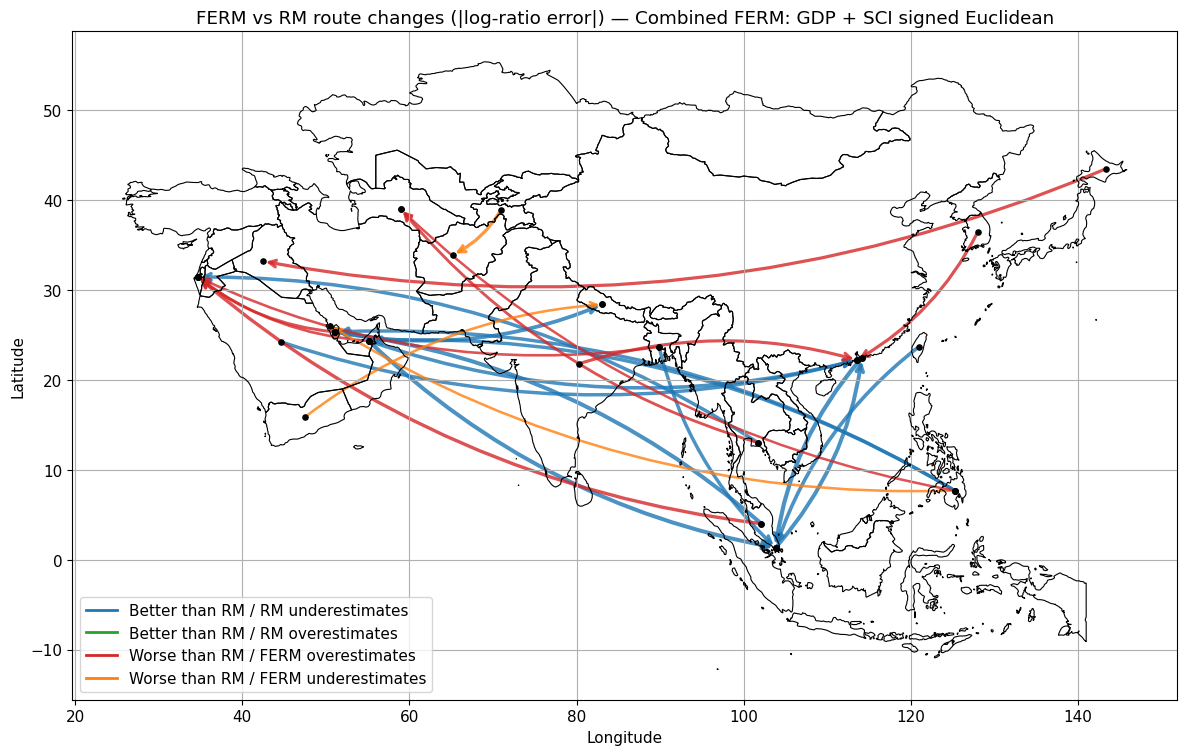

saved: outputs/combined_gdp_sci_figures/06_route_change_vs_rm_gdp_only.png


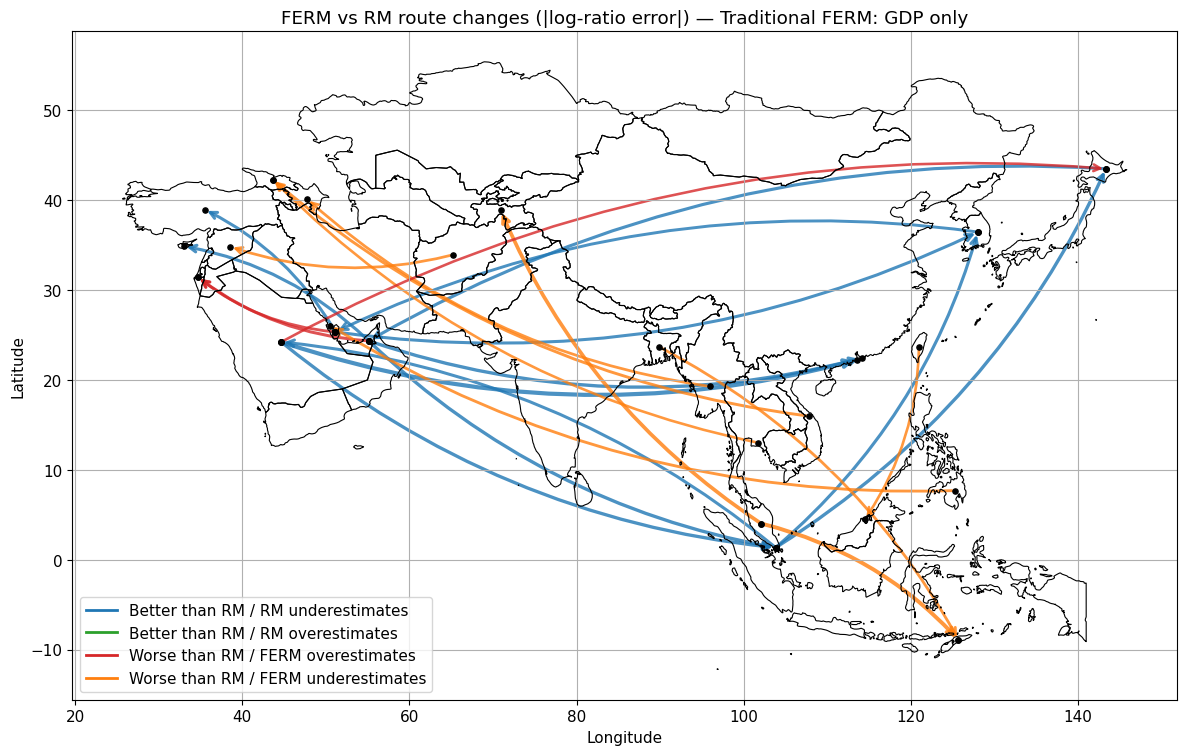

saved: outputs/combined_gdp_sci_figures/06_route_change_vs_rm_sci_only.png


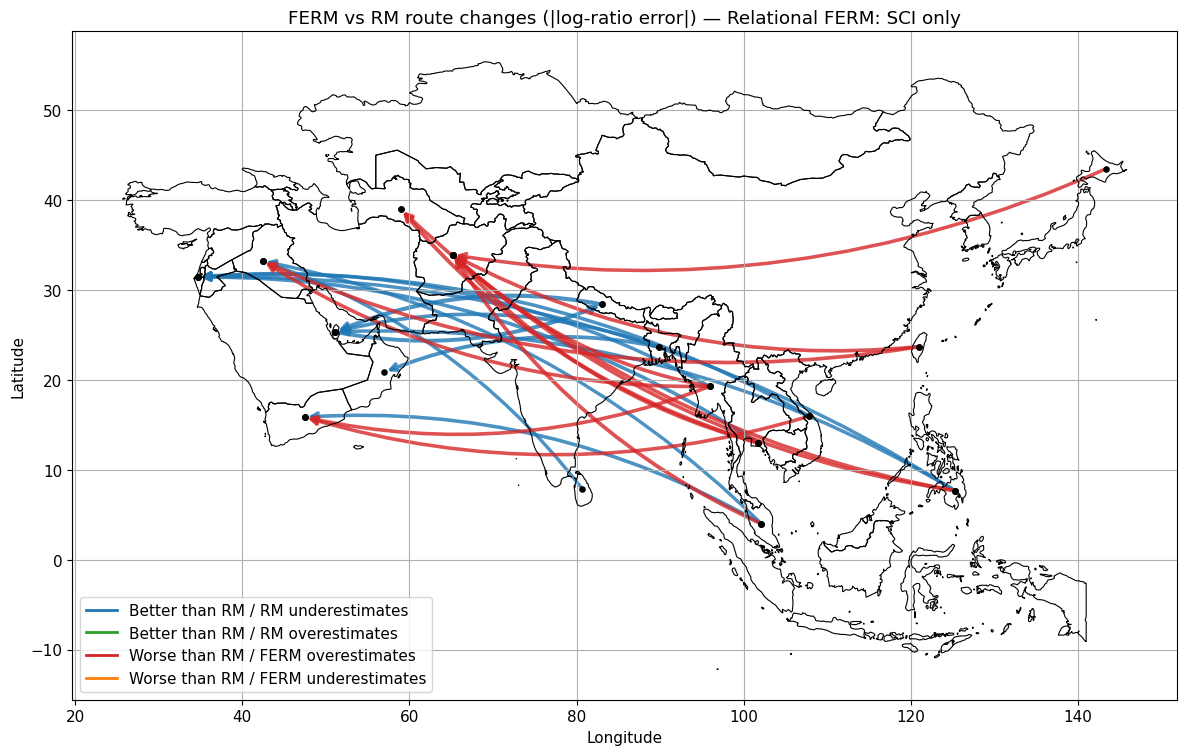

In [117]:
import src.ferm.plotting as ferm_plotting
importlib.reload(ferm_plotting)
plot_ferm_vs_rm_route_change = ferm_plotting.plot_ferm_vs_rm_route_change


def continent_subset(world_gdf, target_continent=TARGET_CONTINENT):
    if world_gdf is None:
        return None
    for col in ["CONTINENT", "continent", "Continent"]:
        if col in world_gdf.columns:
            sub = world_gdf[world_gdf[col].astype(str).str.lower() == str(target_continent).lower()].copy()
            if len(sub):
                return sub
    return world_gdf


continent_gdf = continent_subset(world_gdf, TARGET_CONTINENT)


def plotting_comp(comp: pd.DataFrame) -> pd.DataFrame:
    out = comp.copy()
    if "total_migrants" not in out.columns and "num_migrants" in out.columns:
        out = out.rename(columns={"num_migrants": "total_migrants"})
    return out


def plot_route_change_maps_vs_rm(model_keys=None, top_n=12, metric="abs_log"):
    if model_keys is None:
        model_keys = list(route_results.keys())

    plotted_routes = {}
    comp_rm = plotting_comp(test_results["rm"]["result"].comparison)
    for model_key in model_keys:
        label = MODEL_SPECS[model_key]["label"]
        comp_model = plotting_comp(test_results[model_key]["result"].comparison)
        plotted_routes[model_key] = plot_ferm_vs_rm_route_change(
            comp_rm,
            comp_model,
            country_geo=country_geo,
            continent_gdf=continent_gdf,
            top_n_improve=top_n,
            top_n_worsen=top_n,
            metric=metric,
            label=label,
            benchmark_label="RM",
            model_label="FERM",
            min_linewidth=0.35,
            max_linewidth=3,
            show=False,
        )
        savefig(f"06_route_change_vs_rm_{model_key}")
        plt.show()
        plt.close()
    return plotted_routes


route_change_maps_vs_rm = plot_route_change_maps_vs_rm()


### Color-Criterion Diagnostics for Maps vs RM

For each model-vs-RM map, this graph explains the route colors. The top bar compares all routes with the top routes drawn on the map. The scatter shows RM signed error on the x-axis and model signed error on the y-axis; circled points are the mapped routes.



,all routes,mapped top routes
map_class,,
Better than RM / RM underestimates,1109,12
Better than RM / RM overestimates,212,0
Worse than RM / FERM overestimates,362,12
Worse than RM / FERM underestimates,387,0


saved: outputs/combined_gdp_sci_figures/06b_color_criterion_vs_rm_combined_additive.png


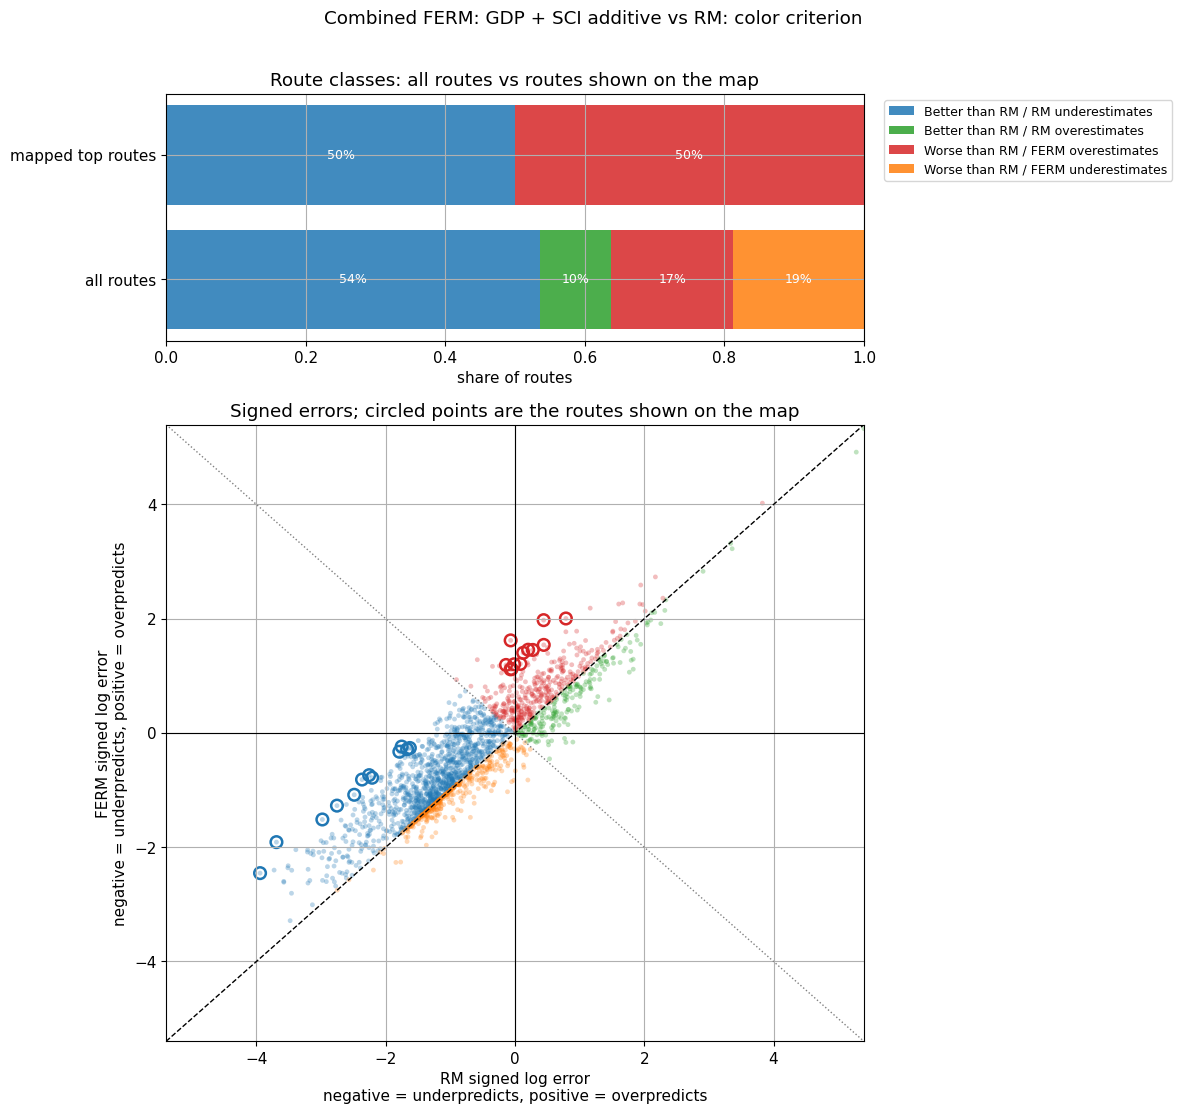

,all routes,mapped top routes
map_class,,
Better than RM / RM underestimates,894,11
Better than RM / RM overestimates,251,1
Worse than RM / FERM overestimates,260,6
Worse than RM / FERM underestimates,665,6


saved: outputs/combined_gdp_sci_figures/06b_color_criterion_vs_rm_combined_additive_rescaled.png


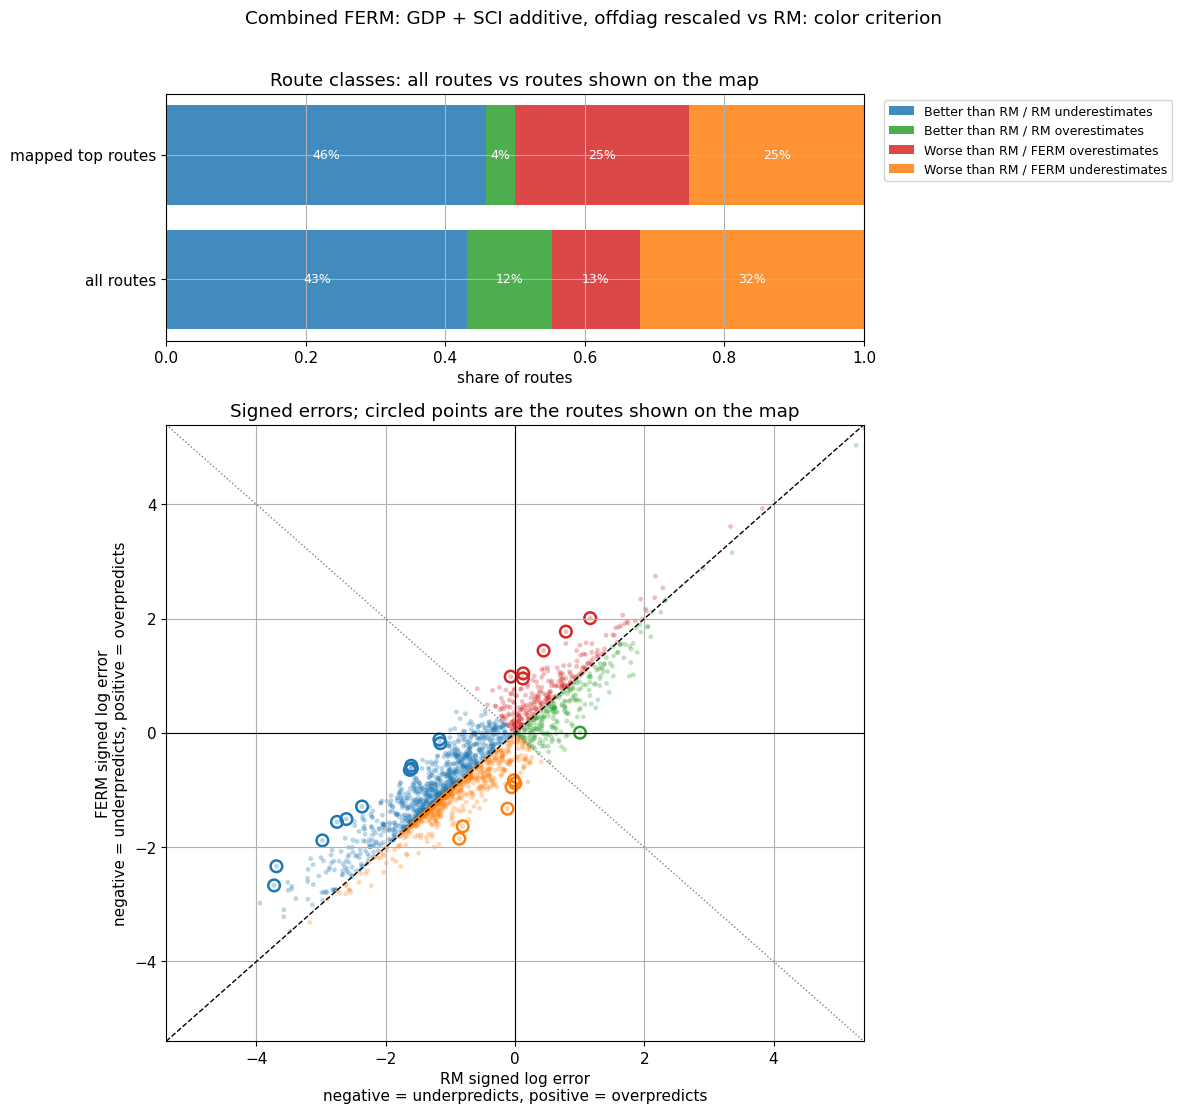

,all routes,mapped top routes
map_class,,
Better than RM / RM underestimates,1039,12
Better than RM / RM overestimates,199,0
Worse than RM / FERM overestimates,350,9
Worse than RM / FERM underestimates,482,3


saved: outputs/combined_gdp_sci_figures/06b_color_criterion_vs_rm_combined_euclidean.png


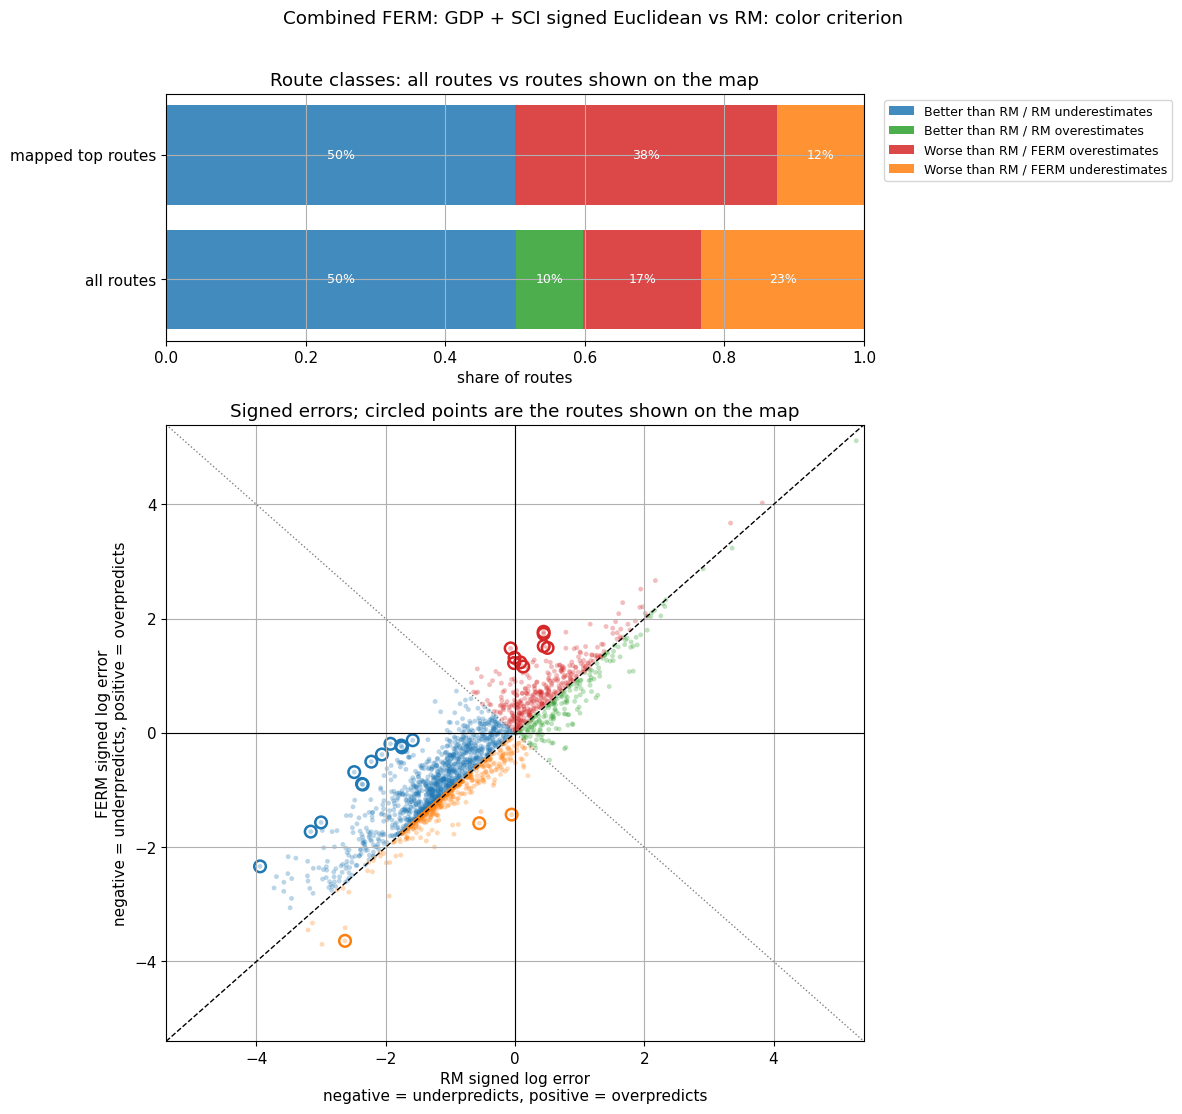

,all routes,mapped top routes
map_class,,
Better than RM / RM underestimates,930,12
Better than RM / RM overestimates,254,0
Worse than RM / FERM overestimates,257,3
Worse than RM / FERM underestimates,629,9


saved: outputs/combined_gdp_sci_figures/06b_color_criterion_vs_rm_gdp_only.png


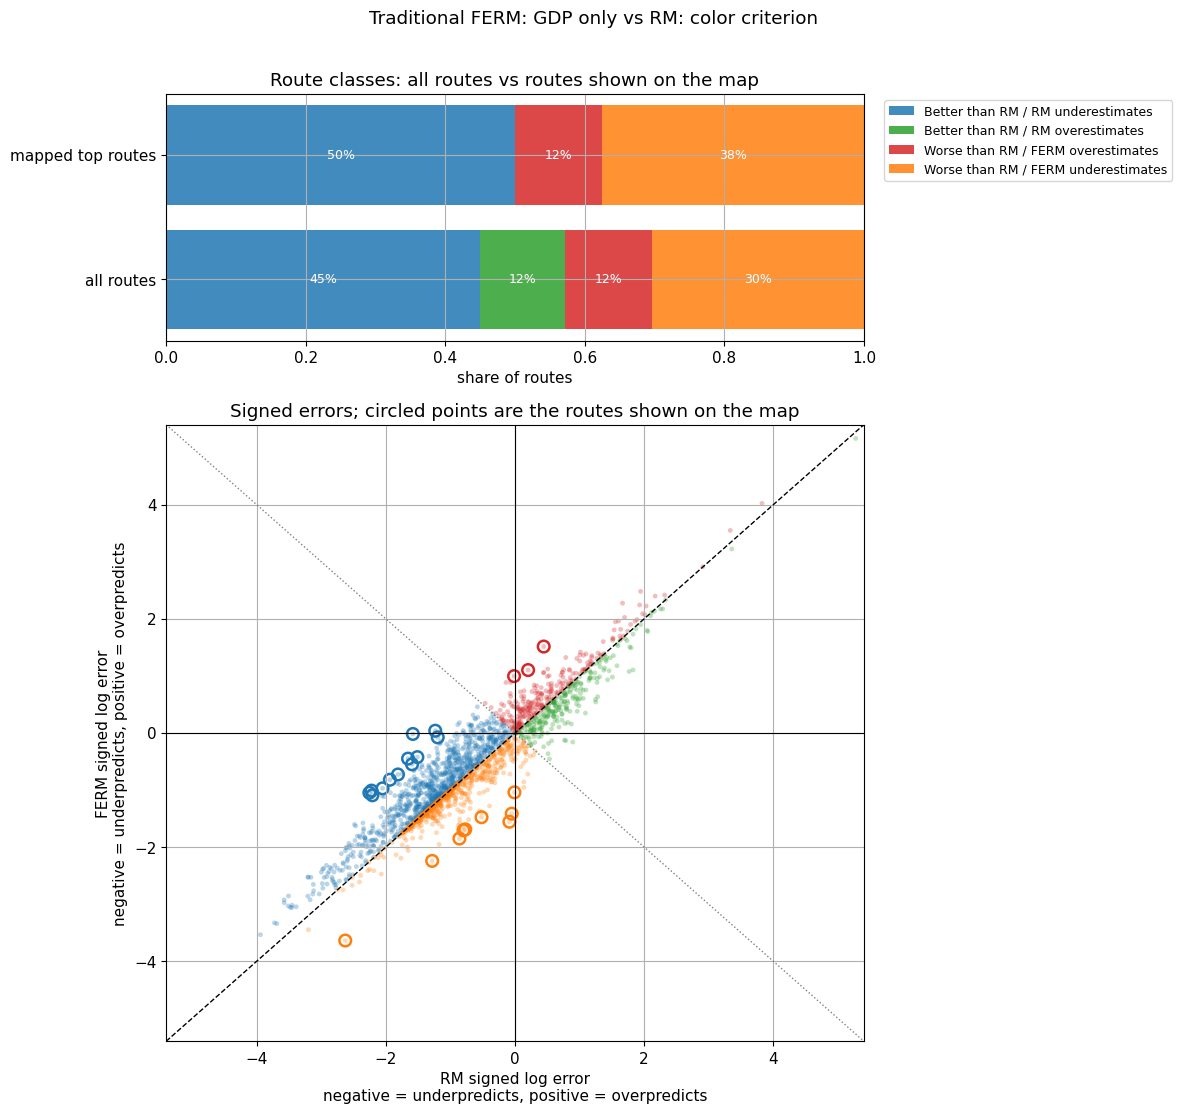

,all routes,mapped top routes
map_class,,
Better than RM / RM underestimates,993,12
Better than RM / RM overestimates,187,0
Worse than RM / FERM overestimates,366,12
Worse than RM / FERM underestimates,524,0


saved: outputs/combined_gdp_sci_figures/06b_color_criterion_vs_rm_sci_only.png


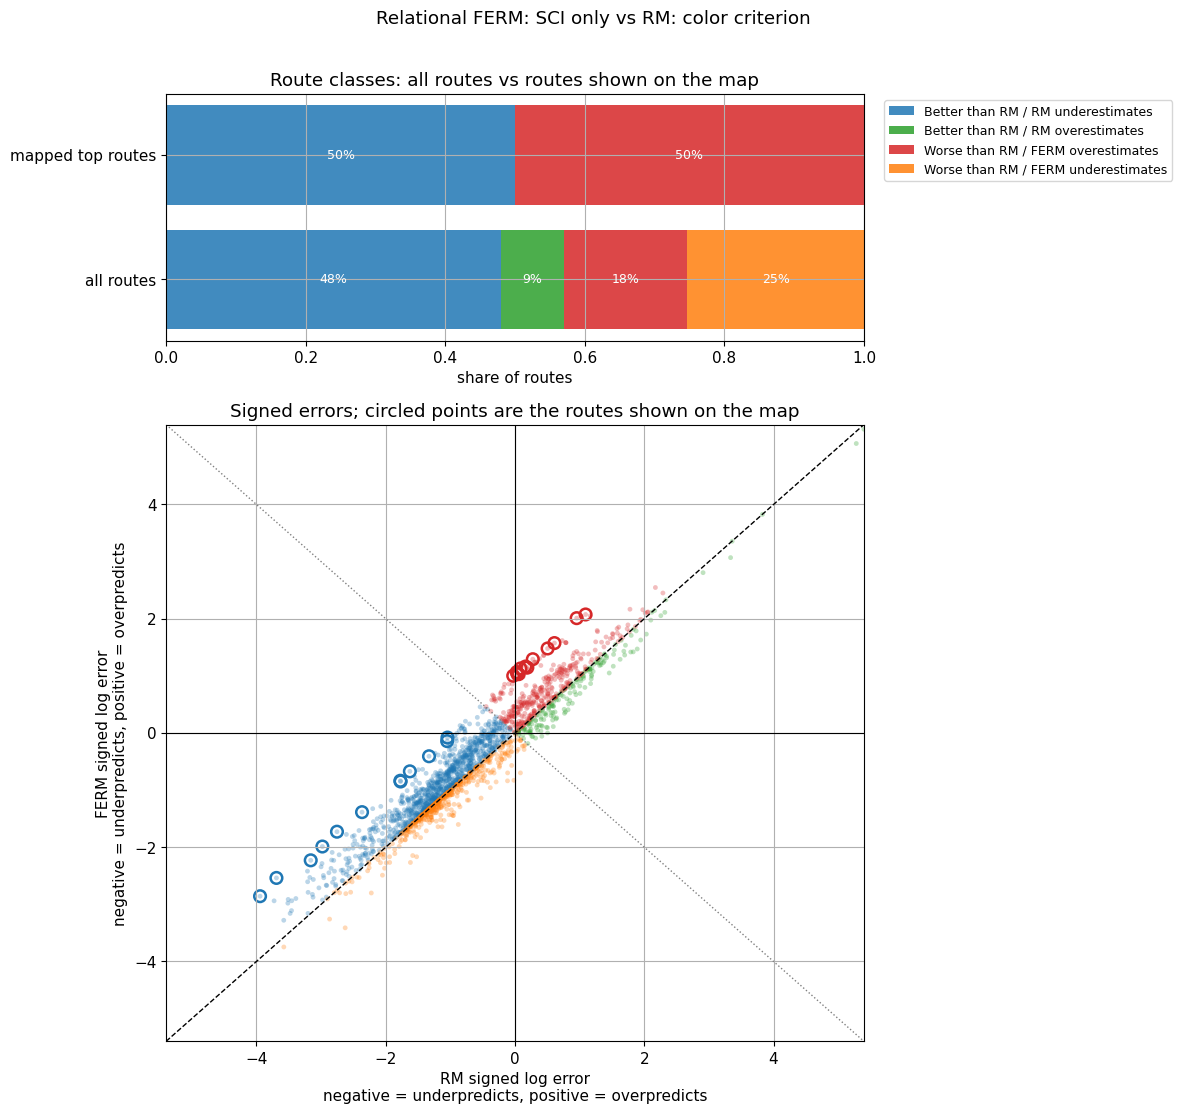

In [118]:
def signed_error_panel_vs_benchmark(benchmark_key, model_key, benchmark_label=None, model_label=None, top_n=12):
    benchmark_label = benchmark_label or ("RM" if benchmark_key == "rm" else MODEL_SPECS[benchmark_key]["label"])
    model_label = model_label or MODEL_SPECS[model_key]["label"]

    base = prepare_comp(test_results[benchmark_key]["result"].comparison).copy()
    model = prepare_comp(test_results[model_key]["result"].comparison).copy()

    base = base[[
        "country_from", "country_to", "country_from_name", "country_to_name", "num_migrants",
        "predicted_migrants", "log_ratio", "abs_log_ratio",
    ]].rename(columns={
        "predicted_migrants": "pred_benchmark",
        "log_ratio": "signed_log_benchmark",
        "abs_log_ratio": "abs_log_benchmark",
    })
    model = model[["country_from", "country_to", "predicted_migrants", "log_ratio", "abs_log_ratio"]].rename(columns={
        "predicted_migrants": "pred_model",
        "log_ratio": "signed_log_model",
        "abs_log_ratio": "abs_log_model",
    })
    panel = base.merge(model, on=["country_from", "country_to"], how="inner")
    panel["improvement_vs_benchmark"] = panel["abs_log_benchmark"] - panel["abs_log_model"]
    panel["model_better"] = panel["improvement_vs_benchmark"] > 0

    panel["benchmark_direction"] = np.select(
        [panel["signed_log_benchmark"] < 0, panel["signed_log_benchmark"] > 0],
        [f"{benchmark_label} underestimates", f"{benchmark_label} overestimates"],
        default=f"{benchmark_label} exact",
    )
    panel["model_direction"] = np.select(
        [panel["signed_log_model"] < 0, panel["signed_log_model"] > 0],
        [f"{model_label} underestimates", f"{model_label} overestimates"],
        default=f"{model_label} exact",
    )
    panel["map_class"] = np.where(
        panel["model_better"],
        f"Better than {benchmark_label} / " + panel["benchmark_direction"],
        f"Worse than {benchmark_label} / " + panel["model_direction"],
    )

    top_improved = panel[panel["improvement_vs_benchmark"] > 0].nlargest(top_n, "improvement_vs_benchmark")
    top_worsened = panel[panel["improvement_vs_benchmark"] < 0].nsmallest(top_n, "improvement_vs_benchmark")
    map_subset = pd.concat([top_improved, top_worsened], ignore_index=True)
    return panel, map_subset, benchmark_label, model_label


def plot_signed_error_criterion(panel, map_subset, benchmark_label, model_label, title, filename=None):
    class_order = [
        f"Better than {benchmark_label} / {benchmark_label} underestimates",
        f"Better than {benchmark_label} / {benchmark_label} overestimates",
        f"Worse than {benchmark_label} / {model_label} overestimates",
        f"Worse than {benchmark_label} / {model_label} underestimates",
    ]
    class_colors = {
        class_order[0]: "tab:blue",
        class_order[1]: "tab:green",
        class_order[2]: "tab:red",
        class_order[3]: "tab:orange",
    }

    all_counts = panel["map_class"].value_counts().reindex(class_order, fill_value=0)
    map_counts = map_subset["map_class"].value_counts().reindex(class_order, fill_value=0)
    count_df = pd.DataFrame({"all routes": all_counts, "mapped top routes": map_counts})
    share_df = count_df.div(count_df.sum(axis=0), axis=1).T

    display(count_df)

    fig, axes = plt.subplots(2, 1, figsize=(12, 11), gridspec_kw={"height_ratios": [0.8, 2.0]})

    bottom = np.zeros(len(share_df), dtype=float)
    y = np.arange(len(share_df))
    for cls in class_order:
        vals = share_df[cls].to_numpy(dtype=float)
        axes[0].barh(y, vals, left=bottom, color=class_colors[cls], alpha=0.85, label=cls)
        for yi, left, val in zip(y, bottom, vals):
            if val >= 0.04:
                axes[0].text(left + val / 2, yi, f"{val:.0%}", ha="center", va="center", fontsize=9, color="white")
        bottom += vals
    axes[0].set_yticks(y)
    axes[0].set_yticklabels(share_df.index)
    axes[0].set_xlim(0, 1)
    axes[0].set_xlabel("share of routes")
    axes[0].set_title("Route classes: all routes vs routes shown on the map")
    axes[0].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)

    for cls in class_order:
        sub = panel[panel["map_class"] == cls]
        axes[1].scatter(
            sub["signed_log_benchmark"],
            sub["signed_log_model"],
            s=12,
            alpha=0.30,
            color=class_colors[cls],
            label=cls,
            edgecolors="none",
        )
    for cls in class_order:
        sub = map_subset[map_subset["map_class"] == cls]
        axes[1].scatter(
            sub["signed_log_benchmark"],
            sub["signed_log_model"],
            s=70,
            facecolors="none",
            edgecolors=class_colors[cls],
            linewidths=1.8,
        )

    lim = np.nanmax(np.abs(panel[["signed_log_benchmark", "signed_log_model"]].to_numpy(dtype=float)))
    axes[1].plot([-lim, lim], [-lim, lim], color="black", linestyle="--", linewidth=1, label="same signed error")
    axes[1].plot([-lim, lim], [lim, -lim], color="gray", linestyle=":", linewidth=1, label="same abs error")
    axes[1].axhline(0, color="black", linewidth=0.8)
    axes[1].axvline(0, color="black", linewidth=0.8)
    axes[1].set_xlim(-lim, lim)
    axes[1].set_ylim(-lim, lim)
    axes[1].set_xlabel(f"{benchmark_label} signed log error" + "\n" + "negative = underpredicts, positive = overpredicts")
    axes[1].set_ylabel(f"{model_label} signed log error" + "\n" + "negative = underpredicts, positive = overpredicts")
    axes[1].set_title("Signed errors; circled points are the routes shown on the map")

    fig.suptitle(title, y=1.01)
    plt.tight_layout()
    if filename is not None:
        savefig(filename)
    plt.show()
    return count_df, share_df


rm_signed_error_diagnostics = {}
for model_key in route_results.keys():
    panel, map_subset, benchmark_label, model_label = signed_error_panel_vs_benchmark(
        benchmark_key="rm",
        model_key=model_key,
        benchmark_label="RM",
        model_label="FERM",
        top_n=12,
    )
    title = f"{MODEL_SPECS[model_key]['label']} vs RM: color criterion"
    counts, shares = plot_signed_error_criterion(
        panel,
        map_subset,
        benchmark_label,
        model_label,
        title=title,
        filename=f"06b_color_criterion_vs_rm_{model_key}",
    )
    rm_signed_error_diagnostics[model_key] = {
        "panel": panel,
        "map_subset": map_subset,
        "counts": counts,
        "shares": shares,
    }


### SCI Alignment With the RM Backbone

This checks whether SCI is mostly aligned with the existing RM structure. If SCI is strongly correlated with RM predictions, distance, or population terms, then SCI-only FERM will naturally look like a near-parallel correction to RM rather than a fully different prediction regime.



,x,y,pearson,spearman,n
1,delta_sci,log distance,-0.231330,-0.283407,2070
0,delta_sci,log RM prediction,0.122051,0.190309,2070
7,delta_sci,SCI improvement vs RM,-0.100751,-0.134496,2070
6,delta_sci,SCI prediction shift vs RM,0.124466,-0.131821,2070
5,delta_sci,log origin*destination pop,0.007747,-0.045985,2070
4,delta_sci,log origin observed total,-0.079484,-0.024642,2070
2,delta_sci,log destination population,0.005417,-0.021864,2070
3,delta_sci,log origin population,0.005417,-0.021864,2070
8,delta_sci,RM signed error,0.147061,0.019351,2070


/var/folders/23/tdv39nqs7c1260lvn9d3tf1r0000gn/T/ipykernel_15403/2638584226.py:109: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


saved: outputs/combined_gdp_sci_figures/06c_sci_alignment_with_rm_backbone.png


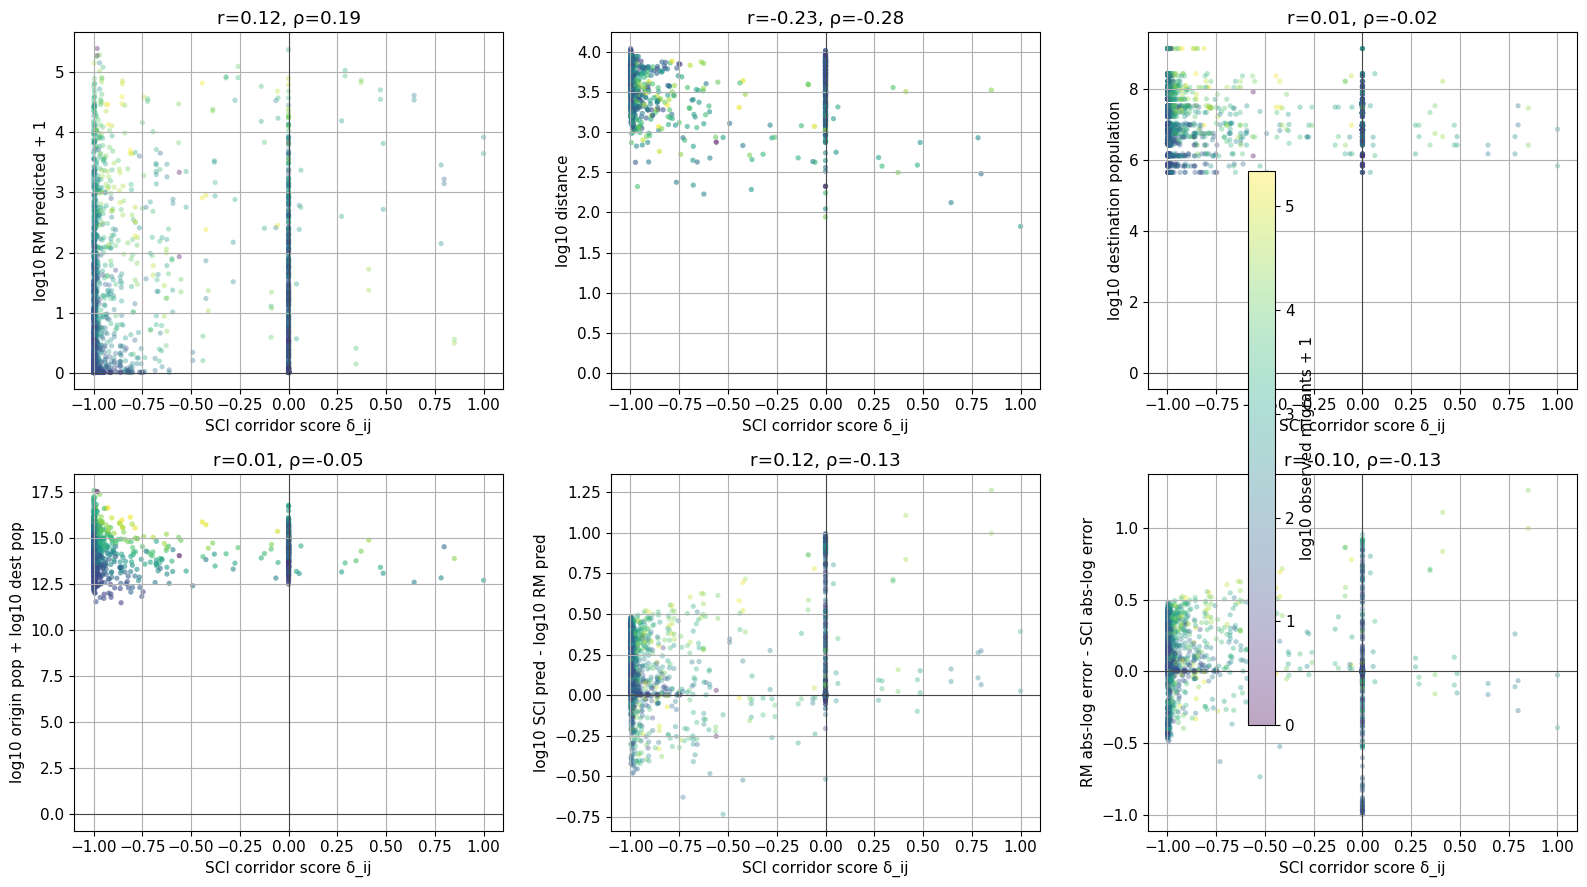

saved: outputs/combined_gdp_sci_figures/06d_sci_shift_vs_rm_prediction.png


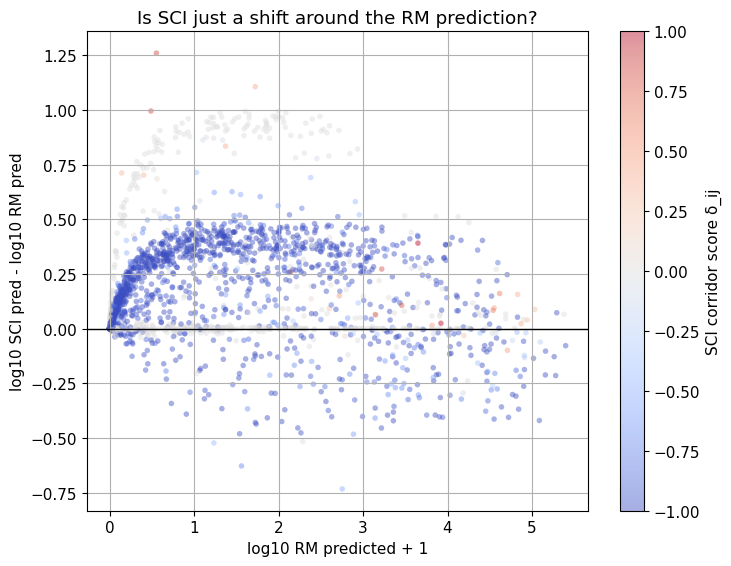

In [53]:
def build_sci_backbone_panel():
    if "sci_only" not in test_results:
        raise ValueError("sci_only must be present in test_results. Rerun test evaluation first.")

    rm = prepare_comp(test_results["rm"]["result"].comparison).copy()
    sci = prepare_comp(test_results["sci_only"]["result"].comparison).copy()
    Sigma_sci = sigma_objects_test["sci_only"]

    panel = rm[[
        "country_from", "country_to", "country_from_name", "country_to_name",
        "num_migrants", "predicted_migrants", "log_ratio", "abs_log_ratio",
    ]].rename(columns={
        "predicted_migrants": "pred_rm",
        "log_ratio": "signed_log_rm",
        "abs_log_ratio": "abs_log_rm",
    })
    panel = panel.merge(
        sci[["country_from", "country_to", "predicted_migrants", "log_ratio", "abs_log_ratio"]].rename(columns={
            "predicted_migrants": "pred_sci",
            "log_ratio": "signed_log_sci",
            "abs_log_ratio": "abs_log_sci",
        }),
        on=["country_from", "country_to"],
        how="inner",
    )

    pop = nodes_test.set_index("iso3")["population"].astype(float)
    panel["delta_sci"] = [
        Sigma_sci.loc[o, d] if o in Sigma_sci.index and d in Sigma_sci.columns else np.nan
        for o, d in zip(panel["country_from"], panel["country_to"])
    ]
    panel["distance"] = [
        D_test.loc[o, d] if o in D_test.index and d in D_test.columns else np.nan
        for o, d in zip(panel["country_from"], panel["country_to"])
    ]
    panel["origin_pop"] = [pop.get(o, np.nan) for o in panel["country_from"]]
    panel["dest_pop"] = [pop.get(d, np.nan) for d in panel["country_to"]]
    panel["origin_total_observed"] = panel["country_from"].map(panel.groupby("country_from")["num_migrants"].sum())

    panel["log_rm_pred"] = log10p(panel["pred_rm"])
    panel["log_sci_pred"] = log10p(panel["pred_sci"])
    panel["model_shift_sci_vs_rm"] = panel["log_sci_pred"] - panel["log_rm_pred"]
    panel["log_observed"] = log10p(panel["num_migrants"])
    panel["log_distance"] = np.log10(panel["distance"])
    panel["log_origin_pop"] = np.log10(panel["origin_pop"])
    panel["log_dest_pop"] = np.log10(panel["dest_pop"])
    panel["log_origin_total_observed"] = log10p(panel["origin_total_observed"])
    panel["log_pop_product"] = panel["log_origin_pop"] + panel["log_dest_pop"]
    panel["improvement_sci_vs_rm"] = panel["abs_log_rm"] - panel["abs_log_sci"]
    return panel


sci_backbone_panel = build_sci_backbone_panel()

corr_targets = {
    "log RM prediction": "log_rm_pred",
    "log distance": "log_distance",
    "log destination population": "log_dest_pop",
    "log origin population": "log_origin_pop",
    "log origin observed total": "log_origin_total_observed",
    "log origin*destination pop": "log_pop_product",
    "SCI prediction shift vs RM": "model_shift_sci_vs_rm",
    "SCI improvement vs RM": "improvement_sci_vs_rm",
    "RM signed error": "signed_log_rm",
}

corr_rows = []
for label, col in corr_targets.items():
    tmp = sci_backbone_panel[["delta_sci", col]].replace([np.inf, -np.inf], np.nan).dropna()
    corr_rows.append({
        "x": "delta_sci",
        "y": label,
        "pearson": tmp["delta_sci"].corr(tmp[col], method="pearson"),
        "spearman": tmp["delta_sci"].corr(tmp[col], method="spearman"),
        "n": len(tmp),
    })

sci_backbone_corr = pd.DataFrame(corr_rows).sort_values("spearman", key=lambda s: s.abs(), ascending=False)
display(sci_backbone_corr)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
plot_specs = [
    ("log_rm_pred", "log10 RM predicted + 1"),
    ("log_distance", "log10 distance"),
    ("log_dest_pop", "log10 destination population"),
    ("log_pop_product", "log10 origin pop + log10 dest pop"),
    ("model_shift_sci_vs_rm", "log10 SCI pred - log10 RM pred"),
    ("improvement_sci_vs_rm", "RM abs-log error - SCI abs-log error"),
]
for ax, (col, ylabel) in zip(axes.flat, plot_specs):
    tmp = sci_backbone_panel[["delta_sci", col, "log_observed"]].replace([np.inf, -np.inf], np.nan).dropna()
    sc = ax.scatter(
        tmp["delta_sci"],
        tmp[col],
        c=tmp["log_observed"],
        cmap="viridis",
        s=14,
        alpha=0.35,
        edgecolors="none",
    )
    ax.axhline(0, color="black", linewidth=0.8, alpha=0.6)
    ax.axvline(0, color="black", linewidth=0.8, alpha=0.6)
    ax.set_xlabel("SCI corridor score δ_ij")
    ax.set_ylabel(ylabel)
    pearson = tmp["delta_sci"].corr(tmp[col], method="pearson")
    spearman = tmp["delta_sci"].corr(tmp[col], method="spearman")
    ax.set_title(f"r={pearson:.2f}, ρ={spearman:.2f}")
fig.colorbar(sc, ax=axes.ravel().tolist(), shrink=0.8, label="log10 observed migrants + 1")
plt.tight_layout()
savefig("06c_sci_alignment_with_rm_backbone")
plt.show()

fig, ax = plt.subplots(figsize=(7.5, 5.8))
tmp = sci_backbone_panel[["log_rm_pred", "model_shift_sci_vs_rm", "delta_sci"]].replace([np.inf, -np.inf], np.nan).dropna()
sc = ax.scatter(
    tmp["log_rm_pred"],
    tmp["model_shift_sci_vs_rm"],
    c=tmp["delta_sci"],
    cmap="coolwarm",
    s=16,
    alpha=0.45,
    edgecolors="none",
)
ax.axhline(0, color="black", linewidth=1)
ax.set_xlabel("log10 RM predicted + 1")
ax.set_ylabel("log10 SCI pred - log10 RM pred")
ax.set_title("Is SCI just a shift around the RM prediction?")
fig.colorbar(sc, ax=ax, label="SCI corridor score δ_ij")
plt.tight_layout()
savefig("06d_sci_shift_vs_rm_prediction")
plt.show()


### SCI Normalization Stress Test

Here we isolate the normalization question. We rebuild the SCI-only Sigma matrix three ways and run each one at the same `sigma` used by the selected SCI-only model. This shows whether the parallel-to-RM behavior comes from the current min-max normalization or from the model structure itself.



Using fixed sigma=5 for all SCI normalization variants
SCI normalization test | minmax
SCI normalization test | log_rank
SCI normalization test | row_log_zscore


,transform,label,sigma,Sigma_min,Sigma_p01,Sigma_median,Sigma_p99,Sigma_max,Sigma_share_negative,Sigma_share_zero,median_improvement_vs_RM,share_better_vs_RM,Pearson_log_observed,Pearson_log_vs_RM_pred,median_shift_vs_RM,p01_shift_vs_RM,p99_shift_vs_RM
0,minmax,"SCI min-max [-1, 1]",5.0,-1.000000,-0.999639,-0.976686,0.289661,1.000000,0.739130,0.246377,0.041637,0.698068,0.658535,0.981315,0.101614,-0.401955,0.957863
1,log_rank,"SCI log-rank [-1, 1]",5.0,-0.998077,-0.972436,0.000000,0.973718,0.999359,0.375845,0.246377,-0.001798,0.438647,0.667568,0.983560,-0.008938,-0.764220,0.464298
2,row_log_zscore,SCI origin log-zscore,5.0,-2.294652,-1.559208,0.000000,2.403183,3.269028,0.420773,0.246377,-0.025241,0.309662,0.686569,0.948336,-0.077681,-1.502143,0.831377


saved: outputs/combined_gdp_sci_figures/11_sci_normalization_sigma_distributions.png


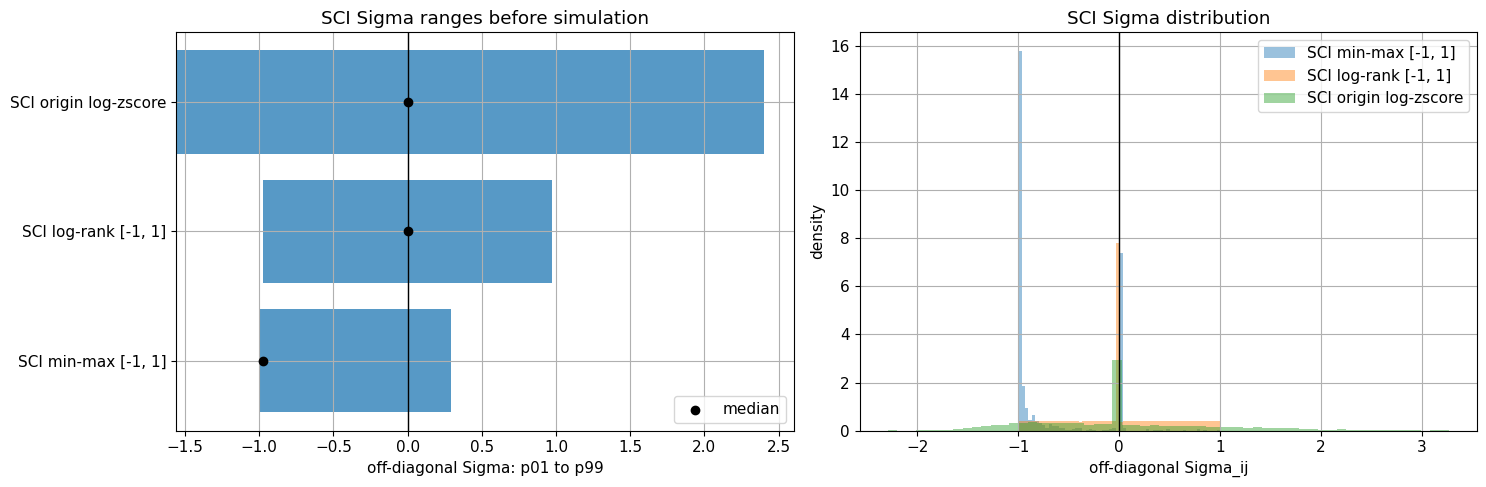

/var/folders/23/tdv39nqs7c1260lvn9d3tf1r0000gn/T/ipykernel_15403/2629073750.py:171: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


saved: outputs/combined_gdp_sci_figures/12_sci_normalization_shift_vs_rm.png


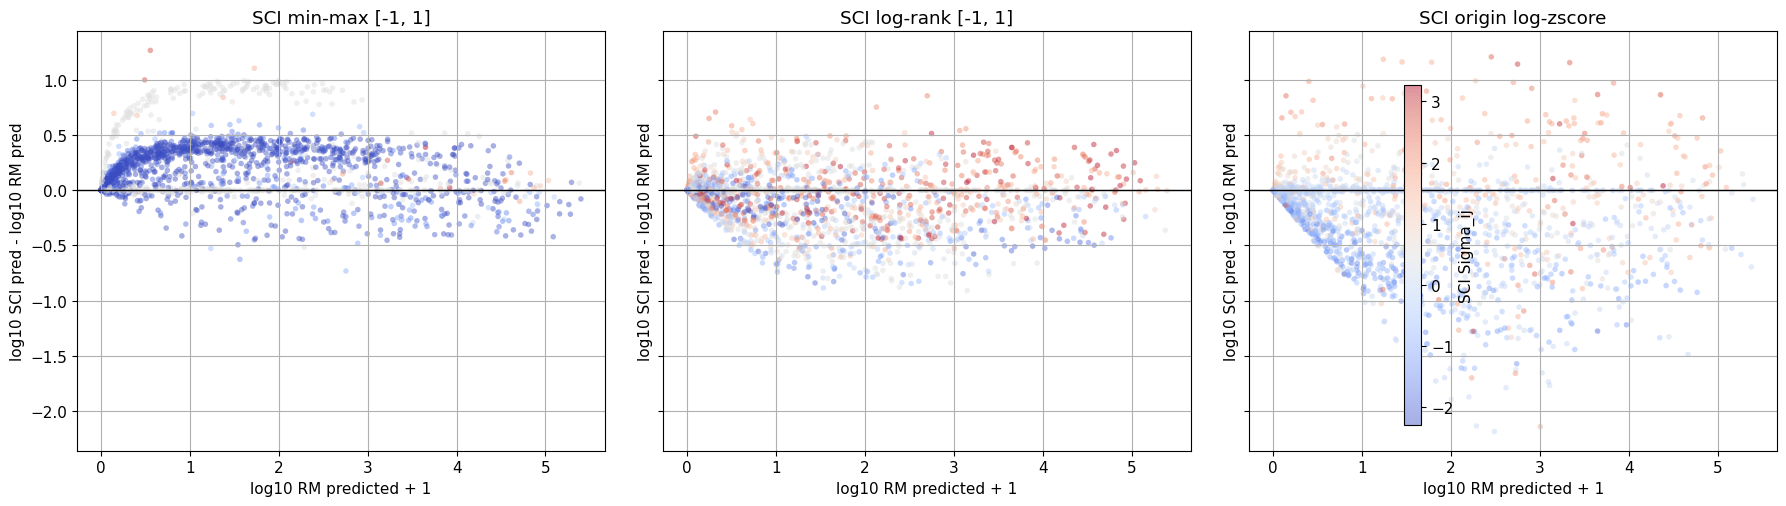

saved: outputs/combined_gdp_sci_figures/13_sci_normalization_prediction_error_panels.png


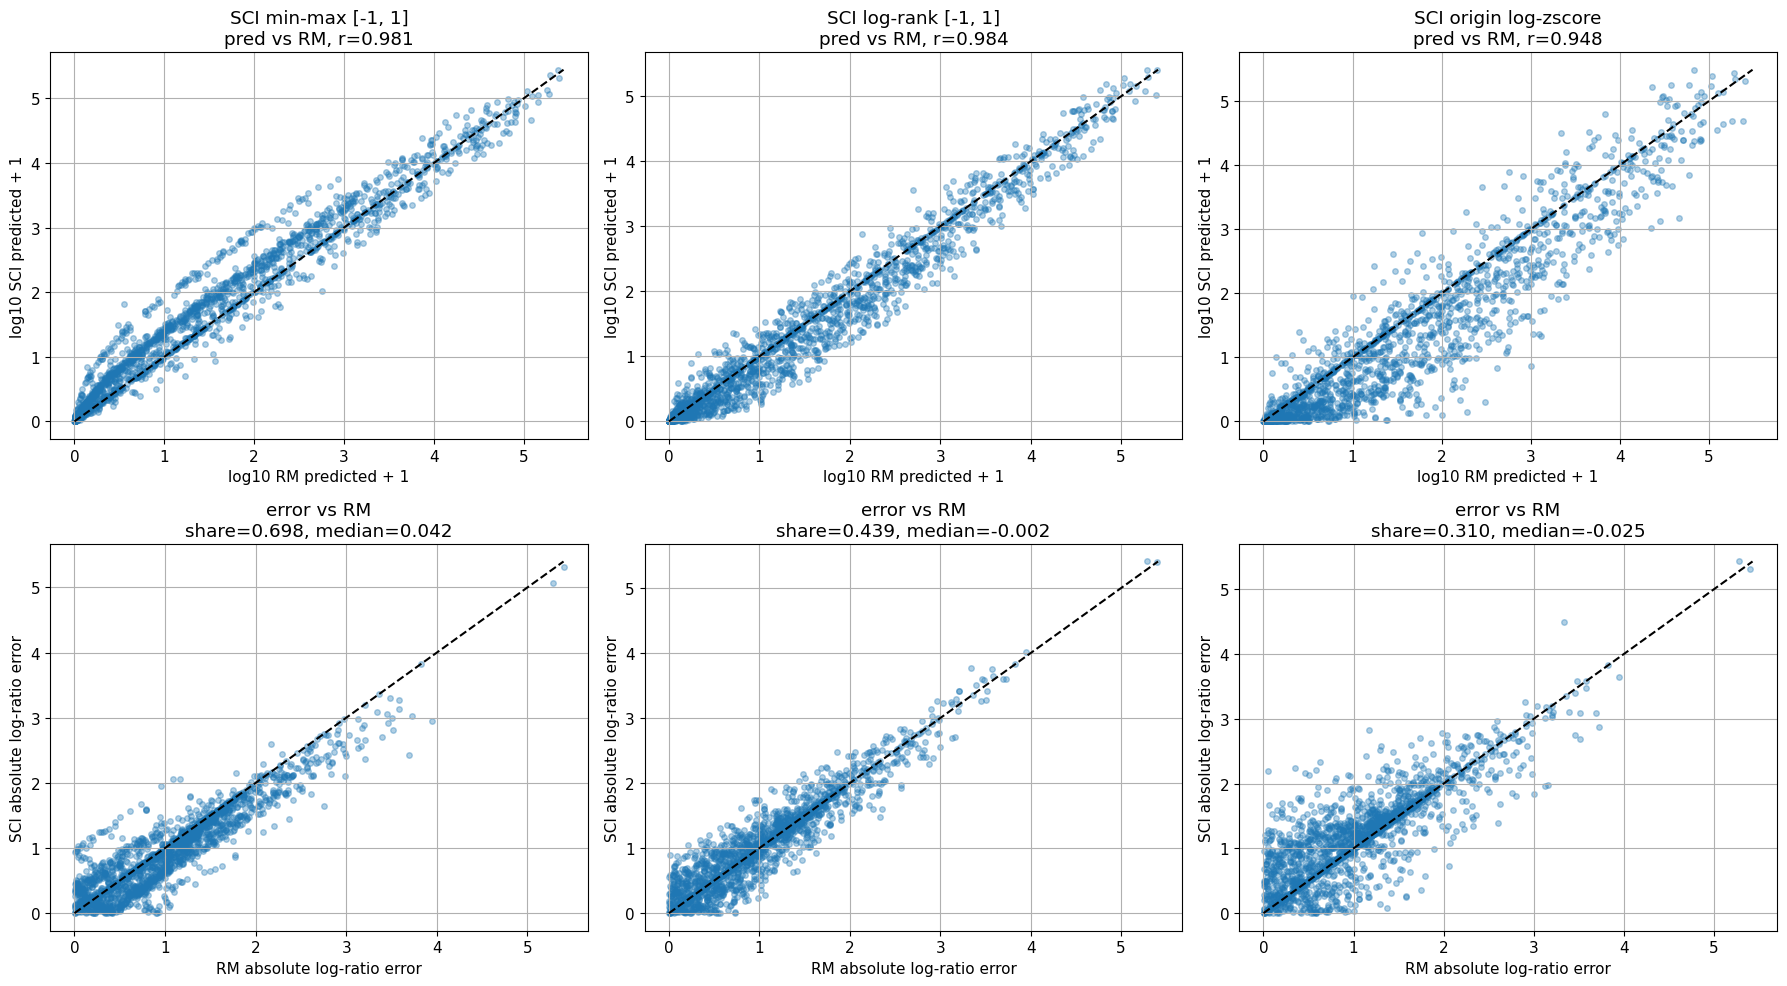

In [72]:
SCI_NORMALIZATION_SPECS = {
    "minmax": "SCI min-max [-1, 1]",
    "log_rank": "SCI log-rank [-1, 1]",
    "row_log_zscore": "SCI origin log-zscore",
}


def zscore_series(x: pd.Series) -> pd.Series:
    out = pd.Series(np.nan, index=x.index, dtype=float)
    valid = x.notna()
    if valid.sum() == 0:
        return out
    center = x.loc[valid].mean()
    scale = x.loc[valid].std(ddof=0)
    out.loc[valid] = (x.loc[valid] - center) / scale if pd.notna(scale) and scale > 0 else 0.0
    return out


def transform_sci_values(values: pd.Series, transform: str, groups: pd.Series | None = None) -> pd.Series:
    x = pd.to_numeric(values, errors="coerce")
    if transform == "minmax":
        return minmax_signed(x)
    if transform == "log_rank":
        ranks = np.log1p(x.clip(lower=0)).rank(method="average", pct=True)
        return 2.0 * ranks - 1.0
    if transform == "row_log_zscore":
        if groups is None:
            raise ValueError("row_log_zscore requires origin groups.")
        logged = np.log1p(x.clip(lower=0))
        return logged.groupby(groups).transform(zscore_series)
    raise ValueError(transform)


def build_sci_table_with_transform(nodes: pd.DataFrame, gravity_pairs: pd.DataFrame, transform: str) -> pd.DataFrame:
    code_lookup = nodes[["code", "iso3"]].dropna().drop_duplicates().copy()
    code_lookup["iso3"] = code_lookup["iso3"].astype(str).str.strip().str.upper()

    tmp = gravity_pairs[["iso3_o", "iso3_d", SCI_COL]].copy()
    tmp["iso3_o"] = tmp["iso3_o"].astype(str).str.strip().str.upper()
    tmp["iso3_d"] = tmp["iso3_d"].astype(str).str.strip().str.upper()

    mapped = tmp.merge(
        code_lookup.rename(columns={"code": "country_from", "iso3": "origin_iso3"}),
        left_on="iso3_o", right_on="origin_iso3", how="inner",
    )
    mapped = mapped.merge(
        code_lookup.rename(columns={"code": "country_to", "iso3": "destination_iso3"}),
        left_on="iso3_d", right_on="destination_iso3", how="inner",
    )
    mapped = mapped[mapped["origin_iso3"] != mapped["destination_iso3"]].copy()
    mapped["delta_sci"] = transform_sci_values(mapped[SCI_COL], transform=transform, groups=mapped["origin_iso3"])
    mapped = mapped.dropna(subset=["delta_sci"]).copy()
    return mapped[["country_from", "country_to", "origin_iso3", "destination_iso3", SCI_COL, "delta_sci"]].drop_duplicates(["origin_iso3", "destination_iso3"])


def build_sci_delta_with_transform(nodes: pd.DataFrame, gravity_pairs: pd.DataFrame, transform: str) -> pd.DataFrame:
    codes = nodes["iso3"].astype(str).str.strip().str.upper().tolist()
    delta = pd.DataFrame(0.0, index=codes, columns=codes)
    table = build_sci_table_with_transform(nodes, gravity_pairs, transform=transform)
    for row in table.itertuples(index=False):
        if row.origin_iso3 in delta.index and row.destination_iso3 in delta.columns:
            delta.loc[row.origin_iso3, row.destination_iso3] = float(row.delta_sci)
    arr = delta.to_numpy(dtype=float, copy=True)
    np.fill_diagonal(arr, 0.0)
    return pd.DataFrame(arr, index=codes, columns=codes)


def offdiag_values(Sigma: pd.DataFrame) -> np.ndarray:
    mask = ~np.eye(Sigma.shape[0], dtype=bool)
    return Sigma.to_numpy(dtype=float)[mask]


sci_sigma_for_test = float(best_by_model.loc[best_by_model["model"] == "sci_only", "sigma"].iloc[0]) if "best_by_model" in globals() and (best_by_model["model"] == "sci_only").any() else float(test_results["sci_only"]["sigma"])
print(f"Using fixed sigma={sci_sigma_for_test:g} for all SCI normalization variants")

sci_norm_sigmas = {}
sci_norm_results = {}
sci_norm_routes = {}
sci_norm_rows = []
rm_comp = test_results["rm"]["result"].comparison

for transform, label in SCI_NORMALIZATION_SPECS.items():
    print(f"SCI normalization test | {transform}")
    if transform == "minmax" and "sci_only" in sigma_objects_test:
        Sigma = sigma_objects_test["sci_only"]
    else:
        Sigma = build_sci_delta_with_transform(nodes_test, gravity_pairs, transform=transform)
    sci_norm_sigmas[transform] = Sigma

    if transform == "minmax" and "sci_only" in test_results and float(test_results["sci_only"]["sigma"]) == sci_sigma_for_test:
        result = test_results["sci_only"]["result"]
    else:
        result = run_ferm(nodes_test, flows_test, D_test, Sigma, sigma=sci_sigma_for_test, num_particles=NUM_PARTICLES)
    sci_norm_results[transform] = result

    route_key = f"sci_norm_{transform}"
    route_df = compare_to_rm(rm_comp, result.comparison, route_key)
    sci_norm_routes[transform] = route_df

    vals = offdiag_values(Sigma)
    comp = prepare_comp(result.comparison)
    obs_log = log10p(comp["num_migrants"])
    pred_log = log10p(comp["predicted_migrants"])
    rm_prepared = prepare_comp(rm_comp)
    rm_pred_log = log10p(rm_prepared["predicted_migrants"])
    shift_vs_rm = np.asarray(pred_log, dtype=float) - np.asarray(rm_pred_log, dtype=float)

    sci_norm_rows.append({
        "transform": transform,
        "label": label,
        "sigma": sci_sigma_for_test,
        "Sigma_min": np.nanmin(vals),
        "Sigma_p01": np.nanquantile(vals, 0.01),
        "Sigma_median": np.nanmedian(vals),
        "Sigma_p99": np.nanquantile(vals, 0.99),
        "Sigma_max": np.nanmax(vals),
        "Sigma_share_negative": np.mean(vals < 0),
        "Sigma_share_zero": np.mean(np.isclose(vals, 0.0)),
        "median_improvement_vs_RM": route_df["improvement_abs_log"].median(),
        "share_better_vs_RM": (route_df["improvement_abs_log"] > 0).mean(),
        "Pearson_log_observed": pd.Series(obs_log).corr(pd.Series(pred_log), method="pearson"),
        "Pearson_log_vs_RM_pred": pd.Series(rm_pred_log).corr(pd.Series(pred_log), method="pearson"),
        "median_shift_vs_RM": np.nanmedian(shift_vs_rm),
        "p01_shift_vs_RM": np.nanquantile(shift_vs_rm, 0.01),
        "p99_shift_vs_RM": np.nanquantile(shift_vs_rm, 0.99),
    })

sci_norm_summary = pd.DataFrame(sci_norm_rows)
display(sci_norm_summary)

# 1. Sigma distributions.
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
plot_df = sci_norm_summary.sort_values("Sigma_median")
axes[0].barh(plot_df["label"], plot_df["Sigma_p99"] - plot_df["Sigma_p01"], left=plot_df["Sigma_p01"], alpha=0.75)
axes[0].scatter(plot_df["Sigma_median"], plot_df["label"], color="black", zorder=3, label="median")
axes[0].axvline(0, color="black", linewidth=1)
axes[0].set_title("SCI Sigma ranges before simulation")
axes[0].set_xlabel("off-diagonal Sigma: p01 to p99")
axes[0].legend()

for transform, label in SCI_NORMALIZATION_SPECS.items():
    vals = offdiag_values(sci_norm_sigmas[transform])
    axes[1].hist(vals, bins=60, alpha=0.45, density=True, label=label)
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_title("SCI Sigma distribution")
axes[1].set_xlabel("off-diagonal Sigma_ij")
axes[1].set_ylabel("density")
axes[1].legend()
plt.tight_layout()
savefig("11_sci_normalization_sigma_distributions")
plt.show()

# 2. Model shift against RM.
fig, axes = plt.subplots(1, 3, figsize=(18, 5.2), sharey=True)
rm_prepared = prepare_comp(rm_comp)
rm_pred_log = log10p(rm_prepared["predicted_migrants"])
for ax, (transform, label) in zip(axes, SCI_NORMALIZATION_SPECS.items()):
    comp = prepare_comp(sci_norm_results[transform].comparison)
    pred_log = log10p(comp["predicted_migrants"])
    Sigma = sci_norm_sigmas[transform]
    delta = np.array([
        Sigma.loc[o, d] if o in Sigma.index and d in Sigma.columns else np.nan
        for o, d in zip(comp["country_from"], comp["country_to"])
    ], dtype=float)
    sc = ax.scatter(rm_pred_log, pred_log - rm_pred_log, c=delta, cmap="coolwarm", s=16, alpha=0.45, edgecolors="none")
    ax.axhline(0, color="black", linewidth=1)
    ax.set_title(label)
    ax.set_xlabel("log10 RM predicted + 1")
    ax.set_ylabel("log10 SCI pred - log10 RM pred")
fig.colorbar(sc, ax=axes.ravel().tolist(), shrink=0.85, label="SCI Sigma_ij")
plt.tight_layout()
savefig("12_sci_normalization_shift_vs_rm")
plt.show()

# 3. Prediction-vs-RM and error-vs-RM panels.
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for col_idx, (transform, label) in enumerate(SCI_NORMALIZATION_SPECS.items()):
    comp = prepare_comp(sci_norm_results[transform].comparison)
    pred_log = log10p(comp["predicted_migrants"])
    r_pred = pd.Series(rm_pred_log).corr(pd.Series(pred_log), method="pearson")
    ax = axes[0, col_idx]
    ax.scatter(rm_pred_log, pred_log, alpha=0.35, s=16)
    lim = max(np.nanmax(rm_pred_log), np.nanmax(pred_log))
    ax.plot([0, lim], [0, lim], linestyle="--", color="black")
    ax.set_title(f"{label}\npred vs RM, r={r_pred:.3f}")
    ax.set_xlabel("log10 RM predicted + 1")
    ax.set_ylabel("log10 SCI predicted + 1")

    r = sci_norm_routes[transform]
    ycol = f"abs_log_sci_norm_{transform}"
    share = (r["improvement_abs_log"] > 0).mean()
    median = r["improvement_abs_log"].median()
    ax = axes[1, col_idx]
    ax.scatter(r["abs_log_rm"], r[ycol], alpha=0.35, s=16)
    lim = max(r["abs_log_rm"].max(), r[ycol].max())
    ax.plot([0, lim], [0, lim], linestyle="--", color="black")
    ax.set_title(f"error vs RM\nshare={share:.3f}, median={median:.3f}")
    ax.set_xlabel("RM absolute log-ratio error")
    ax.set_ylabel("SCI absolute log-ratio error")
plt.tight_layout()
savefig("13_sci_normalization_prediction_error_panels")
plt.show()


saved: outputs/combined_gdp_sci_figures/07_best_combined_vs_gdp_route_map.png


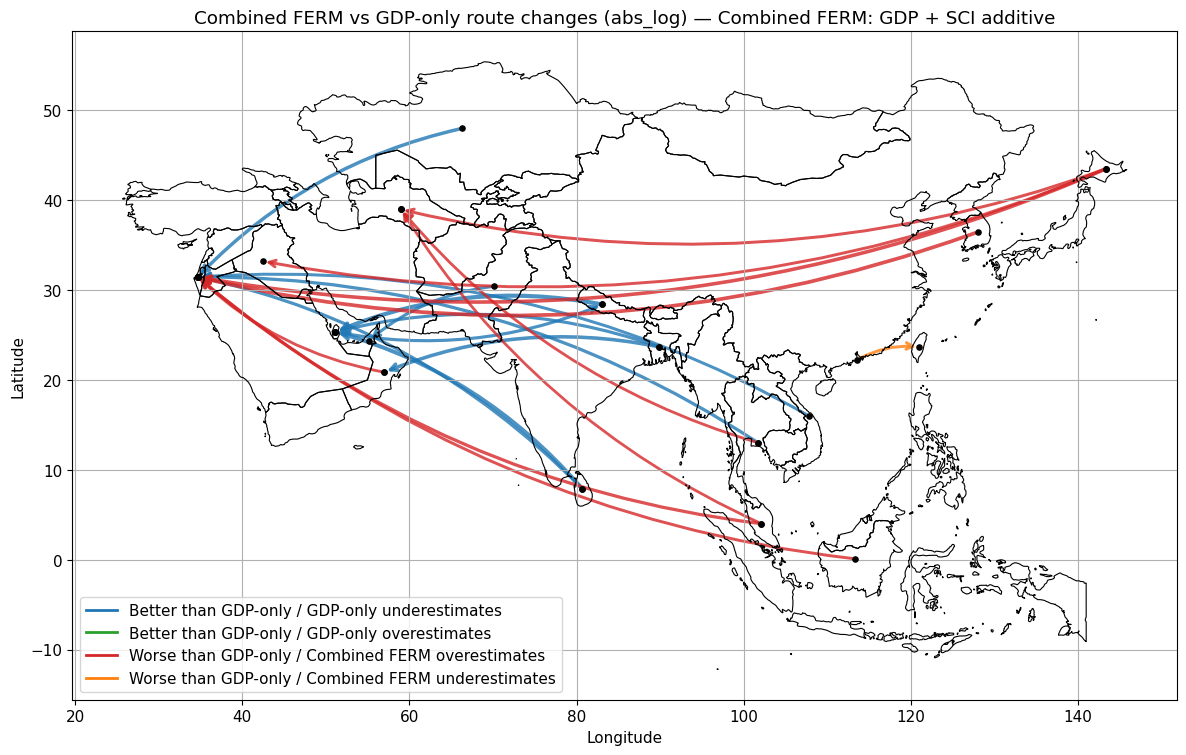

,country_from,country_to,country_from_name,country_to_name,total_migrants,predicted_rm,predicted_ferm,residual_rm,residual_ferm,improvement_abs_error,improvement_abs_log,route_change,route_class
0,NPL,QAT,NPL,QAT,17567.0,10.732994,404.512558,-17556.267006,-17162.487442,393.779563,1.538595,Improved,Better / GDP-only underestimates
1,LKA,QAT,LKA,QAT,7424.0,3.232219,119.316208,-7420.767781,-7304.683792,116.083989,1.453756,Improved,Better / GDP-only underestimates
2,BGD,OMN,BGD,OMN,30082.0,150.801163,2901.152599,-29931.198837,-27180.847401,2750.351436,1.281445,Improved,Better / GDP-only underestimates
3,KAZ,ISR,KAZ,ISR,176.0,4.706887,99.732171,-171.293113,-76.267829,95.025284,1.246769,Improved,Better / GDP-only underestimates
4,THA,ISR,THA,ISR,4252.0,91.336730,1305.981358,-4160.663270,-2946.018642,1214.644627,1.150895,Improved,Better / GDP-only underestimates
5,LKA,ISR,LKA,ISR,166.0,5.464187,86.107407,-160.535813,-79.892593,80.643220,1.129541,Improved,Better / GDP-only underestimates
6,BGD,QAT,BGD,QAT,20855.0,92.773663,1207.716689,-20762.226337,-19647.283311,1114.943025,1.110244,Improved,Better / GDP-only underestimates
7,QAT,NPL,QAT,NPL,27175.0,7.175091,103.729397,-27167.824909,-27071.270603,96.554306,1.107576,Improved,Better / GDP-only underestimates
8,PAK,ARE,PAK,ARE,115485.0,1333.705454,16934.162576,-114151.294546,-98550.837424,15600.457121,1.103404,Improved,Better / GDP-only underestimates
9,VNM,ISR,VNM,ISR,1048.0,78.082917,893.821102,-969.917083,-154.178898,815.738185,1.053654,Improved,Better / GDP-only underestimates


In [75]:
def plot_best_combined_vs_gdp_route_map(top_n=10, metric="abs_log"):
    combined_keys = [k for k in route_results if MODEL_SPECS[k]["family"] == "combined"]
    if not combined_keys or "gdp_only" not in test_results:
        print("Need combined models and gdp_only in test_results.")
        return None

    best_combined_key = (
        test_summary[test_summary["model"].isin(combined_keys)]
        .sort_values(["median_improvement_abs_log", "share_better_abs_log"], ascending=[False, False])
        .iloc[0]["model"]
    )
    label = f"{MODEL_SPECS[best_combined_key]['label']} vs GDP-only"

    plotted = plot_ferm_vs_rm_route_change(
        plotting_comp(test_results["gdp_only"]["result"].comparison),
        plotting_comp(test_results[best_combined_key]["result"].comparison),
        country_geo=country_geo,
        continent_gdf=continent_gdf,
        top_n_improve=top_n,
        top_n_worsen=top_n,
        metric=metric,
        label=label,
        benchmark_label="GDP-only",
        model_label="Combined FERM",
        min_linewidth=0.35,
        max_linewidth=3,
        show=False,
    )
    ax = plt.gca()
    ax.set_title(f"Combined FERM vs GDP-only route changes ({metric}) — {MODEL_SPECS[best_combined_key]['label']}")
    savefig("07_best_combined_vs_gdp_route_map")
    plt.show()
    plt.close()
    display(plotted)
    return 


plot_best_combined_vs_gdp_route_map()


### Why Are the Map Routes Mostly Blue and Red?

The map color is not just “better/worse.” It also encodes the **direction** of the signed prediction error. This diagnostic separates those two dimensions: whether combined improves over GDP-only, and whether the relevant model under- or over-predicts.



Best combined model: Combined FERM: GDP + SCI additive
Counts


,all routes,mapped top routes
map_class,,
Better than GDP-only / GDP underestimates,1147,10
Better than GDP-only / GDP overestimates,218,0
Worse than GDP-only / Combined overestimates,389,9
Worse than GDP-only / Combined underestimates,316,1


Shares


map_class,Better than GDP-only / GDP underestimates,Better than GDP-only / GDP overestimates,Worse than GDP-only / Combined overestimates,Worse than GDP-only / Combined underestimates
all routes,0.554106,0.105314,0.187923,0.152657
mapped top routes,0.500000,0.000000,0.450000,0.050000


saved: outputs/combined_gdp_sci_figures/08b_combined_vs_gdp_color_criterion.png


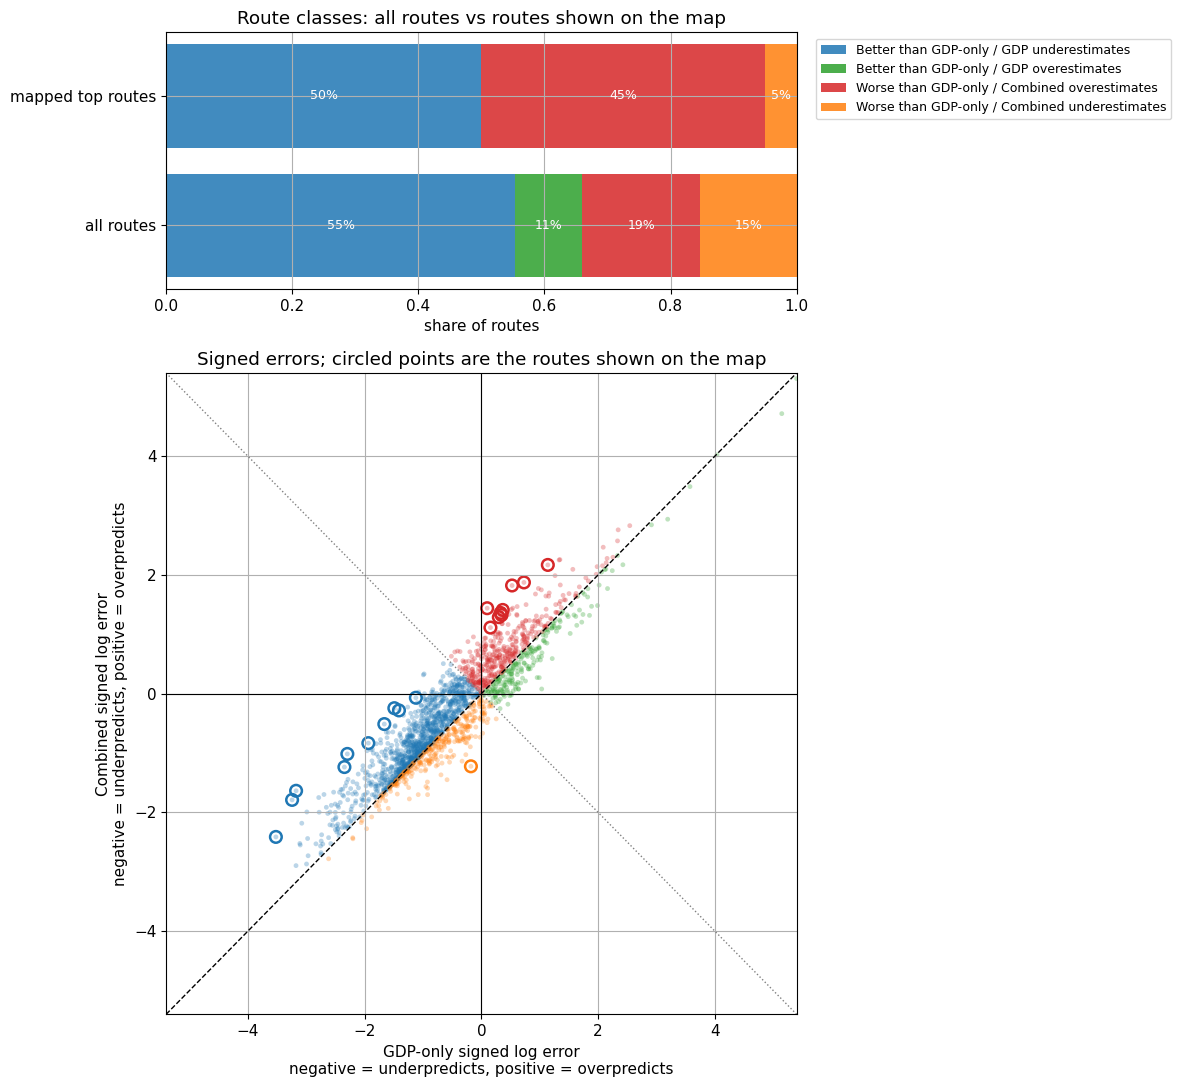

Mapped top-route class shares


,map_class,share
0,Better than GDP-only / GDP underestimates,0.50
1,Better than GDP-only / GDP overestimates,0.00
2,Worse than GDP-only / Combined overestimates,0.45
3,Worse than GDP-only / Combined underestimates,0.05


In [76]:
def combined_vs_gdp_signed_error_panel(top_n=10):
    combined_keys = [k for k in route_results if MODEL_SPECS[k]["family"] == "combined"]
    if not combined_keys or "gdp_only" not in test_results:
        raise ValueError("Need gdp_only and at least one combined model in test_results.")

    best_combined_key = (
        test_summary[test_summary["model"].isin(combined_keys)]
        .sort_values(["median_improvement_abs_log", "share_better_abs_log"], ascending=[False, False])
        .iloc[0]["model"]
    )

    gdp = prepare_comp(test_results["gdp_only"]["result"].comparison).copy()
    combo = prepare_comp(test_results[best_combined_key]["result"].comparison).copy()

    gdp = gdp[["country_from", "country_to", "country_from_name", "country_to_name", "num_migrants", "predicted_migrants", "log_ratio", "abs_log_ratio"]].rename(columns={
        "predicted_migrants": "pred_gdp",
        "log_ratio": "signed_log_gdp",
        "abs_log_ratio": "abs_log_gdp",
    })
    combo = combo[["country_from", "country_to", "predicted_migrants", "log_ratio", "abs_log_ratio"]].rename(columns={
        "predicted_migrants": "pred_combined",
        "log_ratio": "signed_log_combined",
        "abs_log_ratio": "abs_log_combined",
    })
    panel = gdp.merge(combo, on=["country_from", "country_to"], how="inner")
    panel["improvement_vs_gdp"] = panel["abs_log_gdp"] - panel["abs_log_combined"]
    panel["combined_better"] = panel["improvement_vs_gdp"] > 0

    panel["gdp_direction"] = np.select(
        [panel["signed_log_gdp"] < 0, panel["signed_log_gdp"] > 0],
        ["GDP underestimates", "GDP overestimates"],
        default="GDP exact",
    )
    panel["combined_direction"] = np.select(
        [panel["signed_log_combined"] < 0, panel["signed_log_combined"] > 0],
        ["Combined underestimates", "Combined overestimates"],
        default="Combined exact",
    )
    panel["map_class"] = np.where(
        panel["combined_better"],
        "Better than GDP-only / " + panel["gdp_direction"],
        "Worse than GDP-only / " + panel["combined_direction"],
    )

    top_improved = panel[panel["improvement_vs_gdp"] > 0].nlargest(top_n, "improvement_vs_gdp")
    top_worsened = panel[panel["improvement_vs_gdp"] < 0].nsmallest(top_n, "improvement_vs_gdp")
    map_subset = pd.concat([top_improved, top_worsened], ignore_index=True)
    return panel, map_subset, best_combined_key


signed_error_panel, signed_error_map_subset, best_combined_key = combined_vs_gdp_signed_error_panel(top_n=10)
print(f"Best combined model: {MODEL_SPECS[best_combined_key]['label']}")

class_order = [
    "Better than GDP-only / GDP underestimates",
    "Better than GDP-only / GDP overestimates",
    "Worse than GDP-only / Combined overestimates",
    "Worse than GDP-only / Combined underestimates",
]
class_colors = {
    "Better than GDP-only / GDP underestimates": "tab:blue",
    "Better than GDP-only / GDP overestimates": "tab:green",
    "Worse than GDP-only / Combined overestimates": "tab:red",
    "Worse than GDP-only / Combined underestimates": "tab:orange",
}

all_counts = signed_error_panel["map_class"].value_counts().reindex(class_order, fill_value=0)
map_counts = signed_error_map_subset["map_class"].value_counts().reindex(class_order, fill_value=0)
count_df = pd.DataFrame({"all routes": all_counts, "mapped top routes": map_counts})
share_df = count_df.div(count_df.sum(axis=0), axis=1).T

print("Counts")
display(count_df)
print("Shares")
display(share_df)

fig, axes = plt.subplots(2, 1, figsize=(12, 11), gridspec_kw={"height_ratios": [0.8, 2.0]})

# Share plot: colors now mean the same thing as the map colors.
bottom = np.zeros(len(share_df), dtype=float)
y = np.arange(len(share_df))
for cls in class_order:
    vals = share_df[cls].to_numpy(dtype=float)
    axes[0].barh(y, vals, left=bottom, color=class_colors[cls], alpha=0.85, label=cls)
    for yi, left, val in zip(y, bottom, vals):
        if val >= 0.04:
            axes[0].text(left + val / 2, yi, f"{val:.0%}", ha="center", va="center", fontsize=9, color="white")
    bottom += vals
axes[0].set_yticks(y)
axes[0].set_yticklabels(share_df.index)
axes[0].set_xlim(0, 1)
axes[0].set_xlabel("share of routes")
axes[0].set_title("Route classes: all routes vs routes shown on the map")
axes[0].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)

# Signed-error scatter: same colors as the share plot and map.
for cls in class_order:
    sub = signed_error_panel[signed_error_panel["map_class"] == cls]
    axes[1].scatter(
        sub["signed_log_gdp"],
        sub["signed_log_combined"],
        s=12,
        alpha=0.30,
        color=class_colors[cls],
        label=cls,
        edgecolors="none",
    )

# Highlight the exact routes that were mapped.
for cls in class_order:
    sub = signed_error_map_subset[signed_error_map_subset["map_class"] == cls]
    axes[1].scatter(
        sub["signed_log_gdp"],
        sub["signed_log_combined"],
        s=70,
        facecolors="none",
        edgecolors=class_colors[cls],
        linewidths=1.8,
    )

lim = np.nanmax(np.abs(signed_error_panel[["signed_log_gdp", "signed_log_combined"]].to_numpy(dtype=float)))
axes[1].plot([-lim, lim], [-lim, lim], color="black", linestyle="--", linewidth=1, label="same signed error")
axes[1].plot([-lim, lim], [lim, -lim], color="gray", linestyle=":", linewidth=1, label="same abs error")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_xlim(-lim, lim)
axes[1].set_ylim(-lim, lim)
axes[1].set_xlabel("GDP-only signed log error" + "\n" + "negative = underpredicts, positive = overpredicts")
axes[1].set_ylabel("Combined signed log error" + "\n" + "negative = underpredicts, positive = overpredicts")
axes[1].set_title("Signed errors; circled points are the routes shown on the map")

plt.tight_layout()
savefig("08b_combined_vs_gdp_color_criterion")
plt.show()

print("Mapped top-route class shares")
display((map_counts / max(map_counts.sum(), 1)).rename("share").reset_index().rename(columns={"index": "map_class"}))


,model,label,bin_type,bin,bin_order,median_improvement_abs_log,mean_improvement_abs_log,count
0,combined_additive,Combined FERM: GDP + SCI additive,observed_bin,"(-0.001, 1.38]",0,0.042934,0.072097,551.0
1,combined_additive,Combined FERM: GDP + SCI additive,observed_bin,"(1.38, 1.778]",1,0.136510,0.157332,486.0
2,combined_additive,Combined FERM: GDP + SCI additive,observed_bin,"(1.778, 2.75]",2,0.232054,0.275011,515.0
3,combined_additive,Combined FERM: GDP + SCI additive,observed_bin,"(2.75, 5.343]",3,0.263934,0.345754,518.0
4,combined_additive,Combined FERM: GDP + SCI additive,distance_bin,"(66.999, 2109.0]",0,0.060628,0.064261,520.0
5,combined_additive,Combined FERM: GDP + SCI additive,distance_bin,"(2109.0, 3807.0]",1,0.093753,0.194710,516.0
6,combined_additive,Combined FERM: GDP + SCI additive,distance_bin,"(3807.0, 6021.75]",2,0.133984,0.276980,516.0
7,combined_additive,Combined FERM: GDP + SCI additive,distance_bin,"(6021.75, 11185.0]",3,0.221263,0.309097,518.0
8,combined_additive_rescaled,"Combined FERM: GDP + SCI additive, offdiag res...",observed_bin,"(-0.001, 1.38]",0,0.011277,0.041341,551.0
9,combined_additive_rescaled,"Combined FERM: GDP + SCI additive, offdiag res...",observed_bin,"(1.38, 1.778]",1,0.047866,0.082490,486.0


/var/folders/23/tdv39nqs7c1260lvn9d3tf1r0000gn/T/ipykernel_15403/4134083327.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


saved: outputs/combined_gdp_sci_figures/08_where_combined_models_work_bins.png


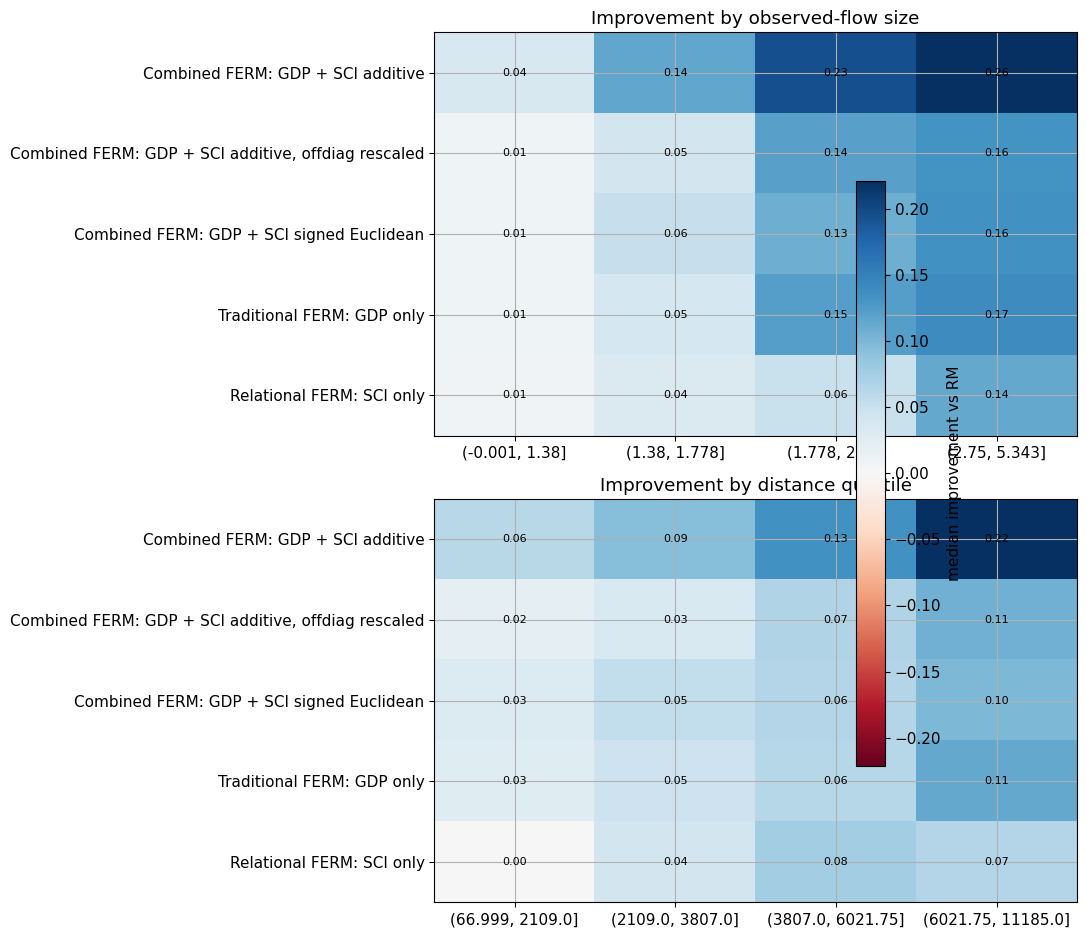

In [51]:
def attach_distance(route_df: pd.DataFrame, D: pd.DataFrame) -> pd.DataFrame:
    out = route_df.copy()
    out["distance"] = [
        D.loc[o, d] if o in D.index and d in D.columns else np.nan
        for o, d in zip(out["country_from"], out["country_to"])
    ]
    return out


binned_rows = []
for model_key, r in route_results.items():
    tmp = attach_distance(r, D_test)
    tmp["observed_bin"] = pd.qcut(log10p(tmp["num_migrants"]), q=4, duplicates="drop")
    tmp["distance_bin"] = pd.qcut(tmp["distance"], q=4, duplicates="drop")
    for bin_col in ["observed_bin", "distance_bin"]:
        grouped = tmp.groupby(bin_col, observed=True)["improvement_abs_log"].agg(["median", "mean", "count"])
        for bin_order, (idx, row) in enumerate(grouped.iterrows()):
            binned_rows.append({
                "model": model_key,
                "label": MODEL_SPECS[model_key]["label"],
                "bin_type": bin_col,
                "bin": str(idx),
                "bin_order": bin_order,
                "median_improvement_abs_log": row["median"],
                "mean_improvement_abs_log": row["mean"],
                "count": row["count"],
            })

binned_df = pd.DataFrame(binned_rows)
display(binned_df)

model_order = [MODEL_SPECS[k]["label"] for k in route_results.keys()]
fig, axes = plt.subplots(2, 1, figsize=(11, 9.5))
for ax, bin_type, title in [
    (axes[0], "observed_bin", "Improvement by observed-flow size"),
    (axes[1], "distance_bin", "Improvement by distance quartile"),
]:
    sub = binned_df[binned_df["bin_type"] == bin_type].copy()
    bin_order = sub[["bin", "bin_order"]].drop_duplicates().sort_values("bin_order")["bin"].tolist()
    row_order = [label for label in model_order if label in set(sub["label"])]
    pivot = sub.pivot(index="label", columns="bin", values="median_improvement_abs_log")
    pivot = pivot.reindex(index=row_order, columns=bin_order)
    vmax = np.nanmax(np.abs(pivot.values))
    im = ax.imshow(pivot.values, aspect="auto", cmap="RdBu", vmin=-vmax, vmax=vmax)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=0, ha="center")
    ax.set_title(title)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            val = pivot.values[i, j]
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8, label="median improvement vs RM")
plt.tight_layout()
savefig("08_where_combined_models_work_bins")
plt.show()


## 9. Where Does Each Feature Win?

This section compares three families route by route: GDP-only, SCI-only, and the best GDP+SCI combined specification. For each OD route, the winner is the model with the lowest absolute log-ratio error. The goal is to see whether the relational component helps in particular flow-size or distance regimes.



Route-winner candidates:
- GDP only: Traditional FERM: GDP only
- SCI only: Relational FERM: SCI only
- GDP + SCI: Combined FERM: GDP + SCI additive


,winner_label,routes,route_share,observed_total,median_observed,median_distance,median_margin
0,GDP + SCI,884,0.427053,3193168.0,93.0,4130.5,0.135593
1,GDP only,649,0.313527,1632848.0,43.0,3905.0,0.096009
2,SCI only,537,0.259420,1360032.0,52.0,3161.0,0.123396


saved: outputs/combined_gdp_sci_figures/09_feature_winner_distance_flow_scatter.png


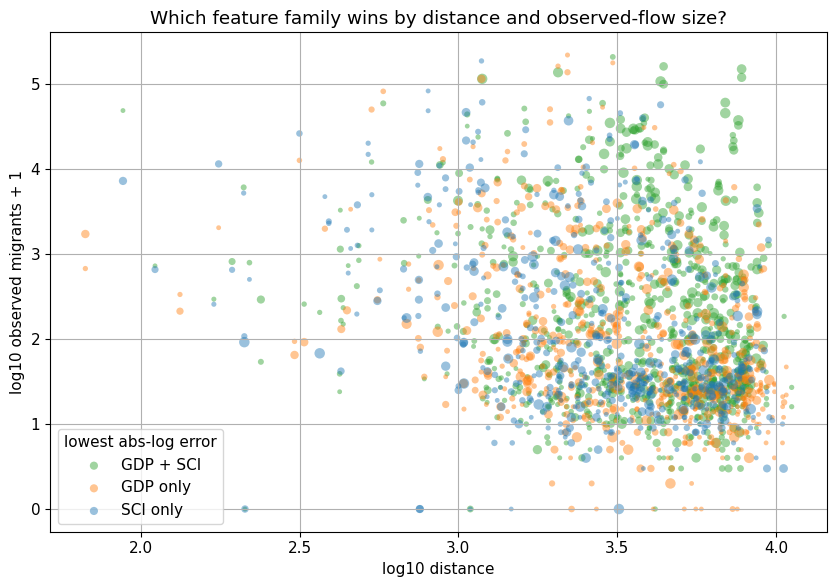

saved: outputs/combined_gdp_sci_figures/10_feature_winner_shares_by_bins.png


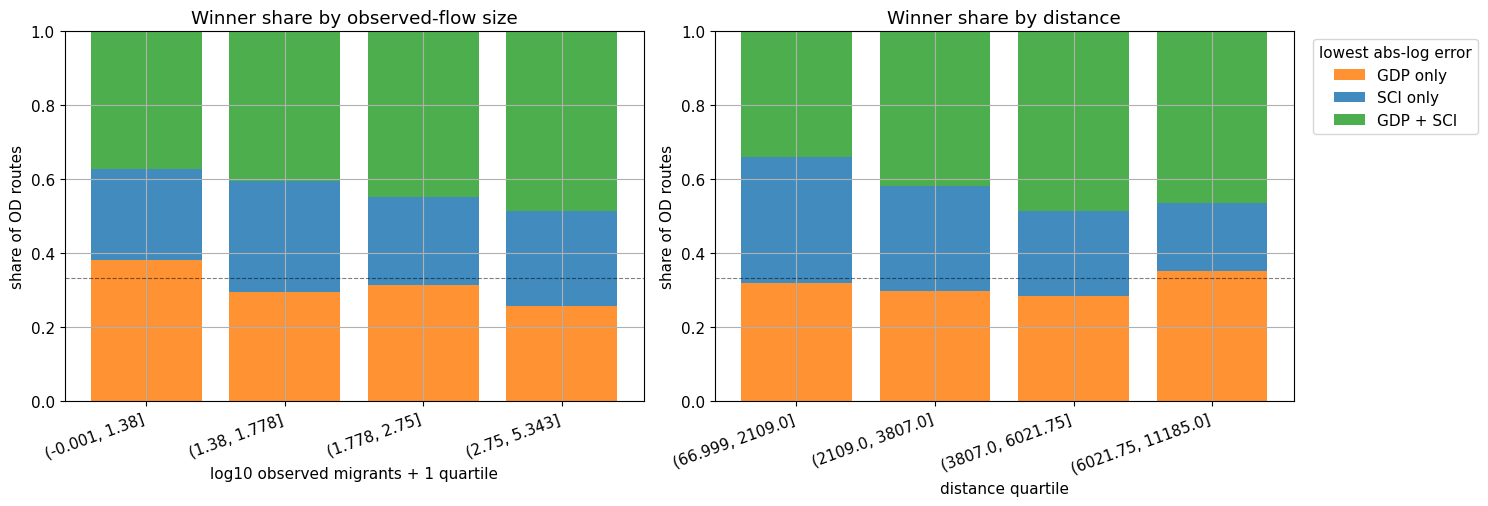

In [119]:
def build_feature_winner_panel(candidate_keys=None):
    combined_keys = [k for k in route_results if MODEL_SPECS[k]["family"] == "combined"]
    if candidate_keys is None:
        if not combined_keys:
            raise ValueError("No combined models found in route_results. Rerun test evaluation after building combined models.")
        best_combined_key = (
            test_summary[test_summary["model"].isin(combined_keys)]
            .sort_values(["median_improvement_abs_log", "share_better_abs_log"], ascending=[False, False])
            .iloc[0]["model"]
        )
        candidate_keys = [k for k in ["gdp_only", "sci_only", best_combined_key] if k in route_results]

    if len(candidate_keys) < 2:
        raise ValueError("Need at least two candidate models in route_results.")

    base_cols = ["country_from", "country_to", "country_from_name", "country_to_name", "num_migrants"]
    panel = route_results[candidate_keys[0]][base_cols].copy()

    for key in candidate_keys:
        add_cols = ["country_from", "country_to", f"abs_log_{key}", f"pred_{key}"]
        panel = panel.merge(route_results[key][add_cols], on=["country_from", "country_to"], how="inner")

    error_cols = [f"abs_log_{key}" for key in candidate_keys]
    col_to_key = {f"abs_log_{key}": key for key in candidate_keys}
    panel["winner"] = panel[error_cols].idxmin(axis=1).map(col_to_key)

    sorted_errors = np.sort(panel[error_cols].to_numpy(dtype=float), axis=1)
    panel["winner_margin"] = sorted_errors[:, 1] - sorted_errors[:, 0]
    panel["distance"] = [
        D_test.loc[o, d] if o in D_test.index and d in D_test.columns else np.nan
        for o, d in zip(panel["country_from"], panel["country_to"])
    ]
    panel["log_observed"] = log10p(panel["num_migrants"])
    panel["log_distance"] = np.log10(panel["distance"])

    short_labels = {
        "gdp_only": "GDP only",
        "sci_only": "SCI only",
    }
    for key in combined_keys:
        short_labels[key] = "GDP + SCI"
    panel["winner_label"] = panel["winner"].map(short_labels).fillna(panel["winner"])
    return panel, candidate_keys, short_labels


feature_winner_panel, feature_winner_keys, feature_winner_labels = build_feature_winner_panel()
print("Route-winner candidates:")
for key in feature_winner_keys:
    print(f"- {feature_winner_labels.get(key, key)}: {MODEL_SPECS[key]['label']}")

display(
    feature_winner_panel.groupby("winner_label")
    .agg(
        routes=("winner_label", "size"),
        route_share=("winner_label", lambda x: len(x) / len(feature_winner_panel)),
        observed_total=("num_migrants", "sum"),
        median_observed=("num_migrants", "median"),
        median_distance=("distance", "median"),
        median_margin=("winner_margin", "median"),
    )
    .sort_values("route_share", ascending=False)
    .reset_index()
)

winner_colors = {
    "GDP only": "tab:orange",
    "SCI only": "tab:blue",
    "GDP + SCI": "tab:green",
}

fig, ax = plt.subplots(figsize=(8.5, 6))
for label, sub in feature_winner_panel.groupby("winner_label"):
    ax.scatter(
        sub["log_distance"],
        sub["log_observed"],
        s=12 + 45 * np.clip(sub["winner_margin"] / max(feature_winner_panel["winner_margin"].quantile(0.95), 1e-9), 0, 1),
        alpha=0.45,
        color=winner_colors.get(label),
        label=label,
        edgecolors="none",
    )
ax.set_xlabel("log10 distance")
ax.set_ylabel("log10 observed migrants + 1")
ax.set_title("Which feature family wins by distance and observed-flow size?")
ax.legend(title="lowest abs-log error")
plt.tight_layout()
savefig("09_feature_winner_distance_flow_scatter")
plt.show()

feature_winner_panel["observed_bin"] = pd.qcut(feature_winner_panel["log_observed"], q=4, duplicates="drop")
feature_winner_panel["distance_bin"] = pd.qcut(feature_winner_panel["distance"], q=4, duplicates="drop")

fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))
for ax, bin_col, title, xlabel in [
    (axes[0], "observed_bin", "Winner share by observed-flow size", "log10 observed migrants + 1 quartile"),
    (axes[1], "distance_bin", "Winner share by distance", "distance quartile"),
]:
    tab = pd.crosstab(feature_winner_panel[bin_col], feature_winner_panel["winner_label"], normalize="index")
    tab = tab.reindex(feature_winner_panel[bin_col].cat.categories)
    for label in ["GDP only", "SCI only", "GDP + SCI"]:
        if label not in tab.columns:
            tab[label] = 0.0
    tab = tab[["GDP only", "SCI only", "GDP + SCI"]]

    bottom = np.zeros(len(tab), dtype=float)
    x = np.arange(len(tab))
    for label in tab.columns:
        vals = tab[label].to_numpy(dtype=float)
        ax.bar(x, vals, bottom=bottom, label=label, color=winner_colors.get(label), alpha=0.85)
        bottom += vals
    ax.set_xticks(x)
    ax.set_xticklabels([str(v) for v in tab.index], rotation=20, ha="right")
    ax.set_ylim(0, 1)
    ax.set_ylabel("share of OD routes")
    ax.set_xlabel(xlabel)
    ax.set_title(title)
    ax.axhline(1 / 3, color="black", linewidth=0.8, linestyle="--", alpha=0.5)

axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="lowest abs-log error")
plt.tight_layout()
savefig("10_feature_winner_shares_by_bins")
plt.show()


## 10. Interpretation Helper

Use this after running the notebook.



In [12]:
best_test = test_summary[test_summary["model"] != "rm"].sort_values("median_improvement_abs_log", ascending=False).iloc[0]
most_routes = test_summary[test_summary["model"] != "rm"].sort_values("share_better_abs_log", ascending=False).iloc[0]

print("Combined GDP + SCI summary")
print("- RM is the neutral benchmark.")
print("- GDP-only tests destination-level attractiveness.")
print("- SCI-only tests corridor-specific attractiveness.")
print("- Combined additive tests Sigma_ii = mu_i and Sigma_ij = mu_j + delta_ij.")
print("- Combined signed Euclidean tests whether GDP and SCI behave like two dimensions of attractiveness rather than a direct linear sum.")
print(f"- Best median improvement on test: {best_test['label']} (median={best_test['median_improvement_abs_log']:.3f}).")
print(f"- Largest share of routes better than RM: {most_routes['label']} (share={most_routes['share_better_abs_log']:.3f}).")
print("- If a combined variant beats both GDP-only and SCI-only, that supports the combined-model direction in the note.")
print("- If combined does not beat GDP-only, then GDP is already absorbing most of the useful signal or the additive composition needs a different weighting/normalization.")


Combined GDP + SCI summary
- RM is the neutral benchmark.
- GDP-only tests destination-level attractiveness.
- SCI-only tests corridor-specific attractiveness.
- Combined additive tests Sigma_ii = mu_i and Sigma_ij = mu_j + delta_ij.
- Combined signed Euclidean tests whether GDP and SCI behave like two dimensions of attractiveness rather than a direct linear sum.
- Best median improvement on test: Combined FERM: GDP + SCI additive (median=0.118).
- Largest share of routes better than RM: Relational FERM: SCI only (share=0.696).
- If a combined variant beats both GDP-only and SCI-only, that supports the combined-model direction in the note.
- If combined does not beat GDP-only, then GDP is already absorbing most of the useful signal or the additive composition needs a different weighting/normalization.


## 11. Description Length / MDL Check

This section asks whether FERM is worth its extra descriptive cost relative to RM.

For OD counts, use a conditional multinomial code: for each origin, the observed total outflow is fixed, and the model provides probabilities across destinations. The data description length is:

\[
L(D \mid M) = -\log_2 P(D \mid M)
\]

For comparing models on the same observed data, the key quantity is the change in codelength relative to RM. Negative delta means the model compresses the observed flows better than RM; positive delta means it is worse.

Two complexity assumptions are computed:

1. **Minimal/external-feature cost**: features are treated as external covariates; only model choice and sigma-grid choice are charged.
2. **Strict Sigma-transmission cost**: additionally charge a fixed number of bits for each entry of the Sigma matrix.

The main graph below uses the **strict** version: data codelength plus model choice, sigma-grid calibration, and full Sigma-matrix transmission. The minimal version remains in the table only as a reference.



In [155]:
from math import lgamma, log2


MDL_SIGMA_BITS_PER_VALUE = 16
MDL_SORT_COLUMN = "bits_saved_total_bits_strict16_vs_RM"


def prepare_comp_for_mdl(comp: pd.DataFrame) -> pd.DataFrame:
    out = comp.copy()
    if "total_migrants" not in out.columns and "num_migrants" in out.columns:
        out = out.rename(columns={"num_migrants": "total_migrants"})
    required = ["country_from", "country_to", "total_migrants", "predicted_migrants"]
    missing = [c for c in required if c not in out.columns]
    if missing:
        raise ValueError(f"comparison is missing columns: {missing}")
    out = out[required].copy()
    out["total_migrants"] = pd.to_numeric(out["total_migrants"], errors="coerce").fillna(0.0).clip(lower=0.0)
    out["predicted_migrants"] = pd.to_numeric(out["predicted_migrants"], errors="coerce").fillna(0.0).clip(lower=0.0)
    return out


def multinomial_description_length(comp: pd.DataFrame, eps: float = 1e-15) -> dict:
    df = prepare_comp_for_mdl(comp)

    pred_sum = df.groupby("country_from")["predicted_migrants"].transform("sum")
    n_dest = df.groupby("country_from")["country_to"].transform("size")
    df["p"] = np.where(pred_sum > 0, df["predicted_migrants"] / pred_sum, 1.0 / n_dest)

    # Avoid infinite codelength when a stochastic simulation gives exact zero probability.
    df["p"] = df["p"].clip(lower=eps)
    df["p"] = df["p"] / df.groupby("country_from")["p"].transform("sum")

    y = df["total_migrants"].to_numpy(dtype=float)
    p_hat = df["p"].to_numpy(dtype=float)

    cross_entropy_nats = -np.sum(y * np.log(p_hat))
    origin_totals = df.groupby("country_from")["total_migrants"].sum().to_numpy(dtype=float)
    multinomial_constant_nats = np.sum([lgamma(v + 1.0) for v in origin_totals]) - np.sum([lgamma(v + 1.0) for v in y])
    full_nll_nats = cross_entropy_nats - multinomial_constant_nats

    total_migrants = float(y.sum())
    return {
        "total_migrants": total_migrants,
        "n_routes": int(len(df)),
        "n_origins": int(df["country_from"].nunique()),
        "cross_entropy_bits": cross_entropy_nats / np.log(2),
        "full_multinomial_bits": full_nll_nats / np.log(2),
        "cross_entropy_bits_per_migrant": (cross_entropy_nats / np.log(2)) / total_migrants if total_migrants > 0 else np.nan,
        "full_multinomial_bits_per_migrant": (full_nll_nats / np.log(2)) / total_migrants if total_migrants > 0 else np.nan,
    }


def sigma_transmission_bits(model_key: str, bits_per_value: int = 16) -> float:
    if model_key == "rm" or model_key not in sigma_objects_test:
        return 0.0
    Sigma = sigma_objects_test[model_key]
    n = Sigma.shape[0]
    # Charge all matrix entries, including diagonal, as a conservative upper-bound sensitivity check.
    return float(n * n * bits_per_value)


candidate_model_keys = [k for k in test_results.keys() if k != "rm"]
model_choice_bits = log2(max(1, len(candidate_model_keys) + 1))
sigma_choice_bits = log2(max(1, len(SIGMA_GRID)))

mdl_rows = []
for model_key, payload in test_results.items():
    comp = payload["result"].comparison
    row = multinomial_description_length(comp)
    row["model"] = model_key
    row["label"] = "RM" if model_key == "rm" else MODEL_SPECS[model_key]["label"]
    row["sigma"] = np.nan if model_key == "rm" else payload.get("sigma", np.nan)

    if model_key == "rm":
        row["model_choice_bits"] = 0.0
        row["sigma_choice_bits"] = 0.0
    else:
        row["model_choice_bits"] = model_choice_bits
        row["sigma_choice_bits"] = sigma_choice_bits
    row["minimal_model_bits"] = row["model_choice_bits"] + row["sigma_choice_bits"]
    row["strict_sigma_matrix_bits_16"] = sigma_transmission_bits(model_key, bits_per_value=MDL_SIGMA_BITS_PER_VALUE)
    row["total_bits_minimal"] = row["full_multinomial_bits"] + row["minimal_model_bits"]
    row["total_bits_strict16"] = row["total_bits_minimal"] + row["strict_sigma_matrix_bits_16"]
    mdl_rows.append(row)

mdl_summary = pd.DataFrame(mdl_rows)
rm_row = mdl_summary.loc[mdl_summary["model"] == "rm"].iloc[0]

for col in ["cross_entropy_bits", "full_multinomial_bits", "total_bits_minimal", "total_bits_strict16"]:
    mdl_summary[f"delta_{col}_vs_RM"] = mdl_summary[col] - rm_row[col]
    mdl_summary[f"bits_saved_{col}_vs_RM"] = -mdl_summary[f"delta_{col}_vs_RM"]

mdl_summary["bits_saved_per_migrant_minimal_vs_RM"] = mdl_summary["bits_saved_total_bits_minimal_vs_RM"] / mdl_summary["total_migrants"]
mdl_summary["bits_saved_per_migrant_strict16_vs_RM"] = mdl_summary["bits_saved_total_bits_strict16_vs_RM"] / mdl_summary["total_migrants"]
mdl_summary = mdl_summary.sort_values(MDL_SORT_COLUMN, ascending=False).reset_index(drop=True)

display_cols = [
    "model", "label", "sigma", "n_routes", "total_migrants",
    "full_multinomial_bits_per_migrant",
    "bits_saved_total_bits_minimal_vs_RM", "bits_saved_per_migrant_minimal_vs_RM",
    "minimal_model_bits", "strict_sigma_matrix_bits_16",
    "bits_saved_total_bits_strict16_vs_RM", "bits_saved_per_migrant_strict16_vs_RM",
]

display(mdl_summary[display_cols])
mdl_summary.to_csv(FIG_DIR / "11_description_length_mdl_summary.csv", index=False)


,model,label,sigma,n_routes,total_migrants,full_multinomial_bits_per_migrant,bits_saved_total_bits_minimal_vs_RM,bits_saved_per_migrant_minimal_vs_RM,minimal_model_bits,strict_sigma_matrix_bits_16,bits_saved_total_bits_strict16_vs_RM,bits_saved_per_migrant_strict16_vs_RM
0,combined_additive,Combined FERM: GDP + SCI additive,5.0,2070,6186048.0,2.727525,9.696608e+06,1.567496,4.906891,33856.0,9.662752e+06,1.562023
1,combined_euclidean,Combined FERM: GDP + SCI signed Euclidean,8.0,2070,6186048.0,3.255610,6.429848e+06,1.039411,4.906891,33856.0,6.395992e+06,1.033938
2,combined_additive_rescaled,"Combined FERM: GDP + SCI additive, offdiag res...",5.0,2070,6186048.0,3.283191,6.259233e+06,1.011831,4.906891,33856.0,6.225377e+06,1.006358
3,gdp_only,Traditional FERM: GDP only,8.0,2070,6186048.0,3.498564,4.926923e+06,0.796457,4.906891,33856.0,4.893067e+06,0.790984
4,sci_only,Relational FERM: SCI only,5.0,2070,6186048.0,3.643159,4.032451e+06,0.651862,4.906891,33856.0,3.998595e+06,0.646389
5,rm,RM,NaN,2070,6186048.0,4.295023,-0.000000e+00,-0.000000,0.000000,0.0,-0.000000e+00,-0.000000


saved: outputs/combined_gdp_sci_figures/11_description_length_mdl_vs_rm_strict_sigma.png


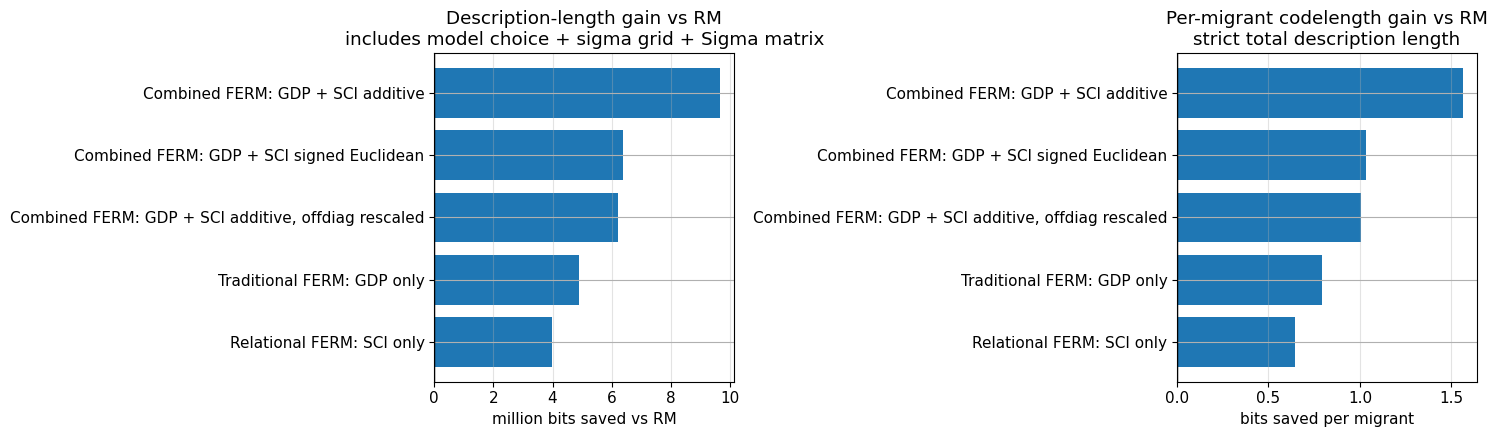

In [157]:
plot_df = mdl_summary[mdl_summary["model"] != "rm"].copy()
plot_df = plot_df.sort_values("bits_saved_total_bits_strict16_vs_RM")

fig, axes = plt.subplots(1, 2, figsize=(15, max(4.5, 0.55 * len(plot_df))))

axes[0].barh(plot_df["label"], plot_df["bits_saved_total_bits_strict16_vs_RM"] / 1e6)
axes[0].axvline(0, color="black", linewidth=1)
axes[0].set_title(
    "Description-length gain vs RM\n"
    "includes model choice + sigma grid + Sigma matrix"
)
axes[0].set_xlabel("million bits saved vs RM")

axes[1].barh(plot_df["label"], plot_df["bits_saved_per_migrant_strict16_vs_RM"])
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_title("Per-migrant codelength gain vs RM\nstrict total description length")
axes[1].set_xlabel("bits saved per migrant")

for ax in axes:
    ax.grid(axis="x", alpha=0.35)

plt.tight_layout()
savefig("11_description_length_mdl_vs_rm_strict_sigma")
plt.show()


In [ ]:
best_mdl = mdl_summary[mdl_summary["model"] != "rm"].iloc[0]
print("Description-length interpretation")
print(f"- Best compression relative to RM after strict costs: {best_mdl['label']}.")
print(f"- Bits saved vs RM after model choice + sigma grid + Sigma matrix: {best_mdl['bits_saved_total_bits_strict16_vs_RM'] / 1e6:.3f} million bits.")
print(f"- Bits saved per migrant after strict costs: {best_mdl['bits_saved_per_migrant_strict16_vs_RM']:.4f} bits/migrant.")
print(f"- Sigma-grid calibration cost charged: log2({len(SIGMA_GRID)}) = {sigma_choice_bits:.3f} bits for each FERM candidate.")
print(f"- Sigma-matrix cost charged: {MDL_SIGMA_BITS_PER_VALUE} bits per matrix entry, including the diagonal.")
print("- The minimal/external-feature columns remain in the table as a lower-bound reference.")

Description-length interpretation
- Best compression relative to RM after strict costs: Combined FERM: GDP + SCI additive.
- Bits saved vs RM after model choice + sigma grid + Sigma matrix: 9.663 million bits.
- Bits saved per migrant after strict costs: 1.5620 bits/migrant.
- Sigma-grid calibration cost charged: log2(5) = 2.322 bits for each FERM candidate.
- Sigma-matrix cost charged: 16 bits per matrix entry, including the diagonal.
- The minimal/external-feature columns remain in the table as a lower-bound reference.
- The total cost of the combined model additive is: 16.906 million bits.


In [163]:
combined_key = "combined_additive"

combined_mdl = mdl_summary.loc[mdl_summary["model"] == combined_key].iloc[0]

L_FERM_minimal = combined_mdl["minimal_model_bits"]
L_FERM_strict = (
    combined_mdl["minimal_model_bits"]
    + combined_mdl["strict_sigma_matrix_bits_16"]
)

print(f"- The minimal model cost L(FERM) is: {L_FERM_minimal:,.2f} bits.")
print(f"- The strict model cost L(FERM), including calibration and Sigma, is: {L_FERM_strict:,.2f} bits.")


- The minimal model cost L(FERM) is: 4.91 bits.
- The strict model cost L(FERM), including calibration and Sigma, is: 33,860.91 bits.
